In [1]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 14.5 MB/s eta 0:00:00


In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
from datetime import timedelta

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import seaborn as sns

from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import pmdarima as pm

from prophet import Prophet

from sklearn.metrics import mean_squared_error

# Display config
plt.rcParams.update({
    'figure.dpi': 130,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
})
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)

✅ All libraries loaded successfully.


In [3]:
# ── Global configuration ─────────────────────────────────────────────────────

STOCKS = {
    'RELIANCE':  'RELIANCE.NS',
    'HDFCBANK':  'HDFCBANK.NS',
    'INFOSYS':   'INFY.NS',
    'SUNPHARMA': 'SUNPHARMA.NS',
    'MARUTI':    'MARUTI.NS',
}

# Sector mapping for portfolio analysis
SECTORS = {
    'RELIANCE':  'Energy',
    'HDFCBANK':  'Banking',
    'INFOSYS':   'IT',
    'SUNPHARMA': 'Pharma',
    'MARUTI':    'Auto',
}

# Date ranges
START_DATE  = '2021-01-01'
END_DATE    = '2025-12-31'
TRAIN_END   = '2025-06-30'
TEST_START  = '2025-07-01'

# Portfolio
TOTAL_CAPITAL = 1_000_000   # ₹10,00,000

# Colour palette (one per stock)
STOCK_COLORS = {
    'RELIANCE':  '#1565C0',
    'HDFCBANK':  '#2E7D32',
    'INFOSYS':   '#E65100',
    'SUNPHARMA': '#6A1B9A',
    'MARUTI':    '#C62828',
}

print("Configuration set.")
print(f"Stocks       : {list(STOCKS.keys())}")
print(f"Training     : {START_DATE}  →  {TRAIN_END}")
print(f"Test         : {TEST_START}  →  {END_DATE}")
print(f"Total capital: ₹{TOTAL_CAPITAL:,}")

Configuration set.
Stocks       : ['RELIANCE', 'HDFCBANK', 'INFOSYS', 'SUNPHARMA', 'MARUTI']
Training     : 2021-01-01  →  2025-06-30
Test         : 2025-07-01  →  2025-12-31
Total capital: ₹1,000,000


In [4]:
# ── Fetch all stock data ────────────────────────────────────────────────────

def fetch_stock_data(tickers: dict, start: str, end: str) -> dict:
    """
    Download daily Close prices from Yahoo Finance via yfinance.

    Parameters
    ----------
    tickers : dict  {name: yahoo_ticker}
    start   : str   YYYY-MM-DD
    end     : str   YYYY-MM-DD

    Returns
    -------
    dict  {name: pd.Series of Close prices with DatetimeIndex}
    """
    data = {}
    for name, ticker in tickers.items():
        print(f"  Fetching {name:10s} ({ticker}) ...", end="  ")
        df = yf.download(ticker, start=start, end=end,
                         interval='1d', progress=False, auto_adjust=True)
        if df.empty:
            print("No data found!")
            continue

        # Keep Close price only
        series = df['Close'].squeeze().dropna()
        series.index = pd.to_datetime(series.index)

        # Enforce business-day frequency and forward-fill holiday gaps
        series = series.asfreq('B').ffill()

        data[name] = series
        print(f"{len(series):,} trading days  |  "
              f"₹{series.iloc[0]:.0f} → ₹{series.iloc[-1]:.0f}")
    return data


print("Downloading NSE stock data (Jan 2021 – Dec 2025)…\n")
price_data = fetch_stock_data(STOCKS, START_DATE, END_DATE)

# Combined DataFrame
prices_df = pd.DataFrame(price_data)
print(f"\n{'='*55}")
print(f"Combined DataFrame : {prices_df.shape[0]} rows × {prices_df.shape[1]} stocks")
print(f"Date range         : {prices_df.index[0].date()}  →  {prices_df.index[-1].date()}")
print(f"Missing values     : {prices_df.isna().sum().sum()}")
prices_df.tail(3)


  Fetching RELIANCE   (RELIANCE.NS) ...  1,303 trading days  |  ₹901 → ₹1540
  Fetching HDFCBANK   (HDFCBANK.NS) ...  1,303 trading days  |  ₹675 → ₹991
  Fetching INFOSYS    (INFY.NS) ...  1,303 trading days  |  ₹1110 → ₹1622
  Fetching SUNPHARMA  (SUNPHARMA.NS) ...  1,303 trading days  |  ₹563 → ₹1709
  Fetching MARUTI     (MARUTI.NS) ...  1,303 trading days  |  ₹7372 → ₹16647

Combined DataFrame : 1303 rows × 5 stocks
Date range         : 2021-01-01  →  2025-12-30
Missing values     : 0


,RELIANCE,HDFCBANK,INFOSYS,SUNPHARMA,MARUTI
Date,,,,,
2025-12-26,1559.2000,992.1000,1656.1000,1708.4026,16596.0000
2025-12-29,1545.6000,991.7000,1644.7000,1706.1173,16542.0000
2025-12-30,1539.8000,990.9000,1621.6000,1709.0980,16647.0000


In [5]:
# ── Train / test split ──────────────────────────────────────────────────────

def get_train_test(price_data: dict, train_end: str, test_start: str):
    """
    Chronological split — NEVER shuffle time series data.
    Returns train_dict and test_dict, each {stock_name: pd.Series}.
    """
    train_dict, test_dict = {}, {}
    for name, series in price_data.items():
        train_dict[name] = series[:train_end]
        test_dict[name]  = series[test_start:]
    return train_dict, test_dict

train_data, test_data = get_train_test(price_data, TRAIN_END, TEST_START)

print("Train / Test split summary:")
print(f"{'Stock':<12} {'Train days':>12} {'Test days':>10} {'Train end':>12} {'Test start':>12}")
print("─" * 60)
for name in price_data:
    print(f"{name:<12} {len(train_data[name]):>12,} {len(test_data[name]):>10,}"
          f"  {train_data[name].index[-1].date()}  {test_data[name].index[0].date()}")

Train / Test split summary:
Stock          Train days  Test days    Train end   Test start
────────────────────────────────────────────────────────────
RELIANCE            1,172        131  2025-06-30  2025-07-01
HDFCBANK            1,172        131  2025-06-30  2025-07-01
INFOSYS             1,172        131  2025-06-30  2025-07-01
SUNPHARMA           1,172        131  2025-06-30  2025-07-01
MARUTI              1,172        131  2025-06-30  2025-07-01


---
## Exploratory Data Analysis


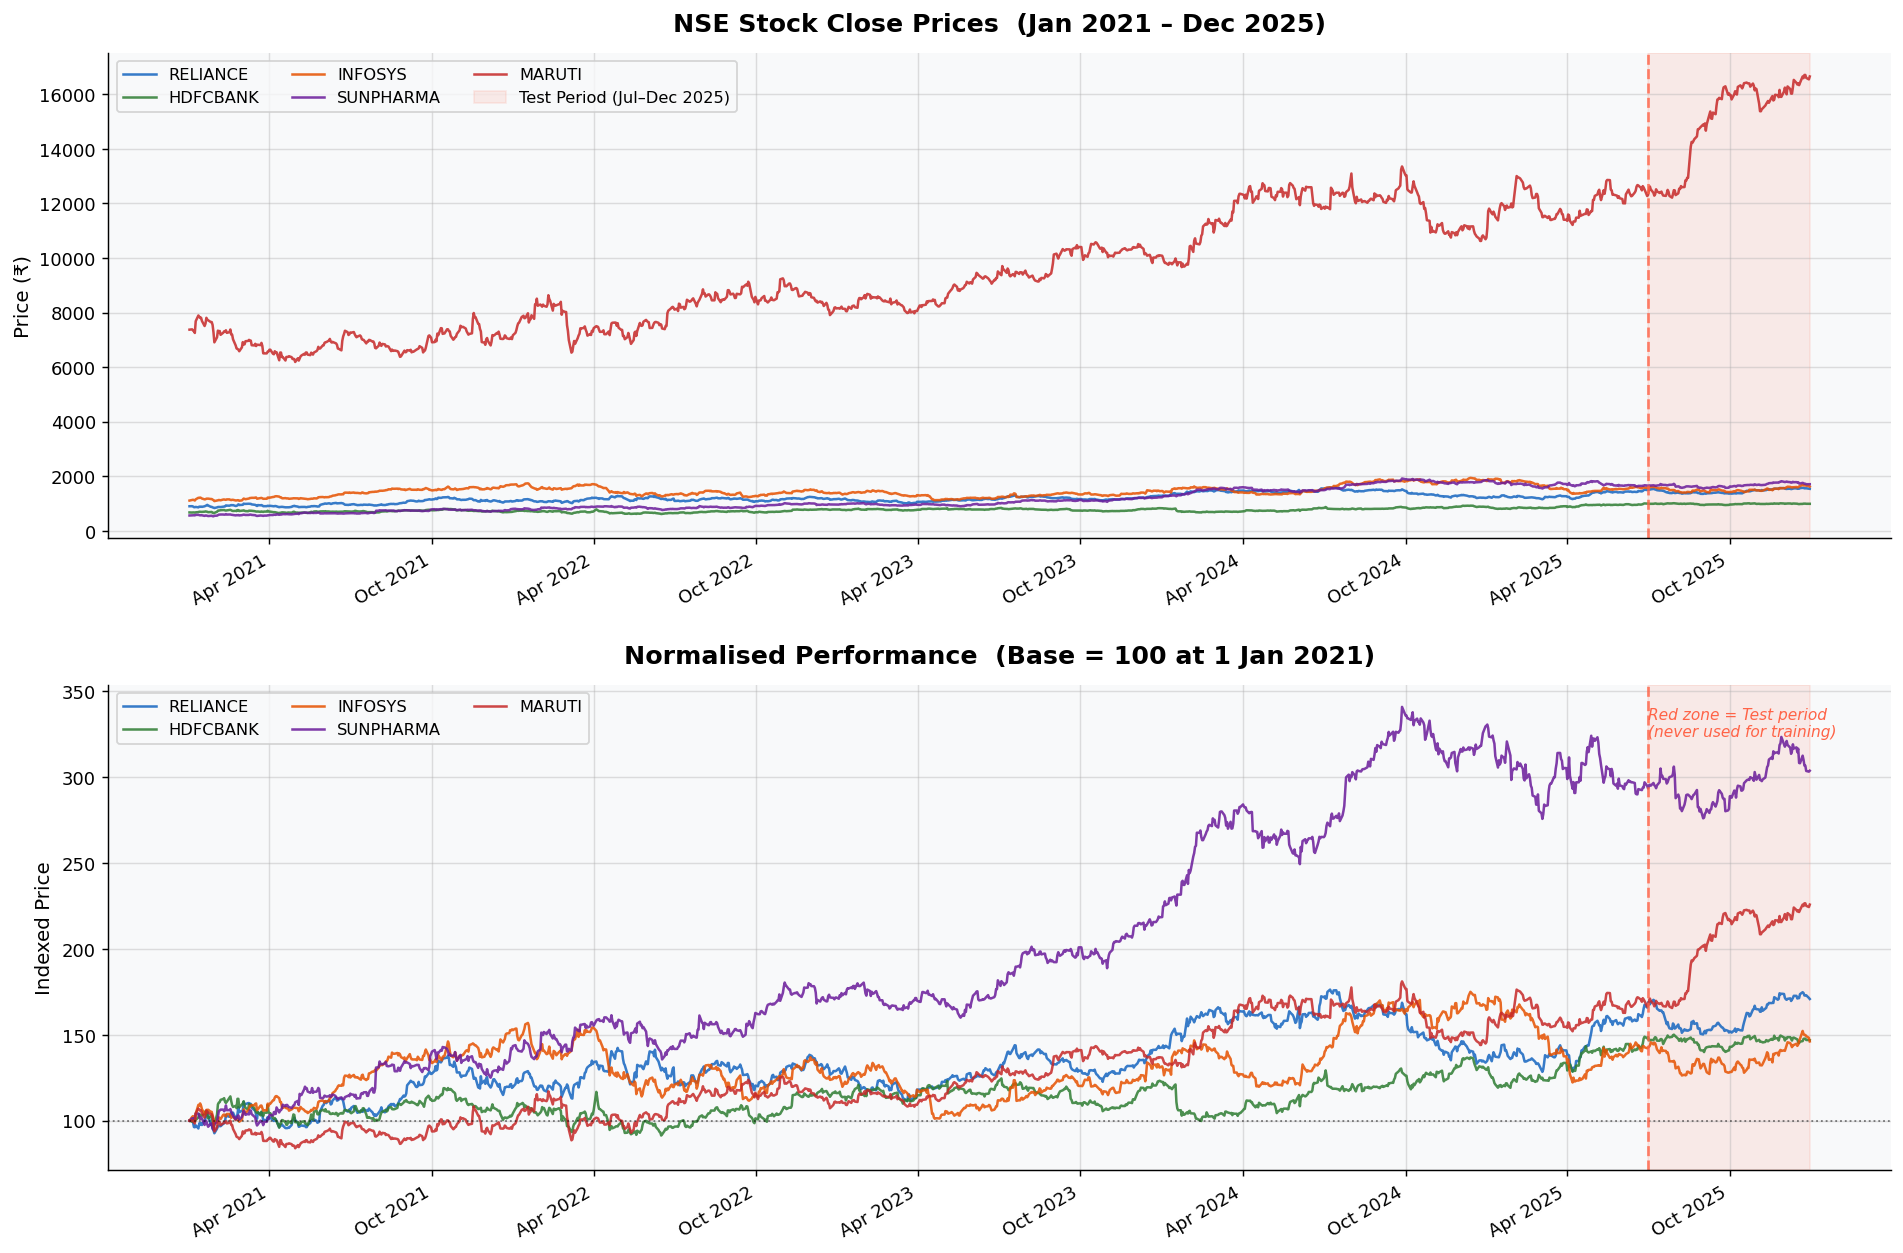

In [7]:
# ── Plot 1: Raw prices + normalised prices ───────────────────────────────────

fig, axes = plt.subplots(2, 1, figsize=(15, 10))
test_start_ts = pd.Timestamp(TEST_START)

# ── Raw prices ──
ax = axes[0]
for name, series in price_data.items():
    ax.plot(series.index, series, label=name,
            color=STOCK_COLORS[name], linewidth=1.4, alpha=0.85)
ax.axvspan(test_start_ts, prices_df.index[-1], alpha=0.10,
           color='tomato', label='Test Period (Jul–Dec 2025)')
ax.axvline(test_start_ts, color='tomato', linestyle='--',
           linewidth=1.5, alpha=0.8)
ax.set_title('NSE Stock Close Prices  (Jan 2021 – Dec 2025)',
             fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Price (₹)', fontsize=11)
ax.legend(loc='upper left', fontsize=9, ncol=3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

# ── Normalised prices ──
ax = axes[1]
normalised = prices_df.div(prices_df.iloc[0]) * 100
for col in normalised.columns:
    ax.plot(normalised.index, normalised[col], label=col,
            color=STOCK_COLORS[col], linewidth=1.4, alpha=0.85)
ax.axhline(100, color='black', linestyle=':', linewidth=1, alpha=0.5)
ax.axvspan(test_start_ts, prices_df.index[-1], alpha=0.10, color='tomato')
ax.axvline(test_start_ts, color='tomato', linestyle='--', linewidth=1.5, alpha=0.8)
ax.set_title('Normalised Performance  (Base = 100 at 1 Jan 2021)',
             fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Indexed Price', fontsize=11)
ax.legend(loc='upper left', fontsize=9, ncol=3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax.annotate('Red zone = Test period\n(never used for training)',
            xy=(test_start_ts, normalised.values.max() * 0.95),
            fontsize=8.5, color='tomato', style='italic')

plt.tight_layout(pad=2)
plt.savefig('01_price_history.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# ── Descriptive statistics ───────────────────────────────────────────────────

print("\n Descriptive Statistics (Full Period Closing Prices)\n")
stats = prices_df.describe().T
stats['range'] = stats['max'] - stats['min']
stats['cv_%'] = (stats['std'] / stats['mean'] * 100).round(2)   # Coefficient of variation
display(stats[['count','mean','std','min','max','range','cv_%']].round(2))

print("\n 'cv_%' is the coefficient of variation (std/mean × 100).")
print("   Higher cv_% → more volatile relative to its own price level.")


 Descriptive Statistics (Full Period Closing Prices)



,count,mean,std,min,max,range,cv_%
RELIANCE,1303.0000,1219.7900,179.3100,835.2000,1589.1400,753.9400,14.7000
HDFCBANK,1303.0000,785.6500,98.2300,616.5200,1012.9000,396.3800,12.5000
INFOSYS,1303.0000,1461.6500,189.1000,1090.7600,1942.2200,851.4600,12.9400
SUNPHARMA,1303.0000,1177.7100,417.4700,532.4900,1918.2100,1385.7200,35.4500
MARUTI,1303.0000,9894.8100,2604.2000,6187.3400,16703.0000,10515.6600,26.3200



 'cv_%' is the coefficient of variation (std/mean × 100).
   Higher cv_% → more volatile relative to its own price level.


# Stationarity Analysis — ADF Test

In [11]:
# ── ADF test function ────────────────────────────────────────────────────────

def run_adf_test(series: pd.Series, label: str, verbose: bool = True) -> dict:

    result   = adfuller(series.dropna(), autolag='AIC')
    is_stat  = result[1] < 0.05

    out = {
        'label':        label,
        'adf_stat':     round(result[0], 4),
        'p_value':      round(result[1], 6),
        'lags_used':    result[2],
        'crit_1pct':    round(result[4]['1%'], 4),
        'crit_5pct':    round(result[4]['5%'], 4),
        'is_stationary': is_stat,
    }
    if verbose:
        status = "STATIONARY" if is_stat else "NON-STATIONARY"
        print(f"  {label:<30}  ADF={out['adf_stat']:>9.4f}  "
              f"p={out['p_value']:.6f}  {status}")
    return out


# ── Test raw prices ──────────────────────────────────────────────────────────
print("ADF TEST — RAW PRICE SERIES")
print("─" * 75)
adf_raw = {name: run_adf_test(price_data[name], f"{name} raw") for name in price_data}

print()

# ── Test first-differenced series ────────────────────────────────────────────
print("ADF TEST — FIRST-DIFFERENCED SERIES  (Δy_t = y_t − y_{t−1})")
print("─" * 75)
diff_data = {name: price_data[name].diff().dropna() for name in price_data}
adf_diff  = {name: run_adf_test(diff_data[name], f"{name} Δ1") for name in price_data}

# ── Summary table ────────────────────────────────────────────────────────────
rows = []
for name in price_data:
    rows.append({
        'Stock':              name,
        'Raw p-value':        adf_raw[name]['p_value'],
        'Raw Stationary':     adf_raw[name]['is_stationary'],
        'Diff p-value':       adf_diff[name]['p_value'],
        'Diff Stationary':    adf_diff[name]['is_stationary'],
        'd for ARIMA':        0 if adf_raw[name]['is_stationary'] else 1,
    })

summary_adf = pd.DataFrame(rows)
print()
print("SUMMARY:")
display(summary_adf)
print("\n All raw price series are non-stationary (expected for stock prices).")
print("   After 1st differencing, all series achieve stationarity → d = 1 for all stocks.")

ADF TEST — RAW PRICE SERIES
───────────────────────────────────────────────────────────────────────────
  RELIANCE raw                    ADF=  -1.6824  p=0.440206  NON-STATIONARY
  HDFCBANK raw                    ADF=  -1.3968  p=0.583806  NON-STATIONARY
  INFOSYS raw                     ADF=  -2.4091  p=0.139185  NON-STATIONARY
  SUNPHARMA raw                   ADF=  -0.8198  p=0.813241  NON-STATIONARY
  MARUTI raw                      ADF=   0.3984  p=0.981435  NON-STATIONARY

ADF TEST — FIRST-DIFFERENCED SERIES  (Δy_t = y_t − y_{t−1})
───────────────────────────────────────────────────────────────────────────
  RELIANCE Δ1                     ADF= -36.2740  p=0.000000  STATIONARY
  HDFCBANK Δ1                     ADF= -17.6153  p=0.000000  STATIONARY
  INFOSYS Δ1                      ADF= -35.6282  p=0.000000  STATIONARY
  SUNPHARMA Δ1                    ADF= -38.1909  p=0.000000  STATIONARY
  MARUTI Δ1                       ADF= -33.7016  p=0.000000  STATIONARY

SUMMARY:


,Stock,Raw p-value,Raw Stationary,Diff p-value,Diff Stationary,d for ARIMA
0,RELIANCE,0.4402,False,0.0000,True,1
1,HDFCBANK,0.5838,False,0.0000,True,1
2,INFOSYS,0.1392,False,0.0000,True,1
3,SUNPHARMA,0.8132,False,0.0000,True,1
4,MARUTI,0.9814,False,0.0000,True,1



 All raw price series are non-stationary (expected for stock prices).
   After 1st differencing, all series achieve stationarity → d = 1 for all stocks.


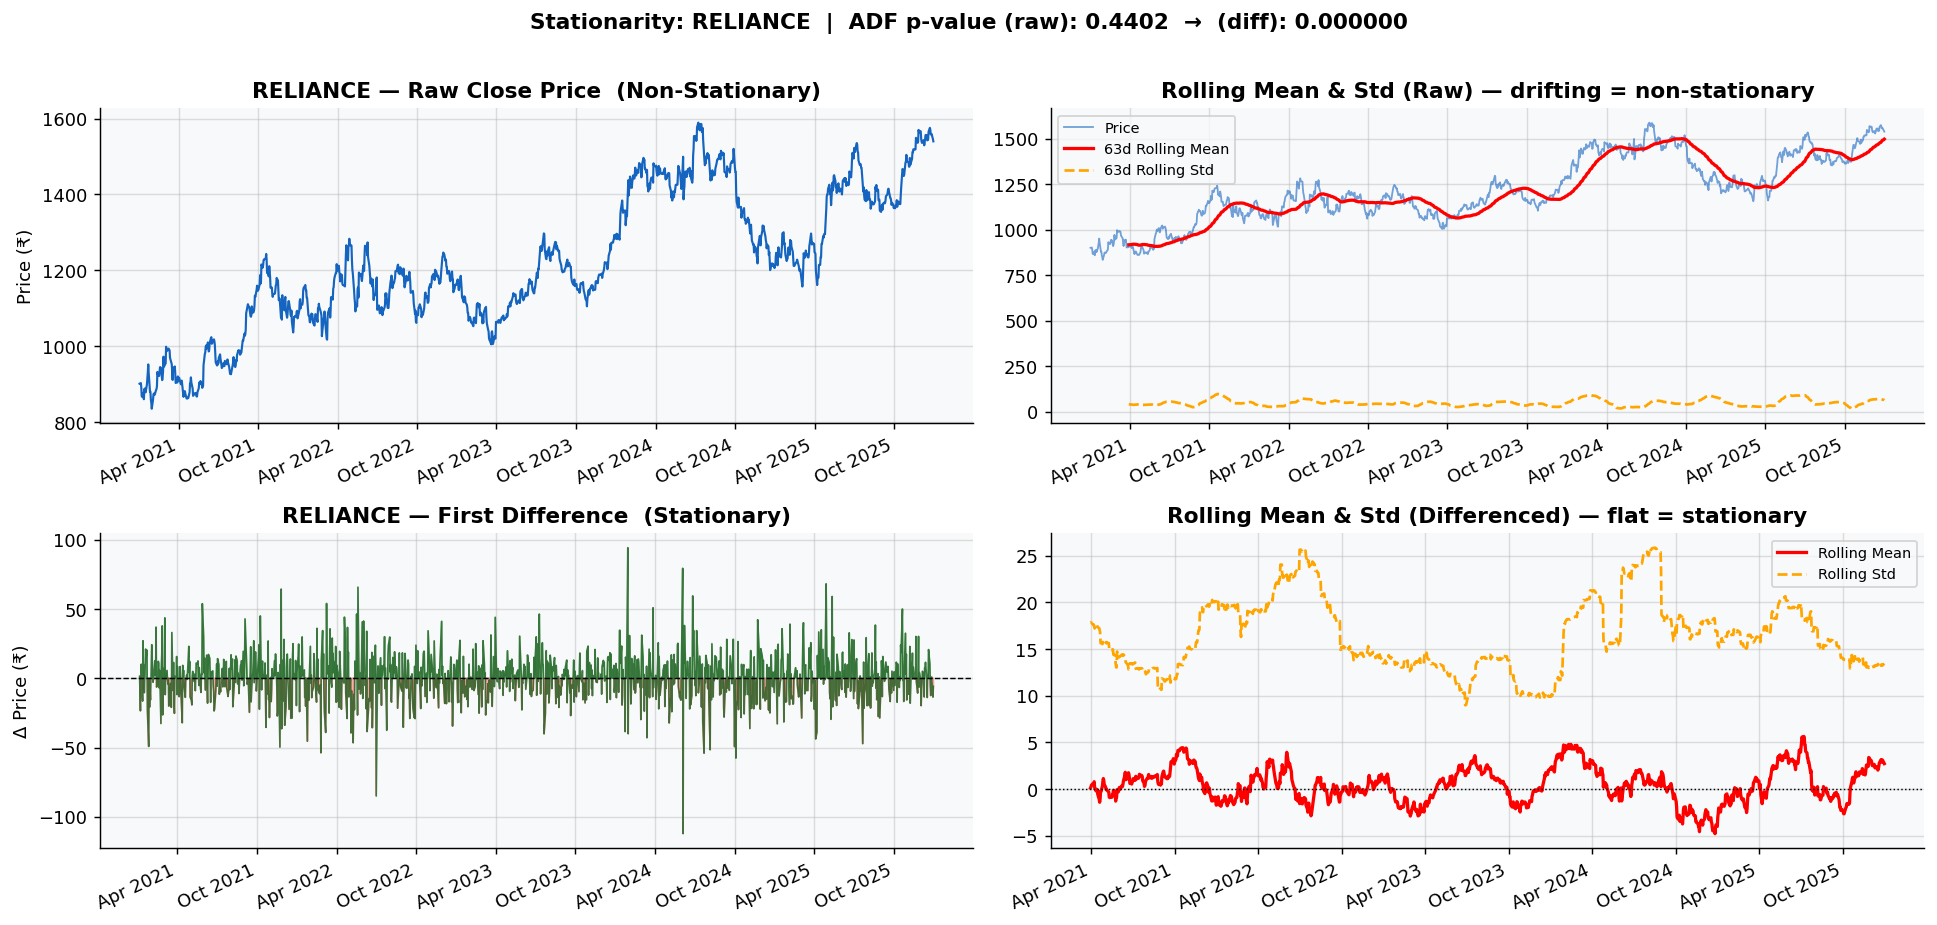

In [12]:
# ── Visualise: raw vs differenced for one stock ──────────────────────────────

stock_demo = 'RELIANCE'
raw_series  = price_data[stock_demo]
diff_series = diff_data[stock_demo]

fig, axes = plt.subplots(2, 2, figsize=(15, 7))

# Raw price
ax = axes[0, 0]
ax.plot(raw_series, color=STOCK_COLORS[stock_demo], linewidth=1.2)
ax.set_title(f'{stock_demo} — Raw Close Price  (Non-Stationary)', fontweight='bold')
ax.set_ylabel('Price (₹)')

# Rolling mean / std of raw
window = 63   # ~3 months
ax = axes[0, 1]
ax.plot(raw_series, color=STOCK_COLORS[stock_demo], linewidth=1, alpha=0.6, label='Price')
ax.plot(raw_series.rolling(window).mean(), color='red',   linewidth=1.8, label=f'{window}d Rolling Mean')
ax.plot(raw_series.rolling(window).std(),  color='orange',linewidth=1.5, linestyle='--', label=f'{window}d Rolling Std')
ax.set_title('Rolling Mean & Std (Raw) — drifting = non-stationary', fontweight='bold')
ax.legend(fontsize=8)

# Differenced series
ax = axes[1, 0]
ax.plot(diff_series, color='#1B5E20', linewidth=0.9, alpha=0.8)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.fill_between(diff_series.index, diff_series, 0,
                where=diff_series > 0, color='#4CAF50', alpha=0.4)
ax.fill_between(diff_series.index, diff_series, 0,
                where=diff_series < 0, color='#F44336', alpha=0.4)
ax.set_title(f'{stock_demo} — First Difference  (Stationary)', fontweight='bold')
ax.set_ylabel('Δ Price (₹)')

# Rolling mean / std of differenced
ax = axes[1, 1]
ax.plot(diff_series.rolling(window).mean(), color='red',   linewidth=1.8, label='Rolling Mean')
ax.plot(diff_series.rolling(window).std(),  color='orange',linewidth=1.5, linestyle='--', label='Rolling Std')
ax.axhline(0, color='black', linewidth=0.8, linestyle=':')
ax.set_title('Rolling Mean & Std (Differenced) — flat = stationary', fontweight='bold')
ax.legend(fontsize=8)

for ax in axes.flat:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=25, ha='right')

plt.suptitle(f'Stationarity: {stock_demo}  |  ADF p-value (raw): '
             f'{adf_raw[stock_demo]["p_value"]:.4f}  →  (diff): '
             f'{adf_diff[stock_demo]["p_value"]:.6f}',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('02_stationarity.png', dpi=150, bbox_inches='tight')
plt.show()

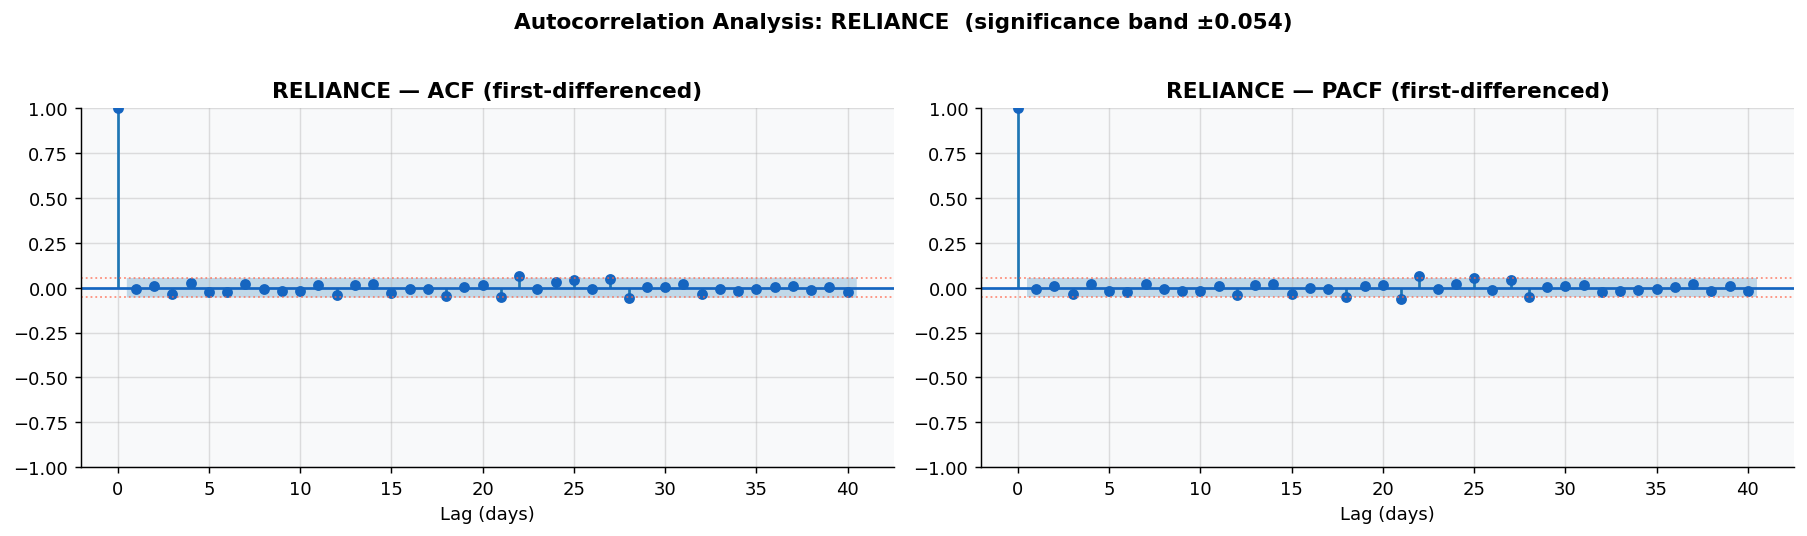

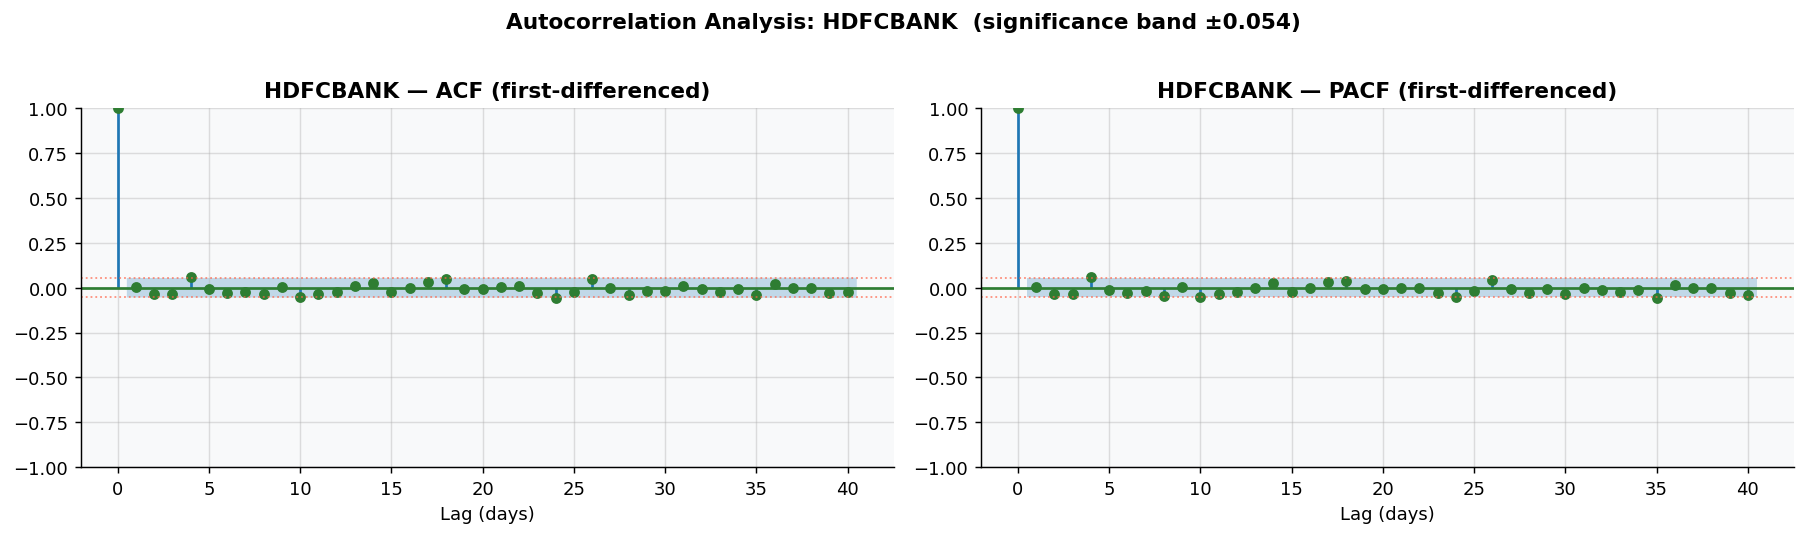

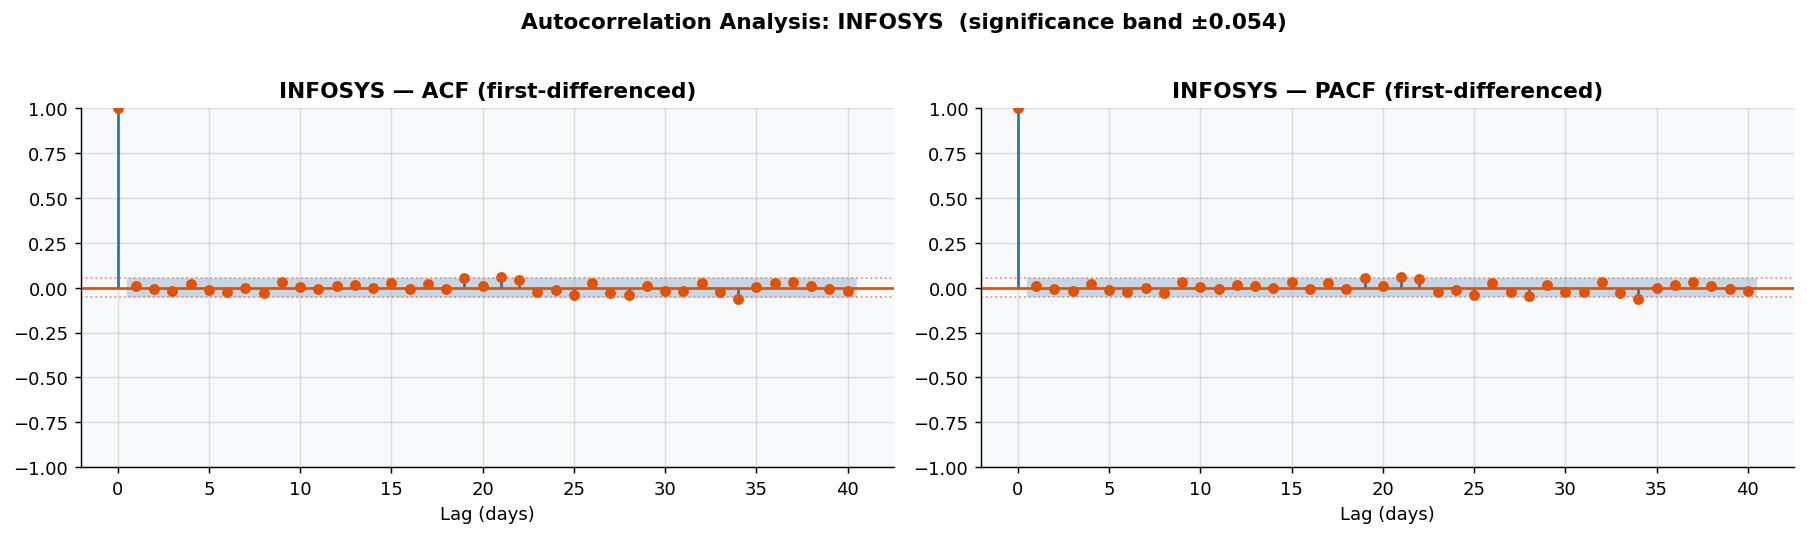

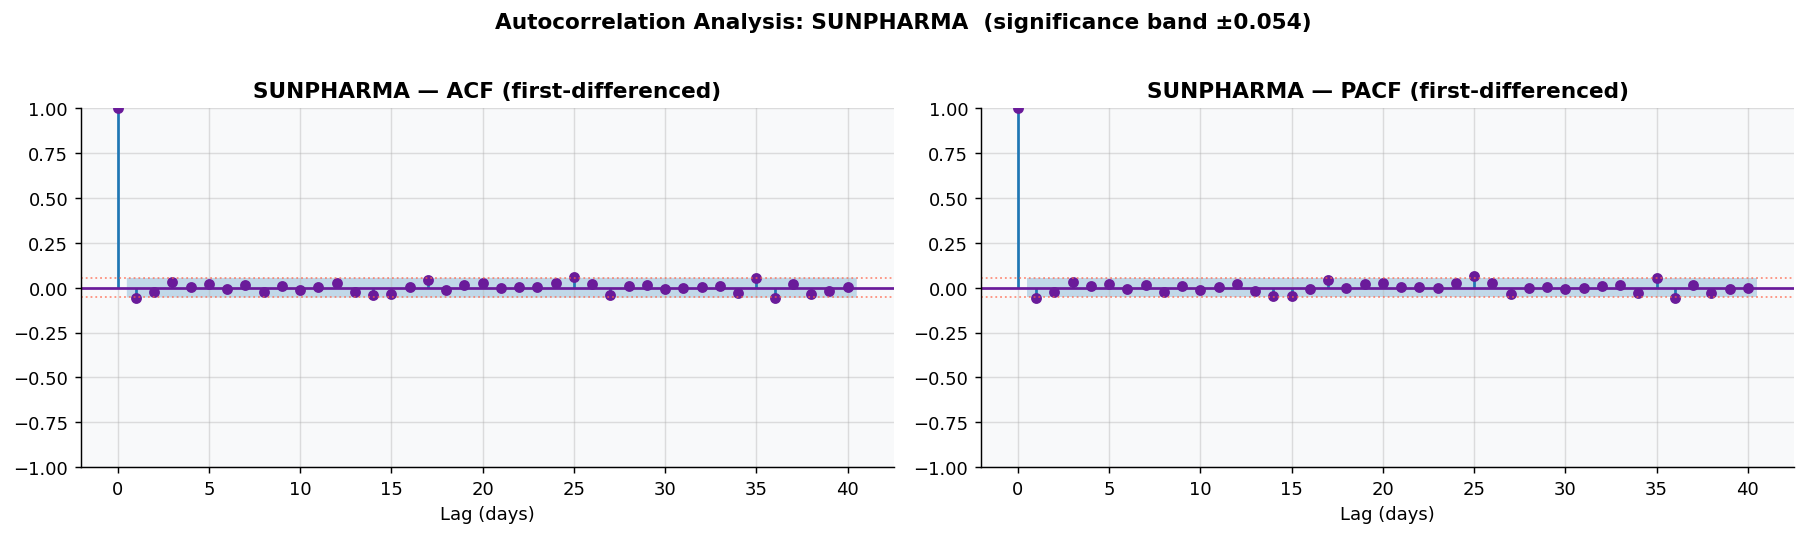

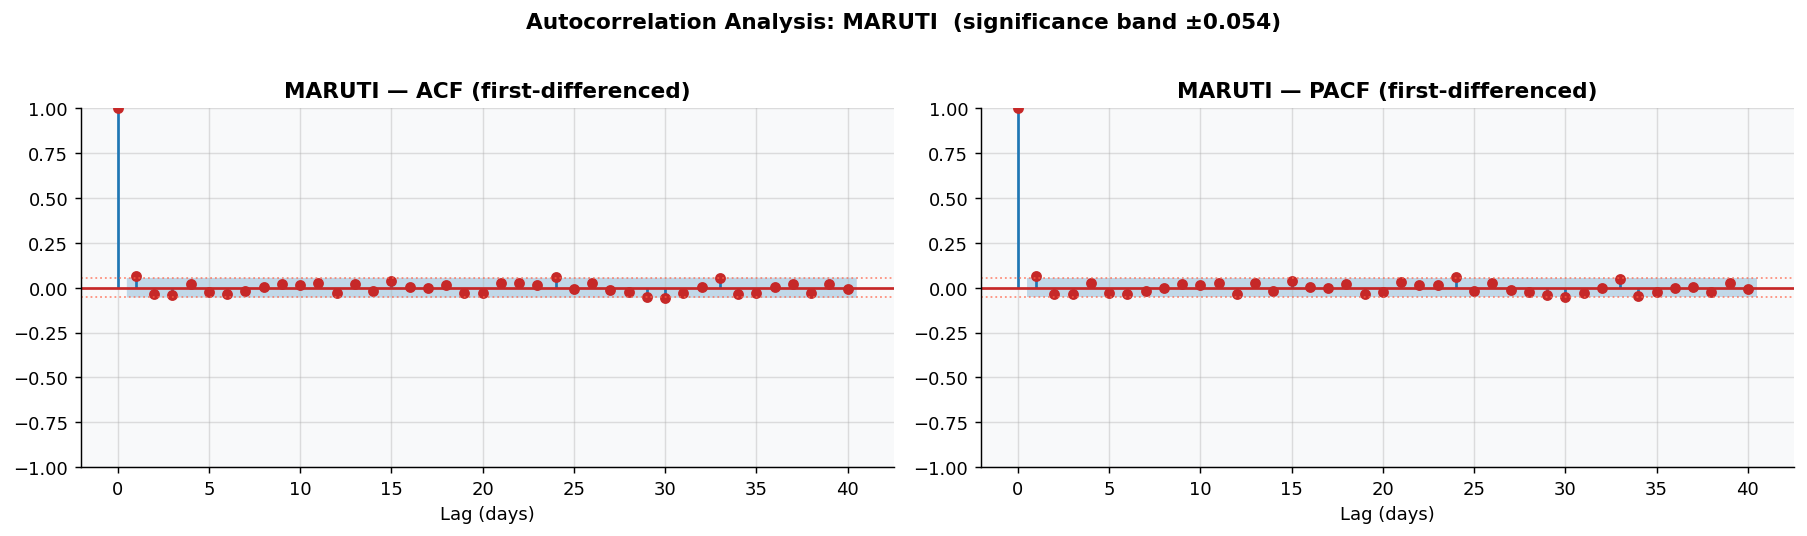

   • ACF decays quickly → consistent with MA structure → use for q selection
   • PACF cuts off sharply at lag k → AR(k) structure → use for p selection
   • Both decay slowly → ARIMA needed (not pure AR or MA)
   • We rely on auto_arima to handle selection formally via AIC minimisation.


In [14]:
# ── ACF / PACF plots for all stocks ─────────────────────────────────────────

def plot_acf_pacf(series: pd.Series, stock_name: str, lags: int = 40):
    """Plot ACF and PACF of the first-differenced series."""
    diff_s = series.diff().dropna()

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    plot_acf(diff_s,  lags=lags, ax=axes[0], alpha=0.05,
             color=STOCK_COLORS[stock_name], title='')
    plot_pacf(diff_s, lags=lags, ax=axes[1], alpha=0.05,
              color=STOCK_COLORS[stock_name], title='', method='ywm')

    axes[0].set_title(f'{stock_name} — ACF (first-differenced)', fontweight='bold')
    axes[1].set_title(f'{stock_name} — PACF (first-differenced)', fontweight='bold')
    axes[0].set_xlabel('Lag (days)')
    axes[1].set_xlabel('Lag (days)')

    # Shade the significance band
    n  = len(diff_s)
    ci = 1.96 / np.sqrt(n)
    for ax in axes:
        ax.axhline( ci, color='tomato', linestyle=':', linewidth=1, alpha=0.7)
        ax.axhline(-ci, color='tomato', linestyle=':', linewidth=1, alpha=0.7)

    plt.suptitle(f'Autocorrelation Analysis: {stock_name}  '
                 f'(significance band ±{ci:.3f})',
                 fontsize=12, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(f'03_acf_pacf_{stock_name.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()

for stock in price_data:
    plot_acf_pacf(price_data[stock], stock)

print("   • ACF decays quickly → consistent with MA structure → use for q selection")
print("   • PACF cuts off sharply at lag k → AR(k) structure → use for p selection")
print("   • Both decay slowly → ARIMA needed (not pure AR or MA)")
print("   • We rely on auto_arima to handle selection formally via AIC minimisation.")

---
## Seasonal Decomposition - STL

Values close to 1 indicate a dominant trend; close to 0 means the series is mostly noise.



Decomposing: RELIANCE


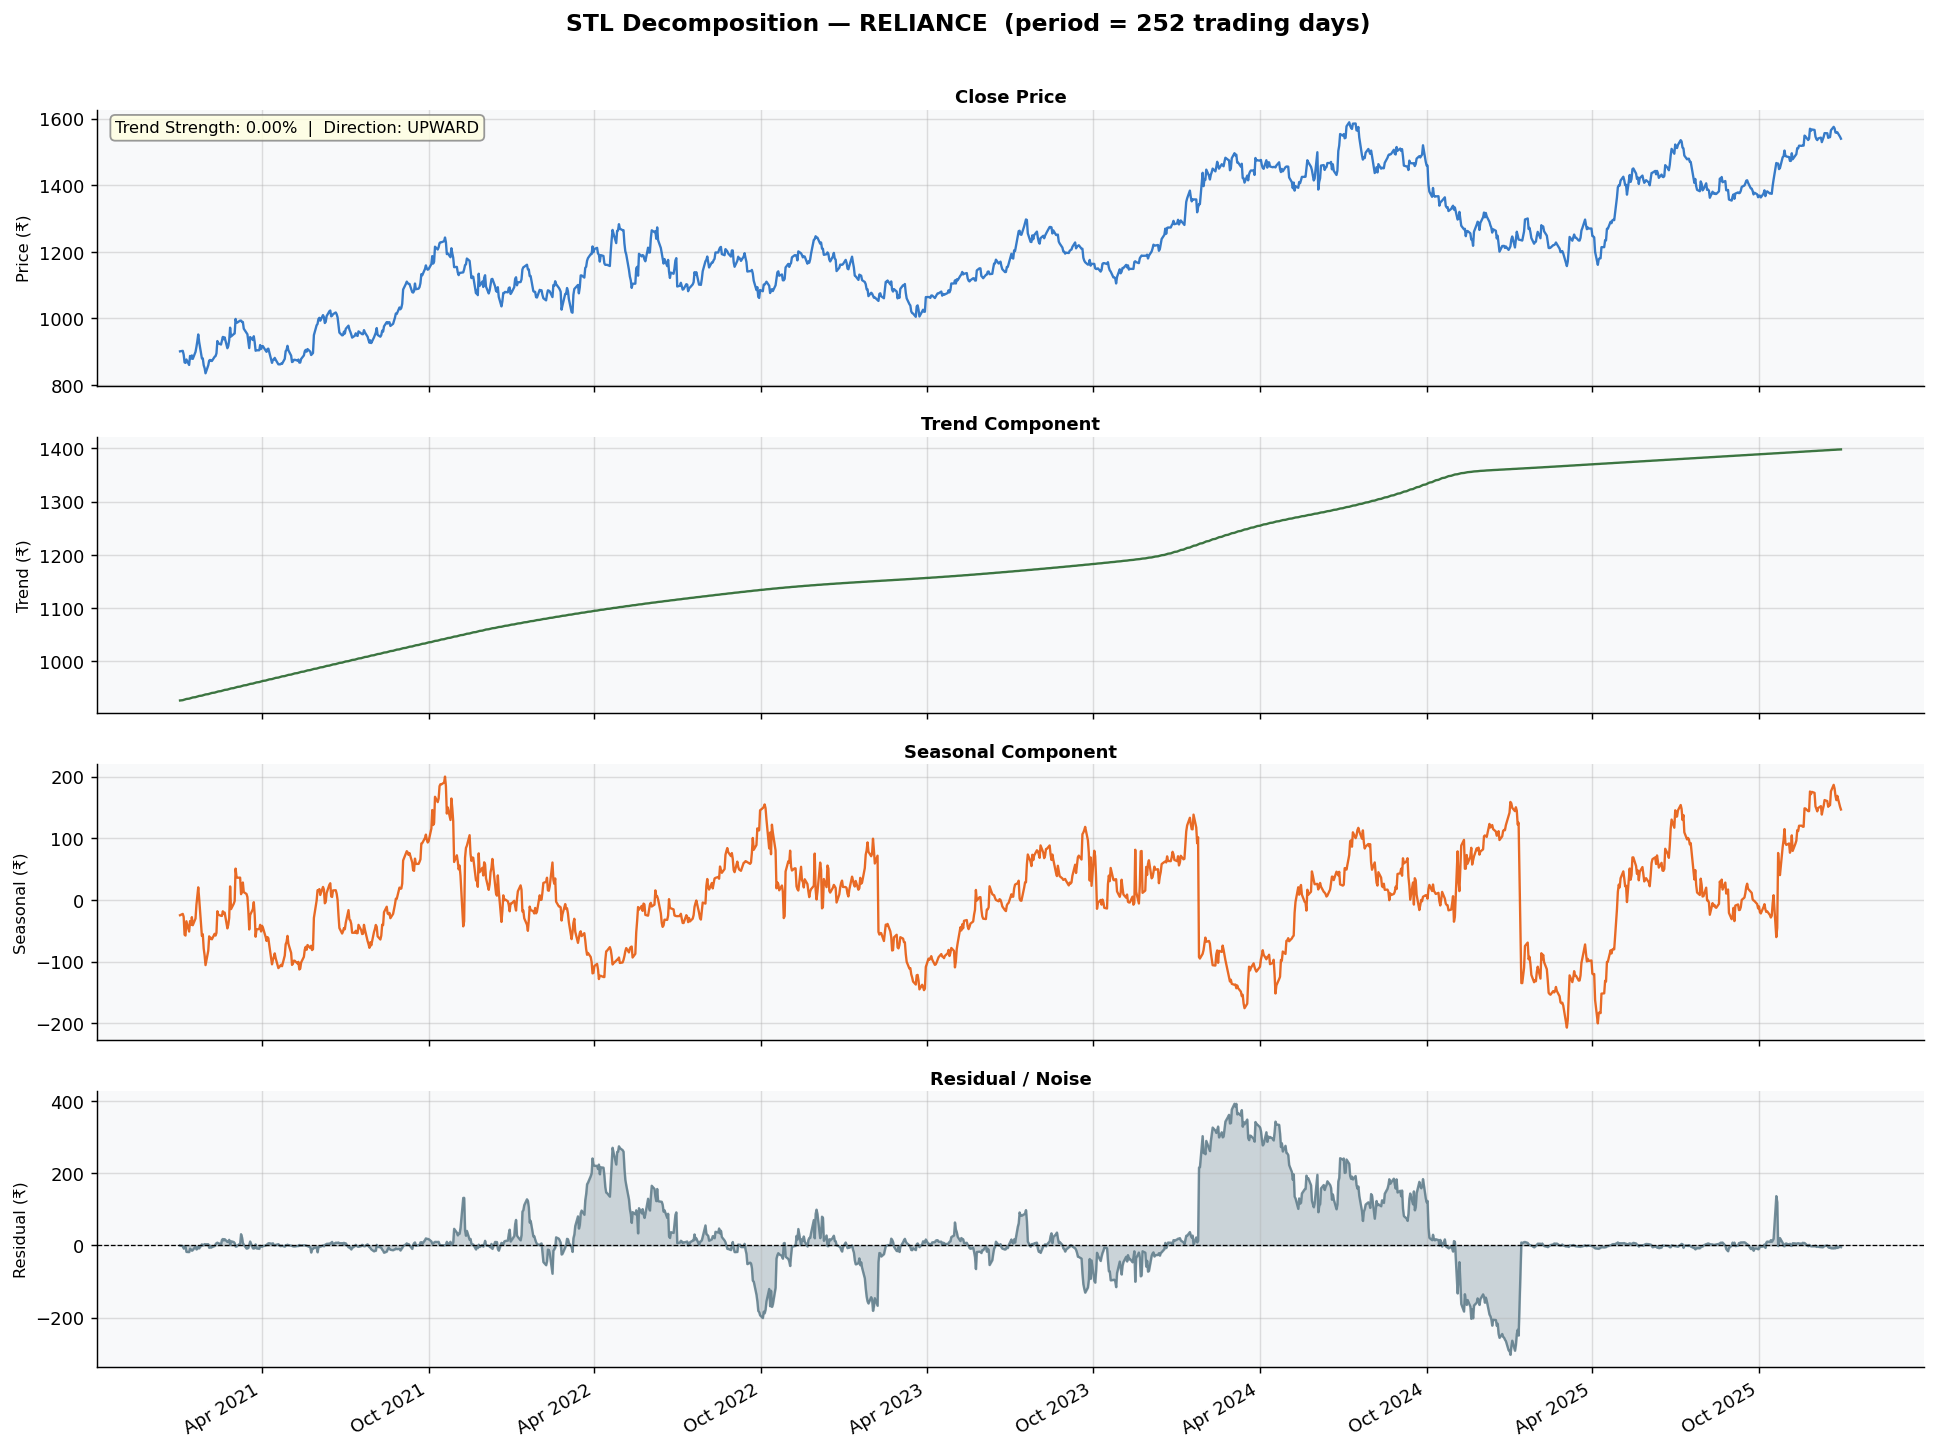


Decomposing: HDFCBANK


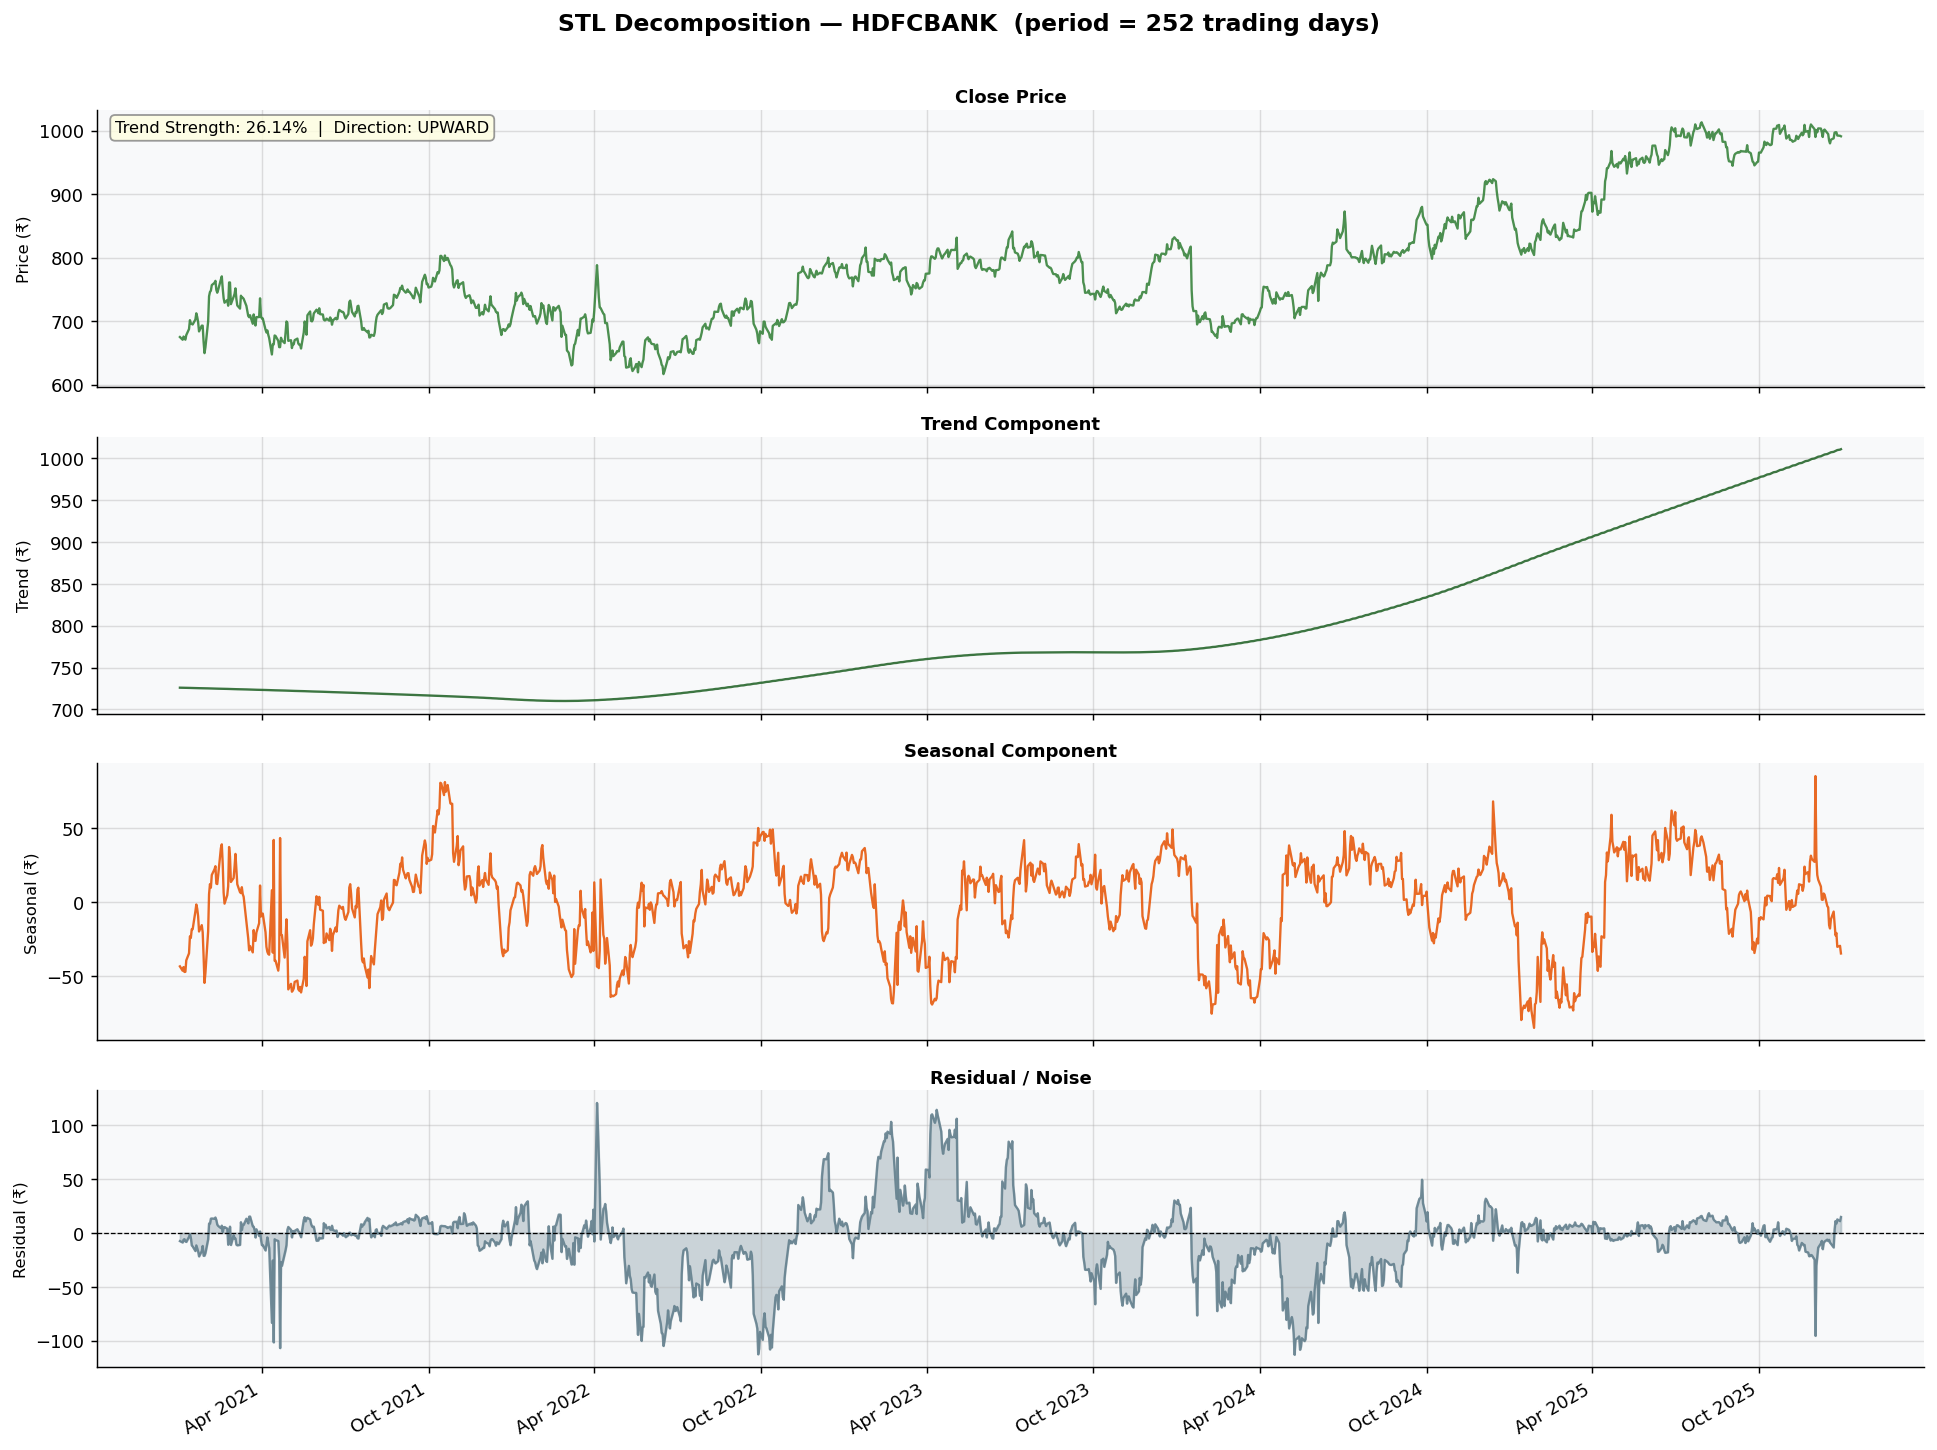


Decomposing: INFOSYS


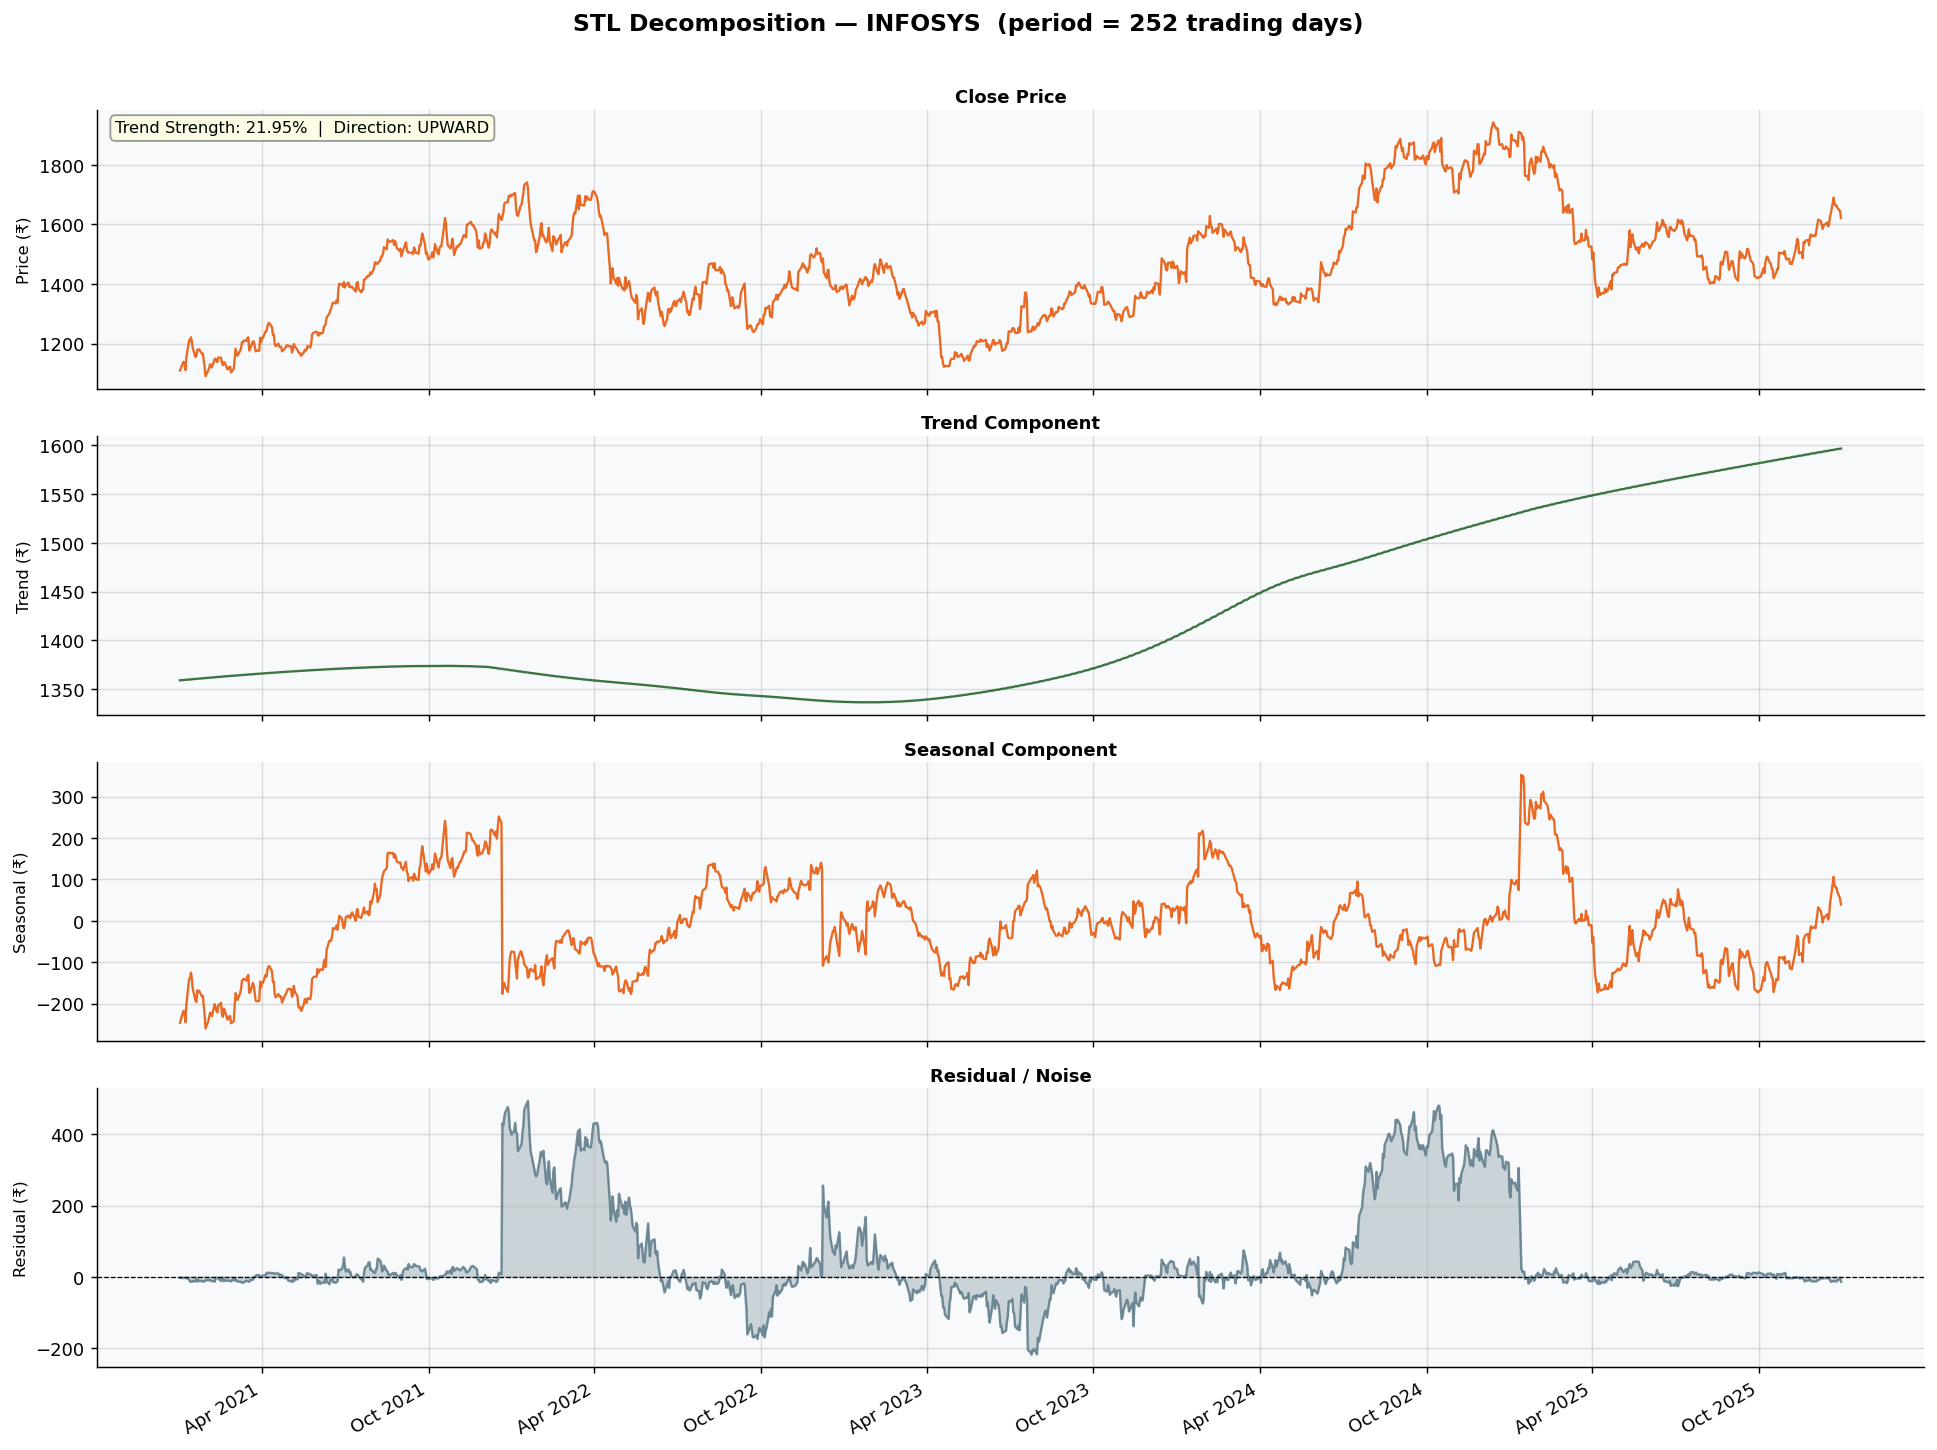


Decomposing: SUNPHARMA


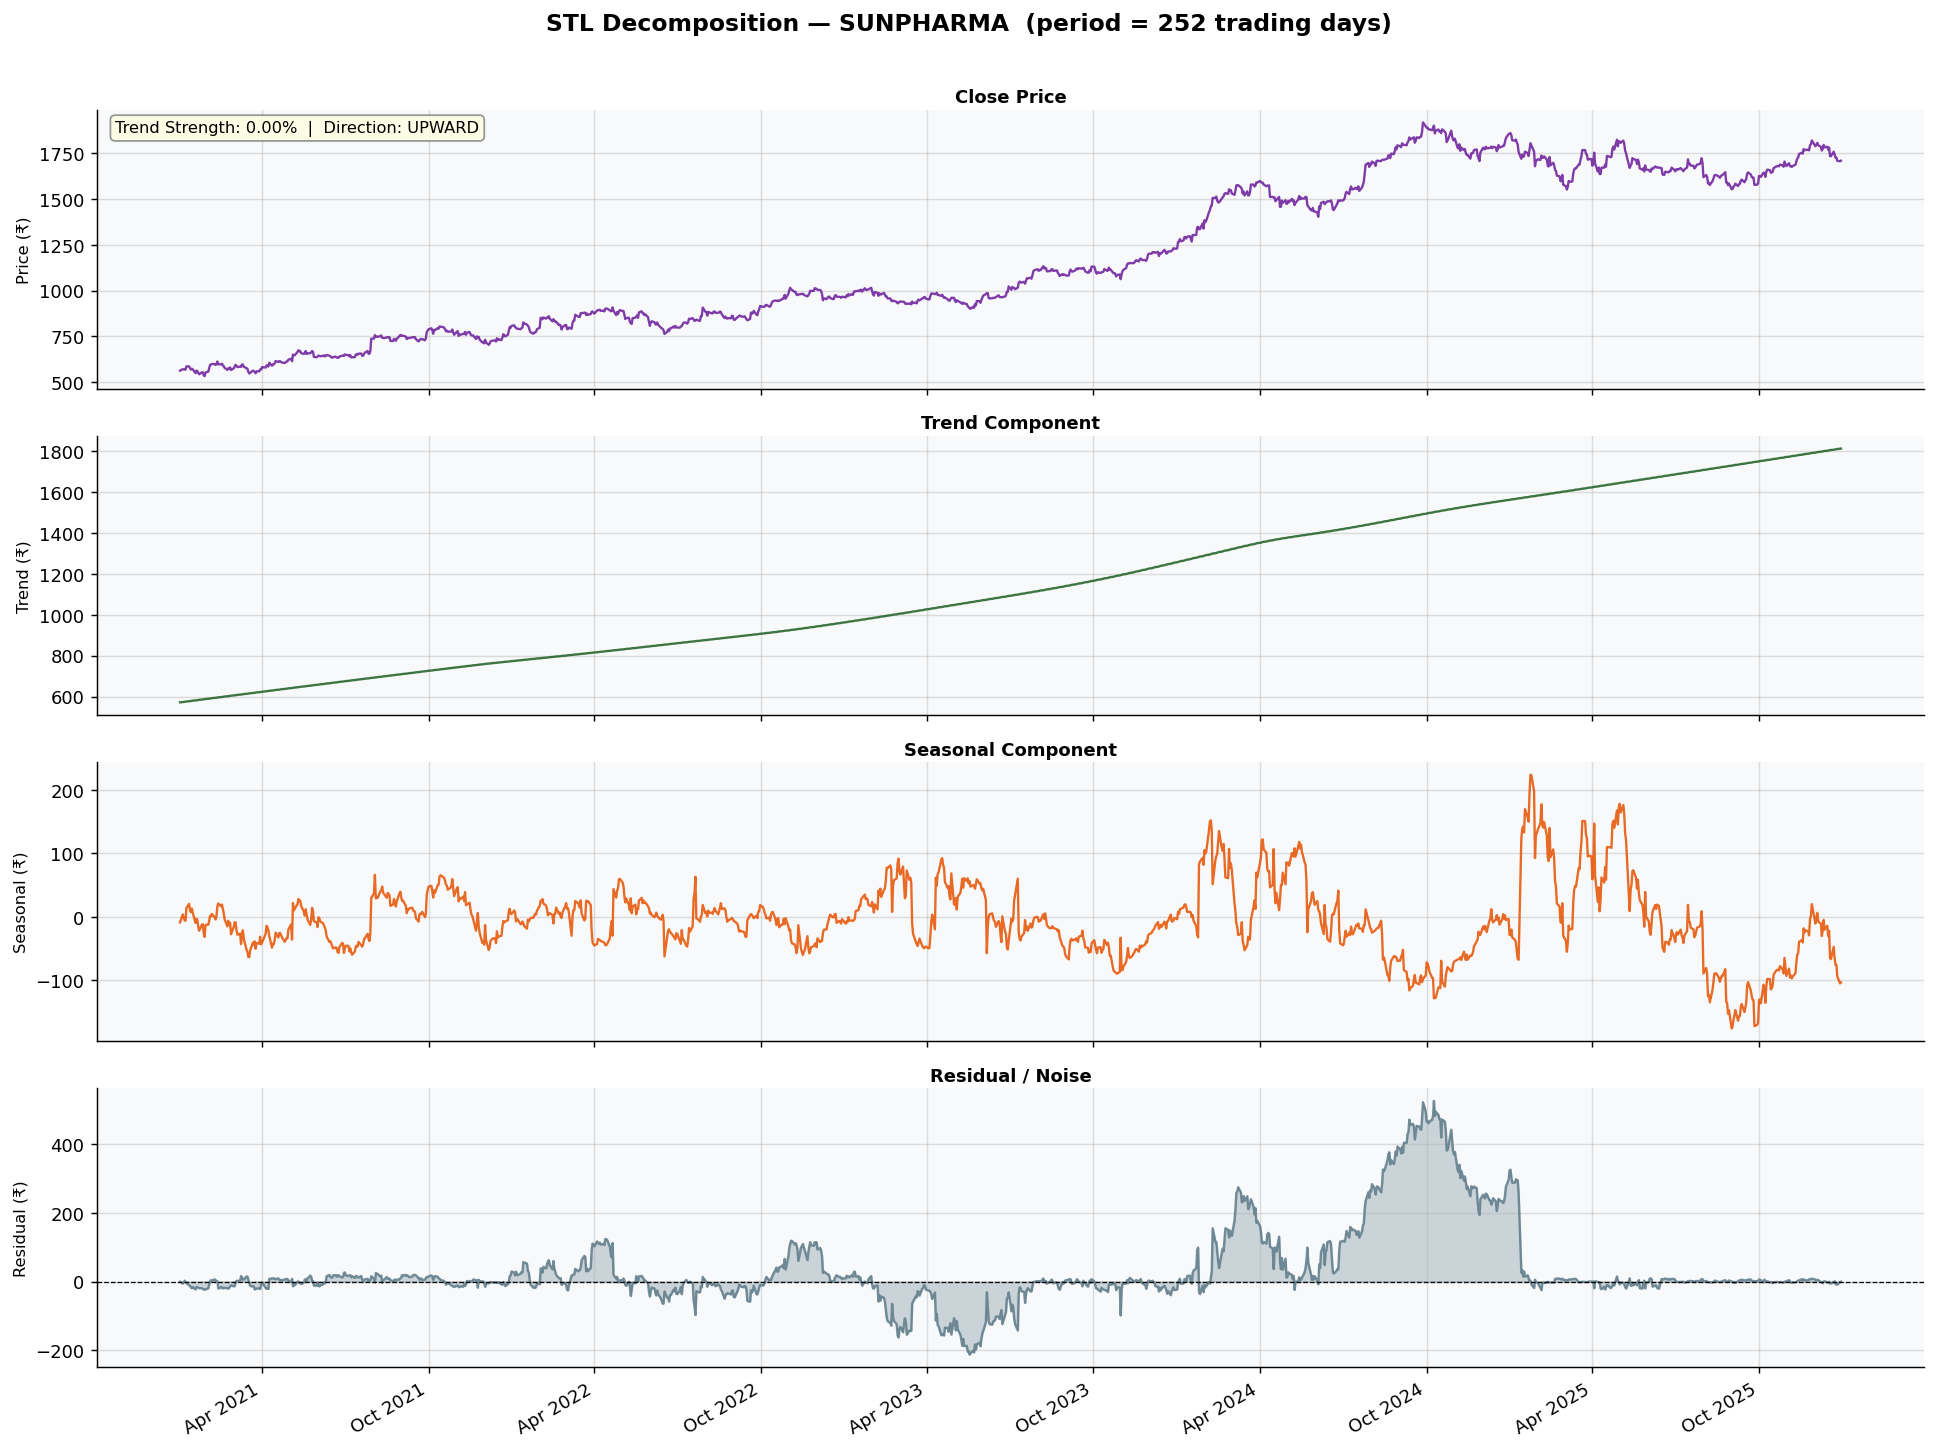


Decomposing: MARUTI


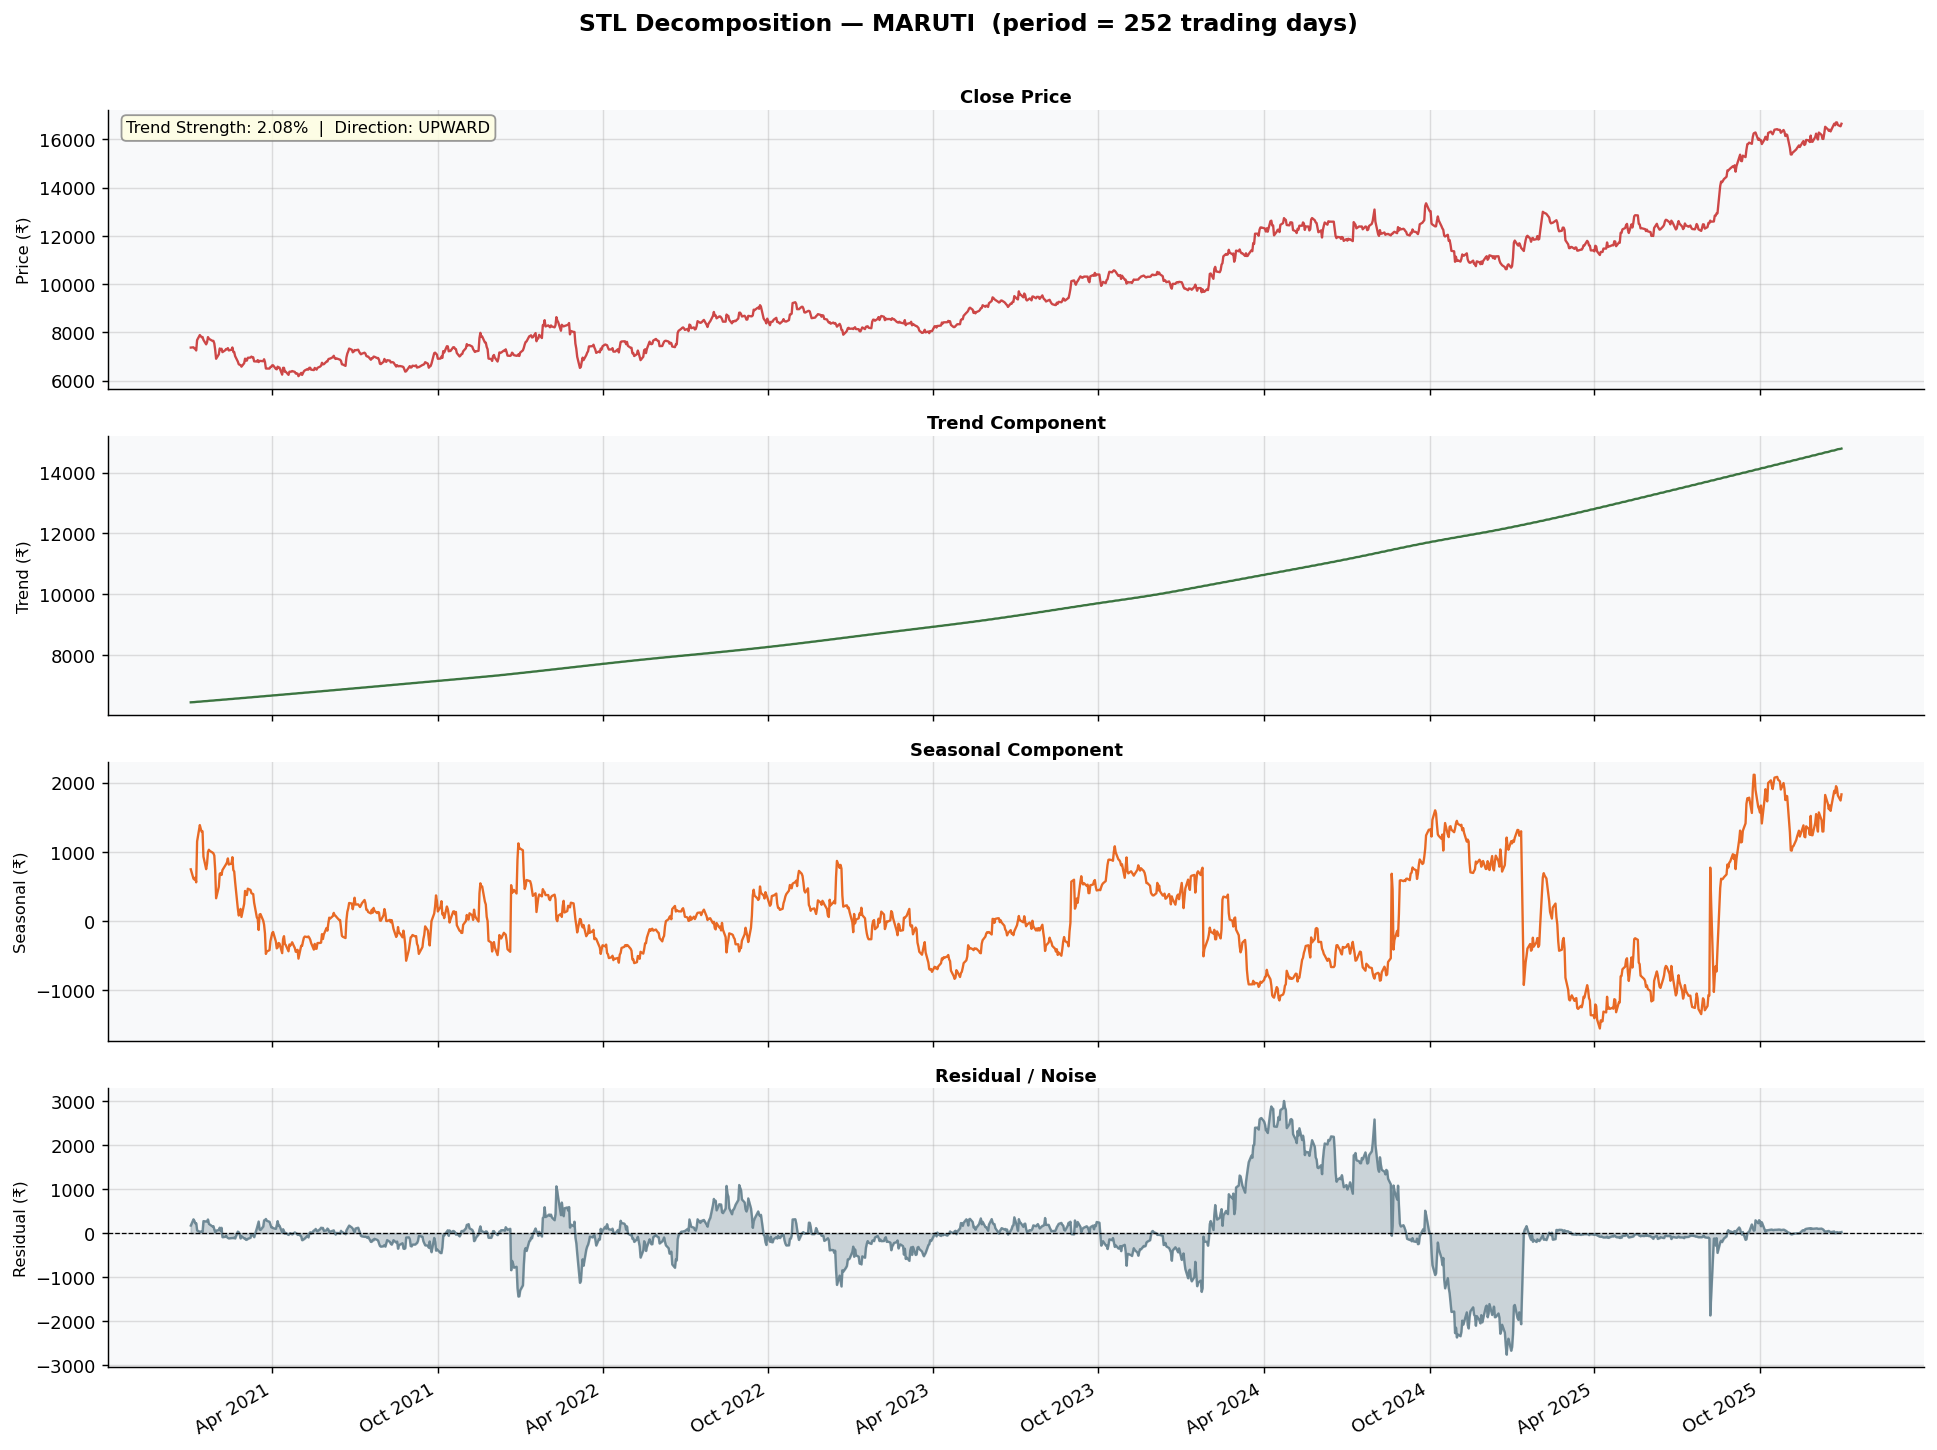


 Decomposition Summary:


,Stock,Sector,Trend Strength,Direction
0,RELIANCE,Energy,0.00%,UPWARD
1,HDFCBANK,Banking,26.14%,UPWARD
2,INFOSYS,IT,21.95%,UPWARD
3,SUNPHARMA,Pharma,0.00%,UPWARD
4,MARUTI,Auto,2.08%,UPWARD


In [15]:
# ── STL decomposition for all stocks ────────────────────────────────────────

def decompose_stock(series: pd.Series, stock_name: str, period: int = 252) -> dict:
    """
    Apply STL decomposition.
    period = 252 trading days ≈ one calendar year (annual seasonality).
    """
    clean = series.dropna()
    stl   = STL(clean, period=period, robust=True)
    res   = stl.fit()

    # Trend strength
    var_resid      = np.var(res.resid)
    var_detrended  = np.var(res.resid + res.seasonal)
    trend_strength = max(0.0, 1.0 - var_resid / var_detrended) if var_detrended != 0 else 0.0

    # Trend direction: compare recent 30d average vs 90–60d average
    trend_recent = res.trend.iloc[-30:].mean()
    trend_base   = res.trend.iloc[-90:-60].mean()
    direction    = 'UPWARD' if trend_recent > trend_base else 'DOWNWARD'

    # Plot
    fig, axes = plt.subplots(4, 1, figsize=(15, 11), sharex=True)
    color = STOCK_COLORS[stock_name]

    plots = [
        (clean,        color,    'Price (₹)',     'Close Price'),
        (res.trend,    '#1B5E20','Trend (₹)',     'Trend Component'),
        (res.seasonal, '#E65100','Seasonal (₹)', 'Seasonal Component'),
        (res.resid,    '#607D8B','Residual (₹)', 'Residual / Noise'),
    ]
    for ax, (data, c, ylabel, title) in zip(axes, plots):
        ax.plot(data, color=c, linewidth=1.3, alpha=0.85)
        if title == 'Residual / Noise':
            ax.axhline(0, color='black', linewidth=0.7, linestyle='--')
            ax.fill_between(data.index, data, 0, alpha=0.3, color=c)
        ax.set_ylabel(ylabel, fontsize=9)
        ax.set_title(title, fontsize=10, fontweight='bold', pad=4)

    axes[0].text(0.01, 0.92,
                 f'Trend Strength: {trend_strength:.2%}  |  Direction: {direction}',
                 transform=axes[0].transAxes, fontsize=9,
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow',
                           edgecolor='gray', alpha=0.8))

    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=30, ha='right')

    plt.suptitle(f'STL Decomposition — {stock_name}  (period = {period} trading days)',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(f'04_decomp_{stock_name.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()

    return {
        'trend':          res.trend,
        'seasonal':       res.seasonal,
        'resid':          res.resid,
        'trend_strength': trend_strength,
        'direction':      direction,
    }


decomp_results = {}
decomp_summary = []
for name in price_data:
    print(f"\nDecomposing: {name}")
    decomp_results[name] = decompose_stock(price_data[name], name)
    decomp_summary.append({
        'Stock':          name,
        'Sector':         SECTORS[name],
        'Trend Strength': f"{decomp_results[name]['trend_strength']:.2%}",
        'Direction':      decomp_results[name]['direction'],
    })

print("\n Decomposition Summary:")
display(pd.DataFrame(decomp_summary))

---
## ARIMA


In [16]:
# ── Evaluation metrics ──────────────────────────────────────────────────────

def compute_metrics(actual: pd.Series, predicted: pd.Series,
                    stock_name: str, model_name: str,
                    verbose: bool = True) -> dict:

    actual, predicted = actual.align(predicted, join='inner')
    actual, predicted = actual.dropna(), predicted.dropna()
    actual, predicted = actual.align(predicted, join='inner')

    rmse    = np.sqrt(mean_squared_error(actual, predicted))
    mape    = np.mean(np.abs((actual - predicted) / actual)) * 100

    actual_dir = np.sign(actual.diff().dropna())
    pred_dir   = np.sign(predicted.diff().dropna())
    actual_dir, pred_dir = actual_dir.align(pred_dir, join='inner')
    dir_acc    = np.mean(actual_dir == pred_dir) * 100

    if verbose:
        print(f"     RMSE={rmse:>8.2f} ₹   MAPE={mape:>6.2f}%   "
              f"Dir.Acc={dir_acc:>5.1f}%")

    return {'stock': stock_name, 'model': model_name,
            'RMSE': round(rmse, 2), 'MAPE': round(mape, 4),
            'Dir_Acc_%': round(dir_acc, 2)}


# ── Forecast plot function ───────────────────────────────────────────────────

def plot_forecast_chart(train, test, preds, fut_series, fut_ci,
                        stock_name, model_name, subtitle=''):
    """Generic forecast plot: train context | test predictions | future forecast."""
    fig, ax = plt.subplots(figsize=(15, 6))

    # Last 6 months of training for visual context
    train_ctx = train.iloc[-125:]
    ax.plot(train_ctx.index, train_ctx,
            color='#90A4AE', linewidth=1.2, label='Training (last 6m)', alpha=0.7)
    ax.plot(test.index, test,
            color='#1B5E20', linewidth=2.0, label='Actual (test set)')
    ax.plot(preds.index, preds,
            color='#C62828', linewidth=1.5, linestyle='--',
            label=f'{model_name} predictions', alpha=0.9)

    if fut_series is not None:
        ax.plot(fut_series.index, fut_series,
                color='#E65100', linewidth=2.2, marker='o',
                markersize=6, label='5-day forecast')
        if fut_ci is not None:
            ax.fill_between(fut_ci.index,
                            fut_ci.iloc[:, 0], fut_ci.iloc[:, 1],
                            alpha=0.20, color='#E65100', label='95% CI')

    ax.axvline(test.index[0], color='gray', linestyle=':', linewidth=1.5)
    ax.annotate('Train | Test', xy=(test.index[0], ax.get_ylim()[0]),
                xytext=(5, 5), textcoords='offset points', fontsize=8, color='gray')

    ax.set_title(f'{stock_name} — {model_name} Forecast  {subtitle}',
                 fontsize=13, fontweight='bold', pad=10)
    ax.set_ylabel('Close Price (₹)', fontsize=11)
    ax.legend(loc='upper left', fontsize=9, ncol=3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

    plt.tight_layout()
    plt.savefig(f'05_forecast_{model_name.lower()}_{stock_name.lower()}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

ARIMA MODELLING — ALL STOCKS

───────────────────────────────────────────────────────
ARIMA  |  RELIANCE
───────────────────────────────────────────────────────
  [1/3] Finding optimal order via AIC …  Best order: ARIMA(0, 1, 0)   AIC=9965.42
  [2/3] Walk-forward forecast on 131 test days …  

/tmp/ipykernel_3464/1087672322.py:31: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  yhat    = float(fit.forecast(steps=1))


done
  [3/3] Fitting final model on full data for 5-day forecast …  done
  Metrics:      RMSE=   13.86 ₹   MAPE=  0.69%   Dir.Acc= 41.5%


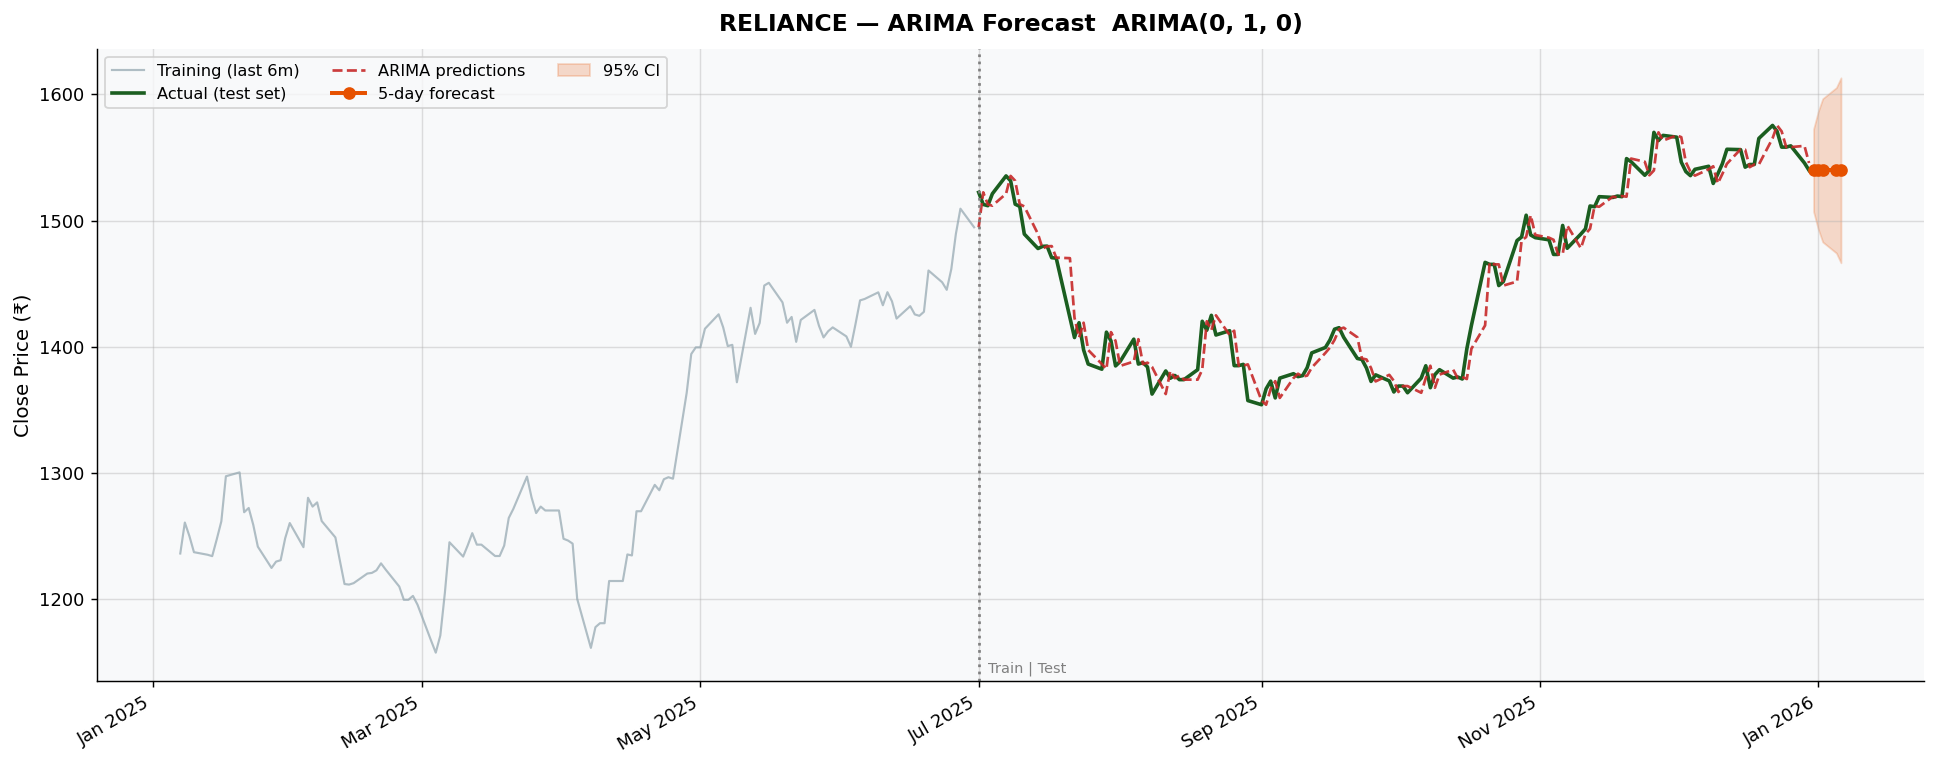


  5-Day Future Forecast (ARIMA(0, 1, 0)):
  Date             Forecast (₹)   Lower 95% (₹)   Upper 95% (₹)
  2025-12-31            1539.80         1506.98         1572.62
  2026-01-01            1539.80         1493.39         1586.21
  2026-01-02            1539.80         1482.96         1596.64
  2026-01-05            1539.80         1474.17         1605.43
  2026-01-06            1539.80         1466.42         1613.18

───────────────────────────────────────────────────────
ARIMA  |  HDFCBANK
───────────────────────────────────────────────────────
  [1/3] Finding optimal order via AIC …  Best order: ARIMA(1, 1, 1)   AIC=8763.21
  [2/3] Walk-forward forecast on 131 test days …  

/tmp/ipykernel_3464/1087672322.py:31: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  yhat    = float(fit.forecast(steps=1))


done
  [3/3] Fitting final model on full data for 5-day forecast …  done
  Metrics:      RMSE=    6.81 ₹   MAPE=  0.53%   Dir.Acc= 51.5%


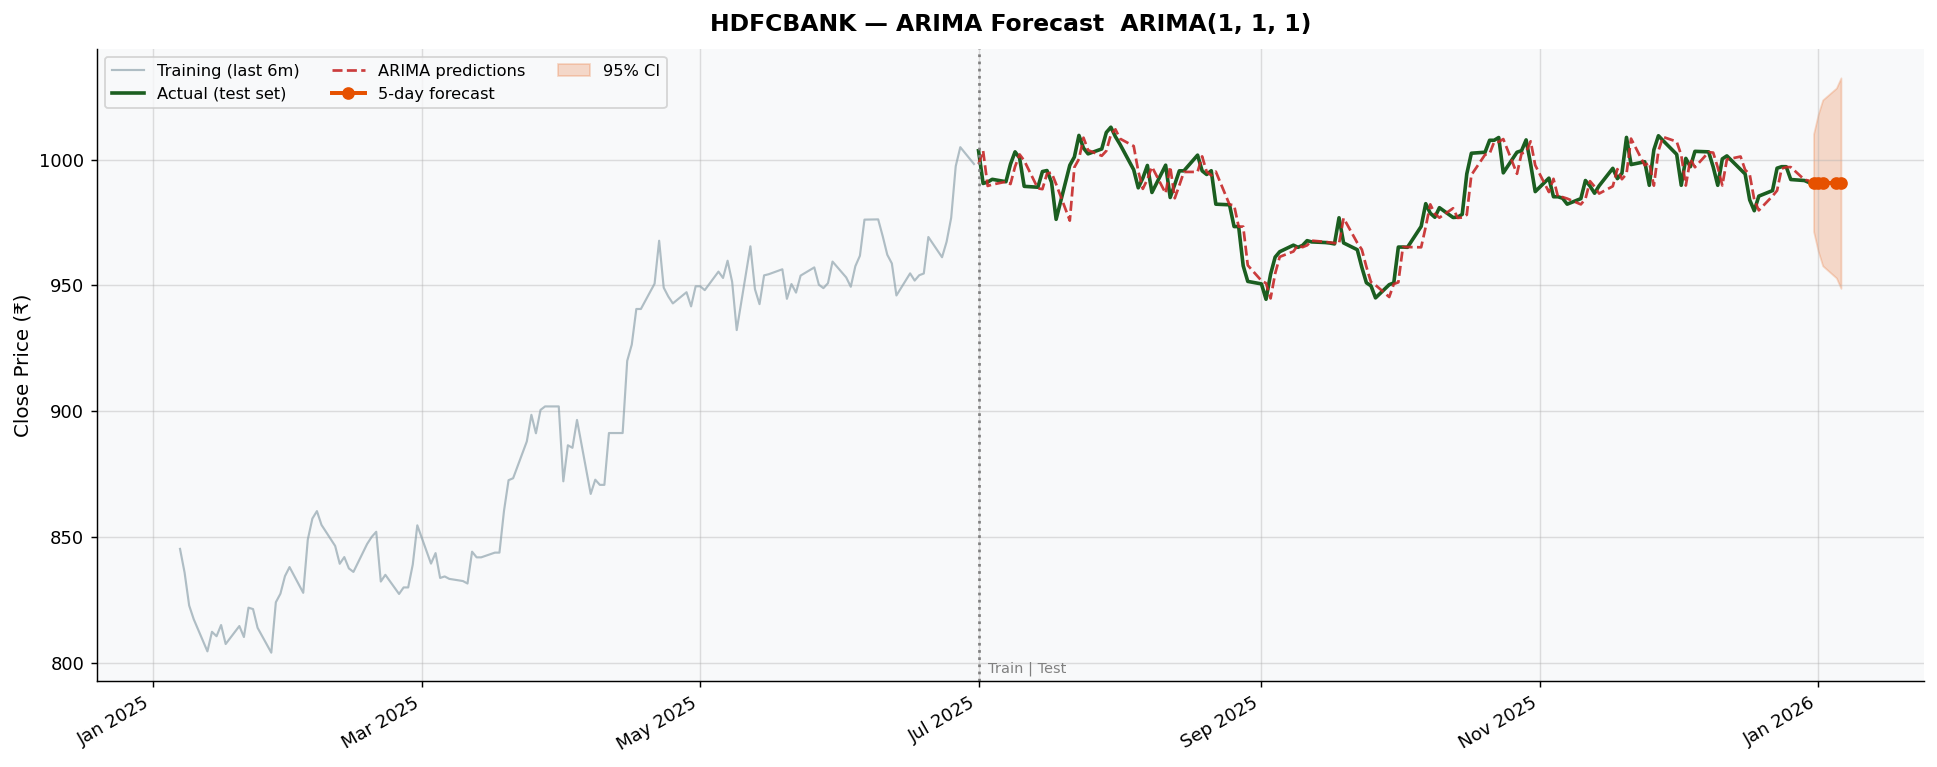


  5-Day Future Forecast (ARIMA(1, 1, 1)):
  Date             Forecast (₹)   Lower 95% (₹)   Upper 95% (₹)
  2025-12-31             990.85          971.46         1010.24
  2026-01-01             990.81          963.64         1017.98
  2026-01-02             990.76          957.78         1023.74
  2026-01-05             990.72          952.97         1028.47
  2026-01-06             990.68          948.83         1032.53

───────────────────────────────────────────────────────
ARIMA  |  INFOSYS
───────────────────────────────────────────────────────
  [1/3] Finding optimal order via AIC …  Best order: ARIMA(0, 1, 0)   AIC=10556.79
  [2/3] Walk-forward forecast on 131 test days …  

/tmp/ipykernel_3464/1087672322.py:31: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  yhat    = float(fit.forecast(steps=1))


done
  [3/3] Fitting final model on full data for 5-day forecast …  done
  Metrics:      RMSE=   19.87 ₹   MAPE=  0.96%   Dir.Acc= 42.3%


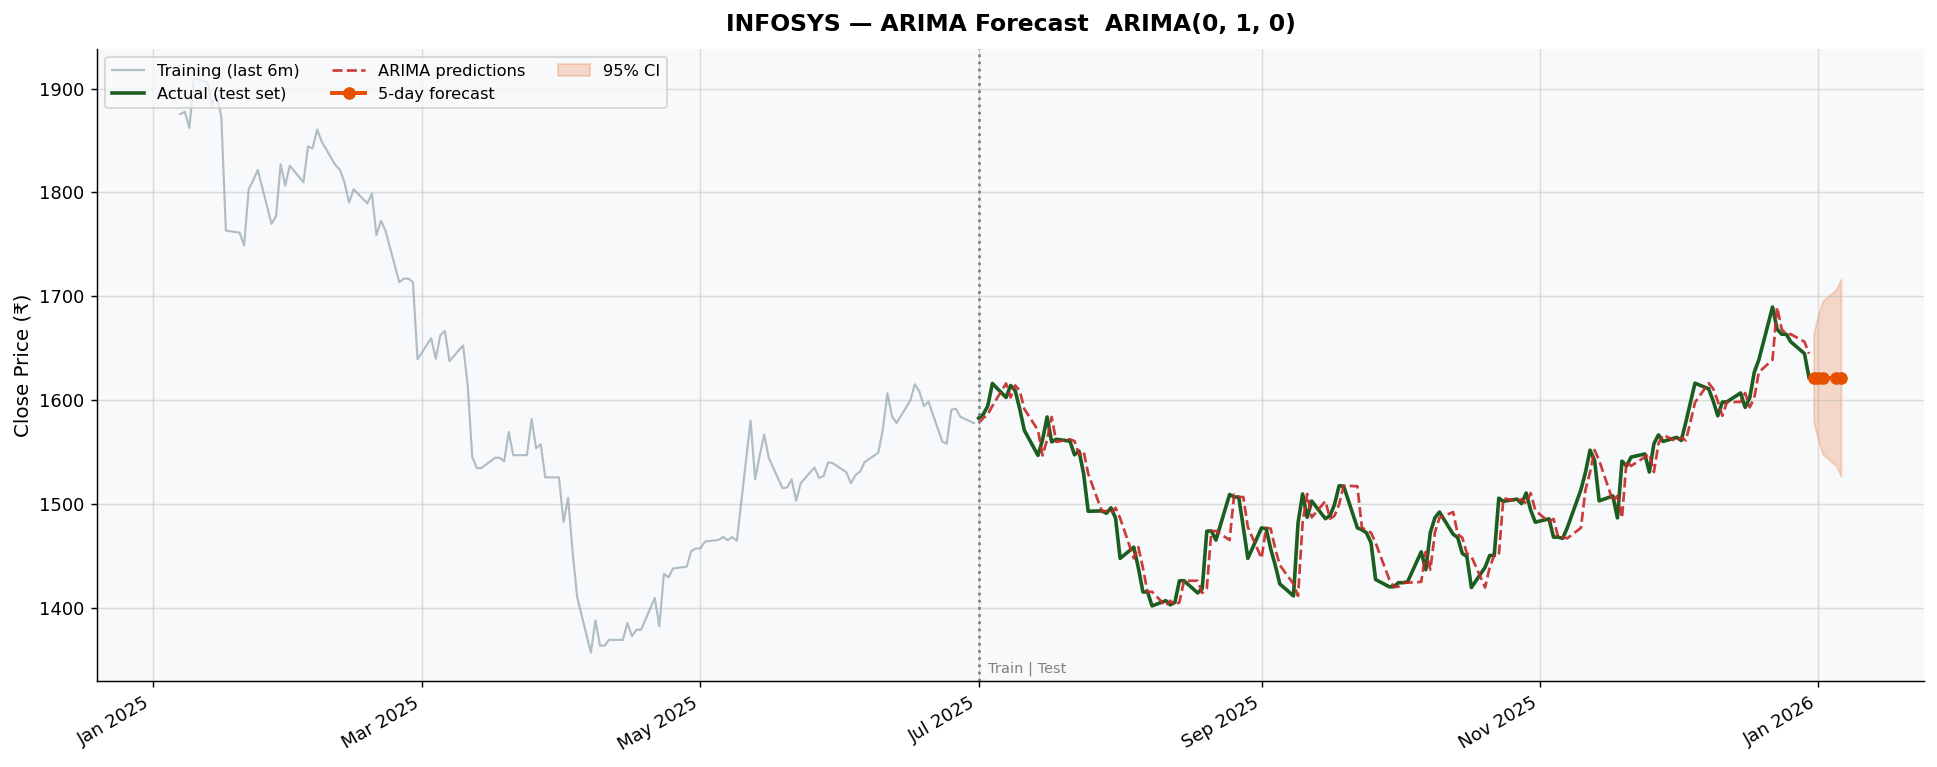


  5-Day Future Forecast (ARIMA(0, 1, 0)):
  Date             Forecast (₹)   Lower 95% (₹)   Upper 95% (₹)
  2025-12-31            1621.60         1579.01         1664.19
  2026-01-01            1621.60         1561.37         1681.83
  2026-01-02            1621.60         1547.83         1695.37
  2026-01-05            1621.60         1536.42         1706.78
  2026-01-06            1621.60         1526.36         1716.84

───────────────────────────────────────────────────────
ARIMA  |  SUNPHARMA
───────────────────────────────────────────────────────
  [1/3] Finding optimal order via AIC …  Best order: ARIMA(0, 1, 1)   AIC=9633.48
  [2/3] Walk-forward forecast on 131 test days …  

/tmp/ipykernel_3464/1087672322.py:31: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  yhat    = float(fit.forecast(steps=1))


done
  [3/3] Fitting final model on full data for 5-day forecast …  done
  Metrics:      RMSE=   17.02 ₹   MAPE=  0.73%   Dir.Acc= 47.7%


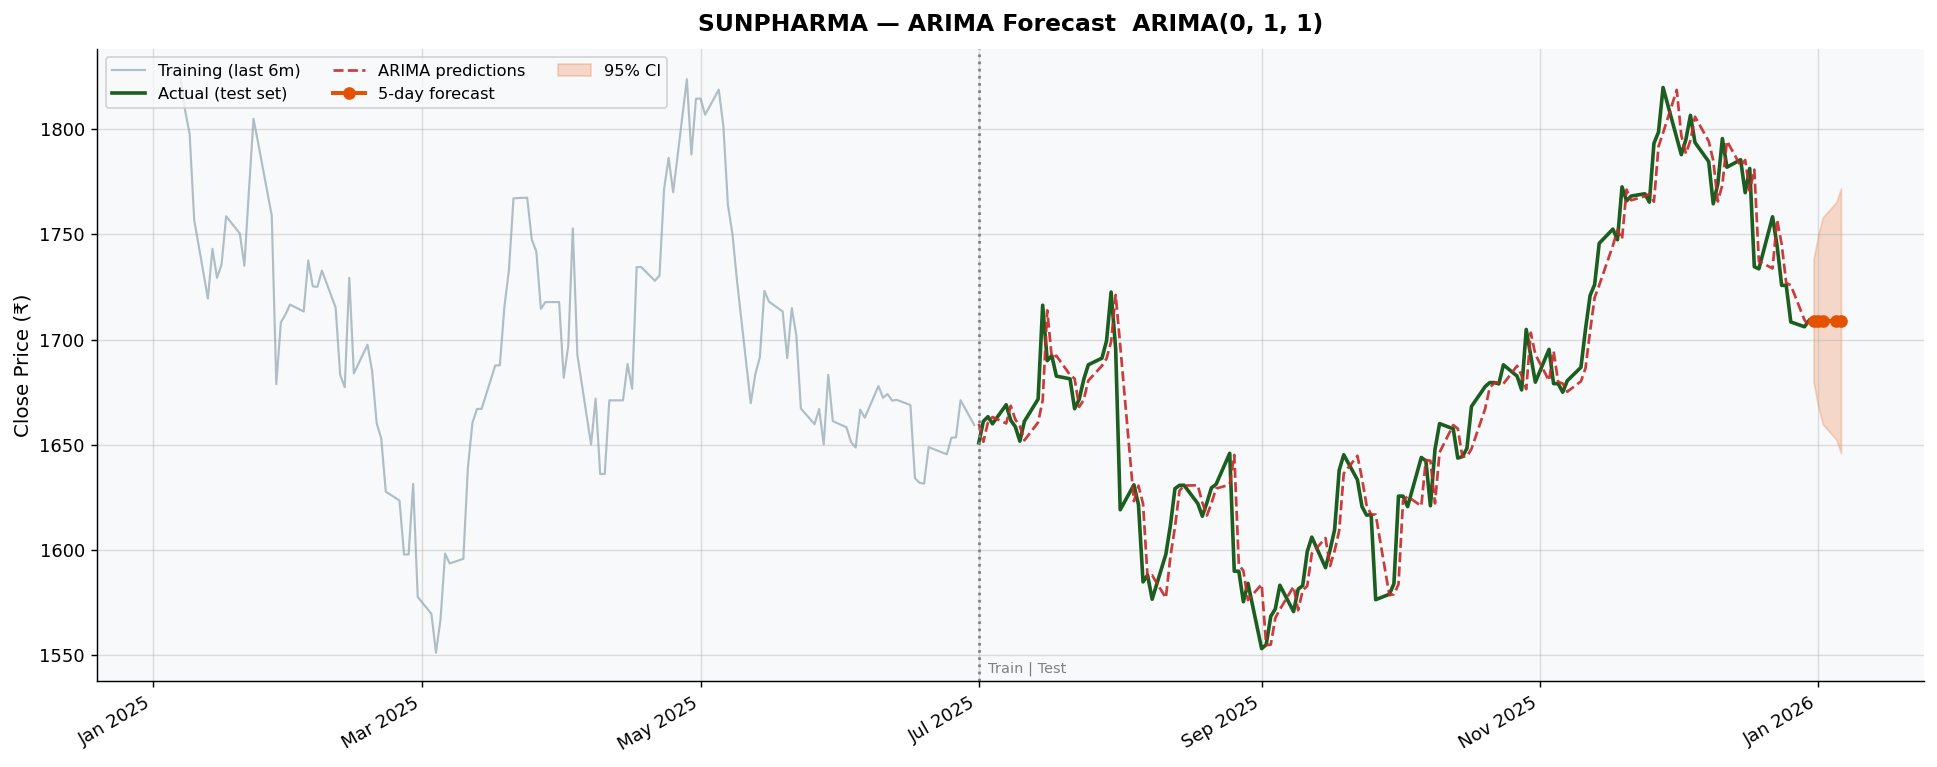


  5-Day Future Forecast (ARIMA(0, 1, 1)):
  Date             Forecast (₹)   Lower 95% (₹)   Upper 95% (₹)
  2025-12-31            1708.94         1679.48         1738.40
  2026-01-01            1708.94         1668.43         1749.45
  2026-01-02            1708.94         1659.81         1758.07
  2026-01-05            1708.94         1652.49         1765.40
  2026-01-06            1708.94         1646.01         1771.87

───────────────────────────────────────────────────────
ARIMA  |  MARUTI
───────────────────────────────────────────────────────
  [1/3] Finding optimal order via AIC …  Best order: ARIMA(0, 1, 1)   AIC=14789.64
  [2/3] Walk-forward forecast on 131 test days …  

/tmp/ipykernel_3464/1087672322.py:31: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  yhat    = float(fit.forecast(steps=1))


done
  [3/3] Fitting final model on full data for 5-day forecast …  done
  Metrics:      RMSE=  171.88 ₹   MAPE=  0.78%   Dir.Acc= 48.5%


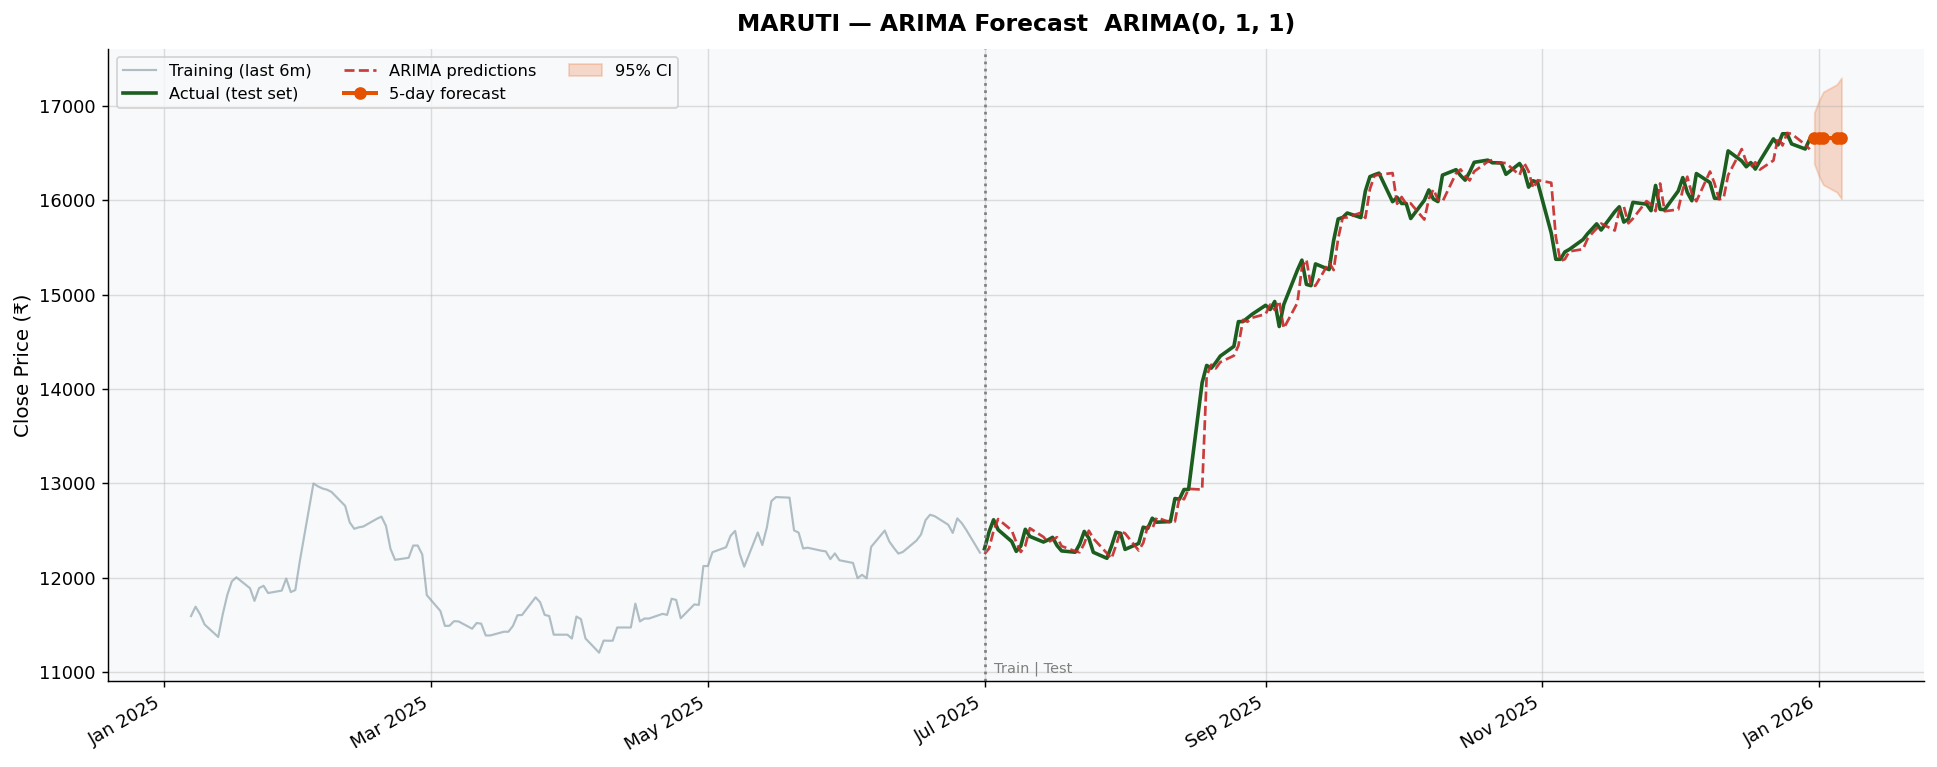


  5-Day Future Forecast (ARIMA(0, 1, 1)):
  Date             Forecast (₹)   Lower 95% (₹)   Upper 95% (₹)
  2025-12-31           16654.96        16384.36        16925.57
  2026-01-01           16654.96        16257.96        17051.97
  2026-01-02           16654.96        16163.03        17146.89
  2026-01-05           16654.96        16083.67        17226.26
  2026-01-06           16654.96        16014.06        17295.87

 ARIMA modelling complete for all stocks.


In [18]:
# ── ARIMA model builder ──────────────────────────────────────────────────────

def build_arima(train: pd.Series, test: pd.Series, stock_name: str) -> dict:
    print(f"\n{'─'*55}")
    print(f"ARIMA  |  {stock_name}")
    print(f"{'─'*55}")

    # ── Step 1: auto_arima ───────────────────────────────────────────────────
    print("  [1/3] Finding optimal order via AIC …", end="  ")
    auto_mdl = pm.auto_arima(
        train,
        d=1,               # confirmed via ADF test
        start_p=0, max_p=5,
        start_q=0, max_q=5,
        seasonal=False,
        information_criterion='aic',
        stepwise=True,
        suppress_warnings=True,
        error_action='ignore',
    )
    order = auto_mdl.order
    print(f"Best order: ARIMA{order}   AIC={auto_mdl.aic():.2f}")

    # ── Step 2: walk-forward validation ──────────────────────────────────────
    print(f"  [2/3] Walk-forward forecast on {len(test)} test days …", end="  ")
    history = list(train)
    preds   = []
    for t in range(len(test)):
        mdl     = ARIMA(history, order=order)
        fit     = mdl.fit()
        yhat    = float(fit.forecast(steps=1))
        preds.append(yhat)
        history.append(float(test.iloc[t]))   # append ACTUAL value → realistic

    preds_series = pd.Series(preds, index=test.index)
    print("done")

    # ── Step 3: 5-day future forecast ────────────────────────────────────────
    print("  [3/3] Fitting final model on full data for 5-day forecast …", end="  ")
    full_series = pd.concat([train, test])
    final_mdl   = ARIMA(full_series, order=order).fit()
    fc_result   = final_mdl.get_forecast(steps=5)
    fc_mean     = fc_result.predicted_mean
    fc_ci       = fc_result.conf_int(alpha=0.05)

    future_dates = pd.bdate_range(
        start=test.index[-1] + timedelta(days=1), periods=5)
    fc_series        = pd.Series(fc_mean.values,         index=future_dates)
    fc_ci.index      = future_dates

    print("done")

    # ── Metrics ──────────────────────────────────────────────────────────────
    print("  Metrics: ", end="")
    metrics = compute_metrics(test, preds_series, stock_name, 'ARIMA')

    # ── Plot ─────────────────────────────────────────────────────────────────
    plot_forecast_chart(train, test, preds_series, fc_series, fc_ci,
                        stock_name, 'ARIMA', subtitle=f'ARIMA{order}')

    # ── 5-day forecast table ─────────────────────────────────────────────────
    print(f"\n  5-Day Future Forecast (ARIMA{order}):")
    print(f"  {'Date':<14} {'Forecast (₹)':>14} {'Lower 95% (₹)':>15} {'Upper 95% (₹)':>15}")
    for date, val in fc_series.items():
        lo = fc_ci.loc[date].iloc[0]
        hi = fc_ci.loc[date].iloc[1]
        print(f"  {str(date.date()):<14} {val:>14.2f} {lo:>15.2f} {hi:>15.2f}")

    return {
        'order':       order,
        'aic':         auto_mdl.aic(),
        'predictions': preds_series,
        'forecast':    fc_series,
        'forecast_ci': fc_ci,
        'metrics':     metrics,
        'final_model': final_mdl,
    }


# ── Run ARIMA for all stocks ─────────────────────────────────────────────────
print("=" * 60)
print("ARIMA MODELLING — ALL STOCKS")
print("=" * 60)

arima_results = {}
for name in price_data:
    arima_results[name] = build_arima(
        train_data[name], test_data[name], name)

print("\n ARIMA modelling complete for all stocks.")

---
## Prophet

PROPHET MODELLING — ALL STOCKS

───────────────────────────────────────────────────────
Prophet  |  RELIANCE
───────────────────────────────────────────────────────
  Metrics:      RMSE=  231.48 ₹   MAPE= 12.97%   Dir.Acc= 43.1%


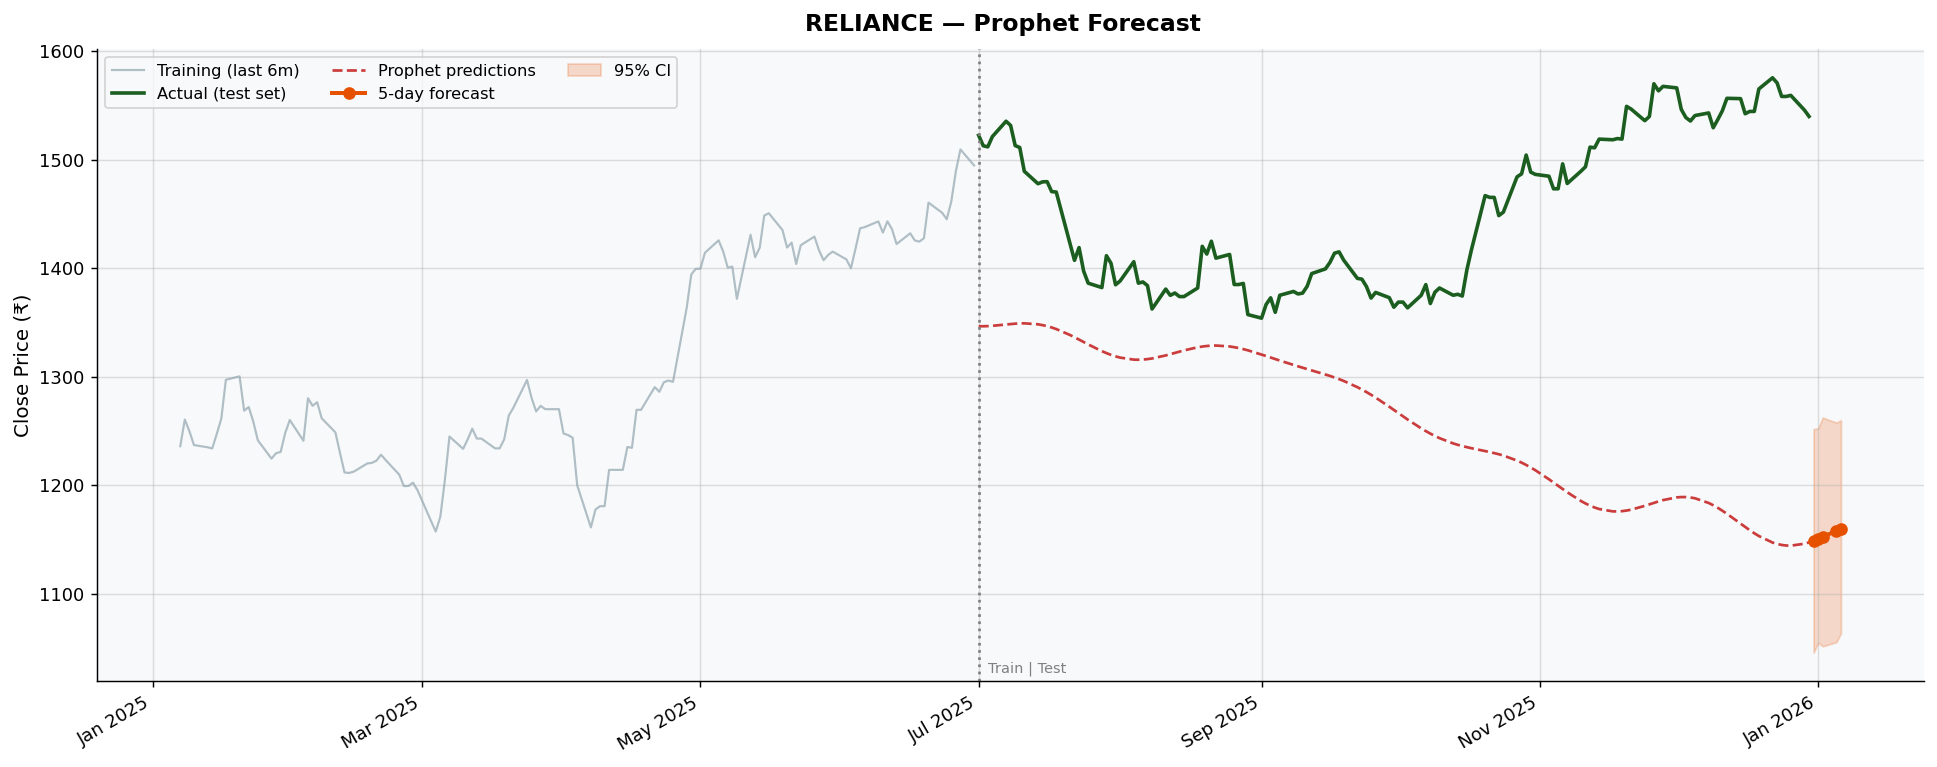


  5-Day Future Forecast (Prophet):
  Date             Forecast (₹)   Lower 95% (₹)   Upper 95% (₹)
  2025-12-31            1148.76         1045.66         1251.70
  2026-01-01            1150.44         1054.80         1252.28
  2026-01-02            1152.26         1051.49         1262.36
  2026-01-05            1157.99         1055.36         1257.64
  2026-01-06            1159.79         1063.35         1259.95

───────────────────────────────────────────────────────
Prophet  |  HDFCBANK
───────────────────────────────────────────────────────
  Metrics:      RMSE=   40.96 ₹   MAPE=  3.59%   Dir.Acc= 51.5%


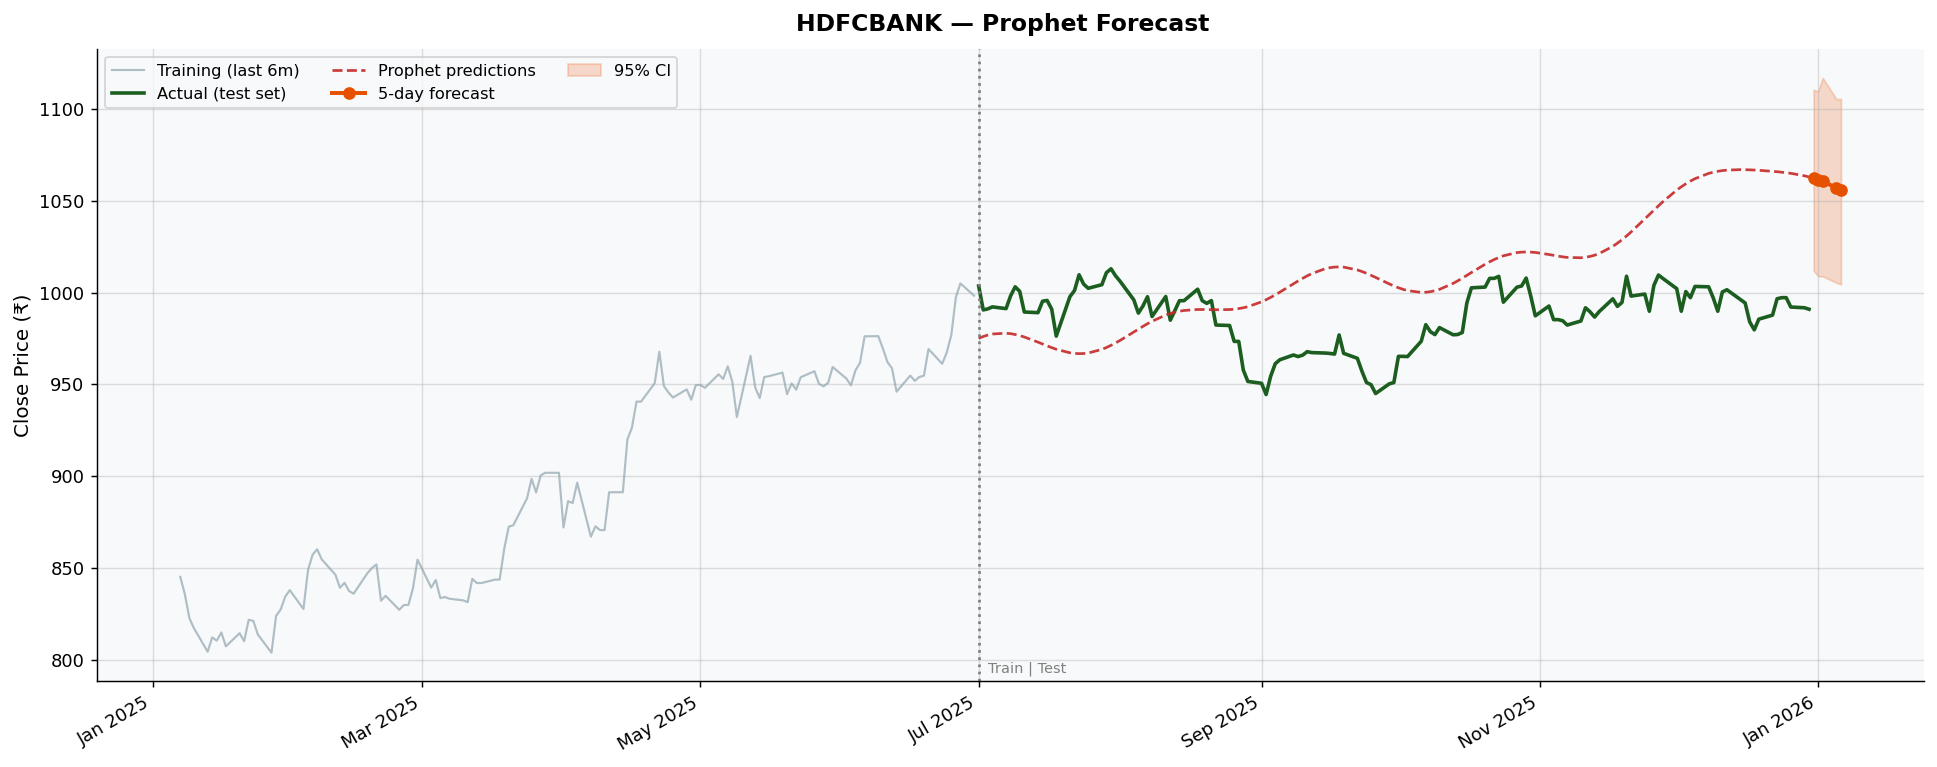


  5-Day Future Forecast (Prophet):
  Date             Forecast (₹)   Lower 95% (₹)   Upper 95% (₹)
  2025-12-31            1062.17         1011.78         1110.27
  2026-01-01            1061.36         1008.88         1109.53
  2026-01-02            1060.44         1008.84         1116.83
  2026-01-05            1056.98         1005.32         1105.23
  2026-01-06            1055.61         1004.39         1105.35

───────────────────────────────────────────────────────
Prophet  |  INFOSYS
───────────────────────────────────────────────────────
  Metrics:      RMSE=  153.46 ₹   MAPE=  9.37%   Dir.Acc= 52.3%


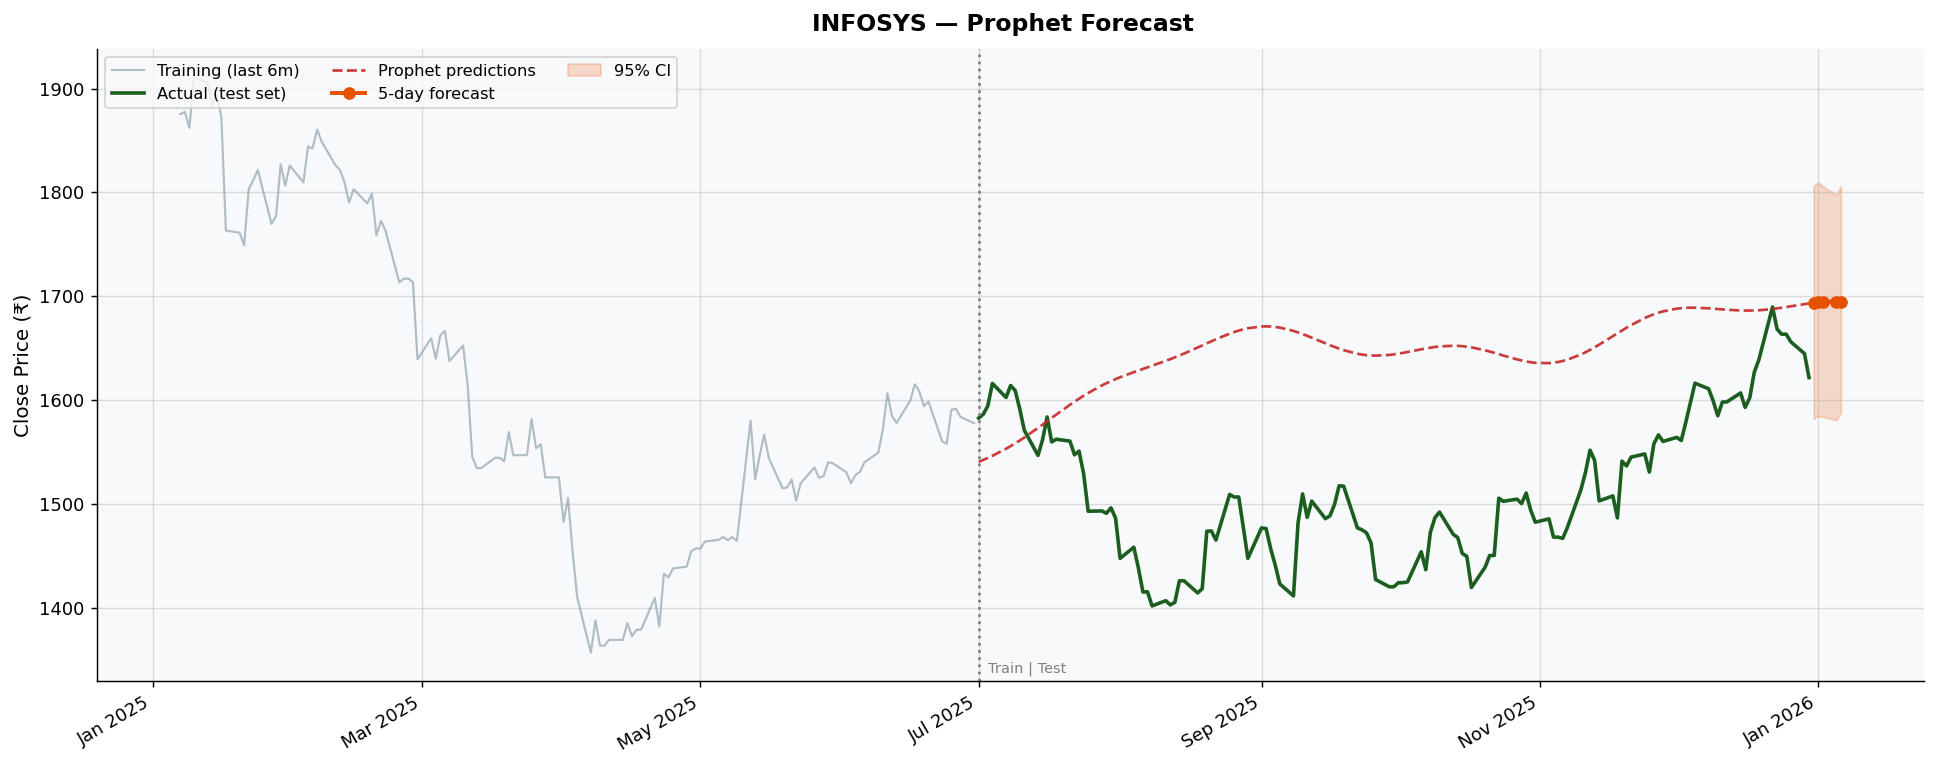


  5-Day Future Forecast (Prophet):
  Date             Forecast (₹)   Lower 95% (₹)   Upper 95% (₹)
  2025-12-31            1693.63         1582.13         1805.81
  2026-01-01            1694.12         1584.34         1809.74
  2026-01-02            1694.51         1583.77         1806.03
  2026-01-05            1694.87         1580.61         1797.57
  2026-01-06            1694.70         1587.72         1806.16

───────────────────────────────────────────────────────
Prophet  |  SUNPHARMA
───────────────────────────────────────────────────────
  Metrics:      RMSE=  181.36 ₹   MAPE=  9.79%   Dir.Acc= 48.5%


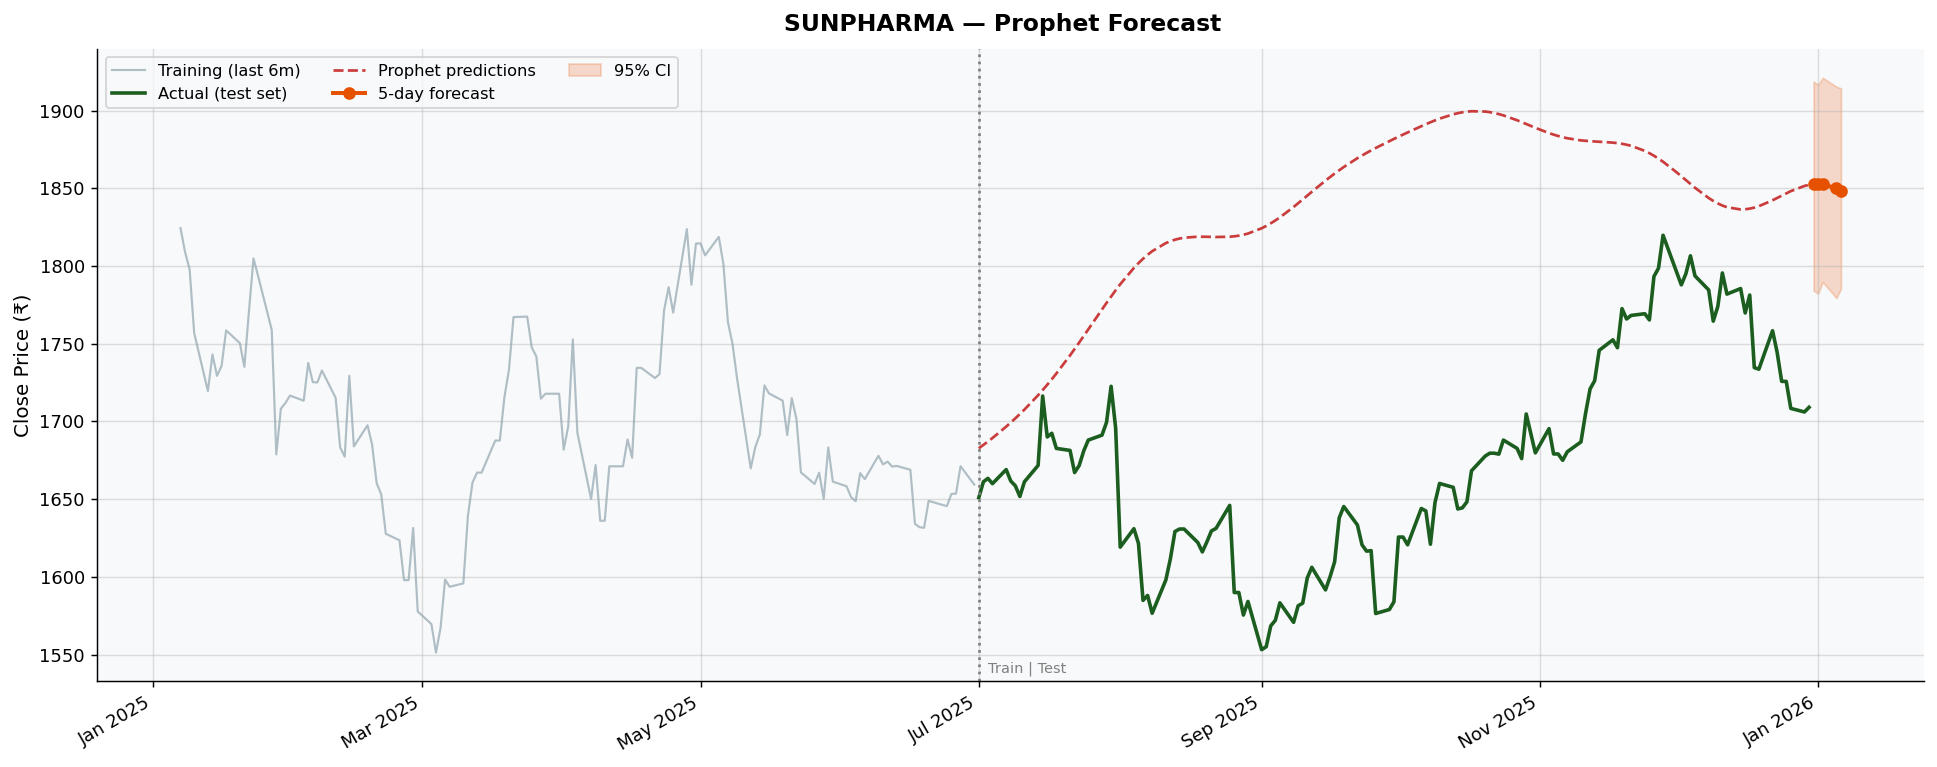


  5-Day Future Forecast (Prophet):
  Date             Forecast (₹)   Lower 95% (₹)   Upper 95% (₹)
  2025-12-31            1852.61         1784.17         1918.58
  2026-01-01            1852.72         1782.27         1916.54
  2026-01-02            1852.52         1789.71         1921.08
  2026-01-05            1850.01         1779.42         1915.38
  2026-01-06            1848.56         1785.34         1914.31

───────────────────────────────────────────────────────
Prophet  |  MARUTI
───────────────────────────────────────────────────────
  Metrics:      RMSE= 3205.42 ₹   MAPE= 17.30%   Dir.Acc= 48.5%


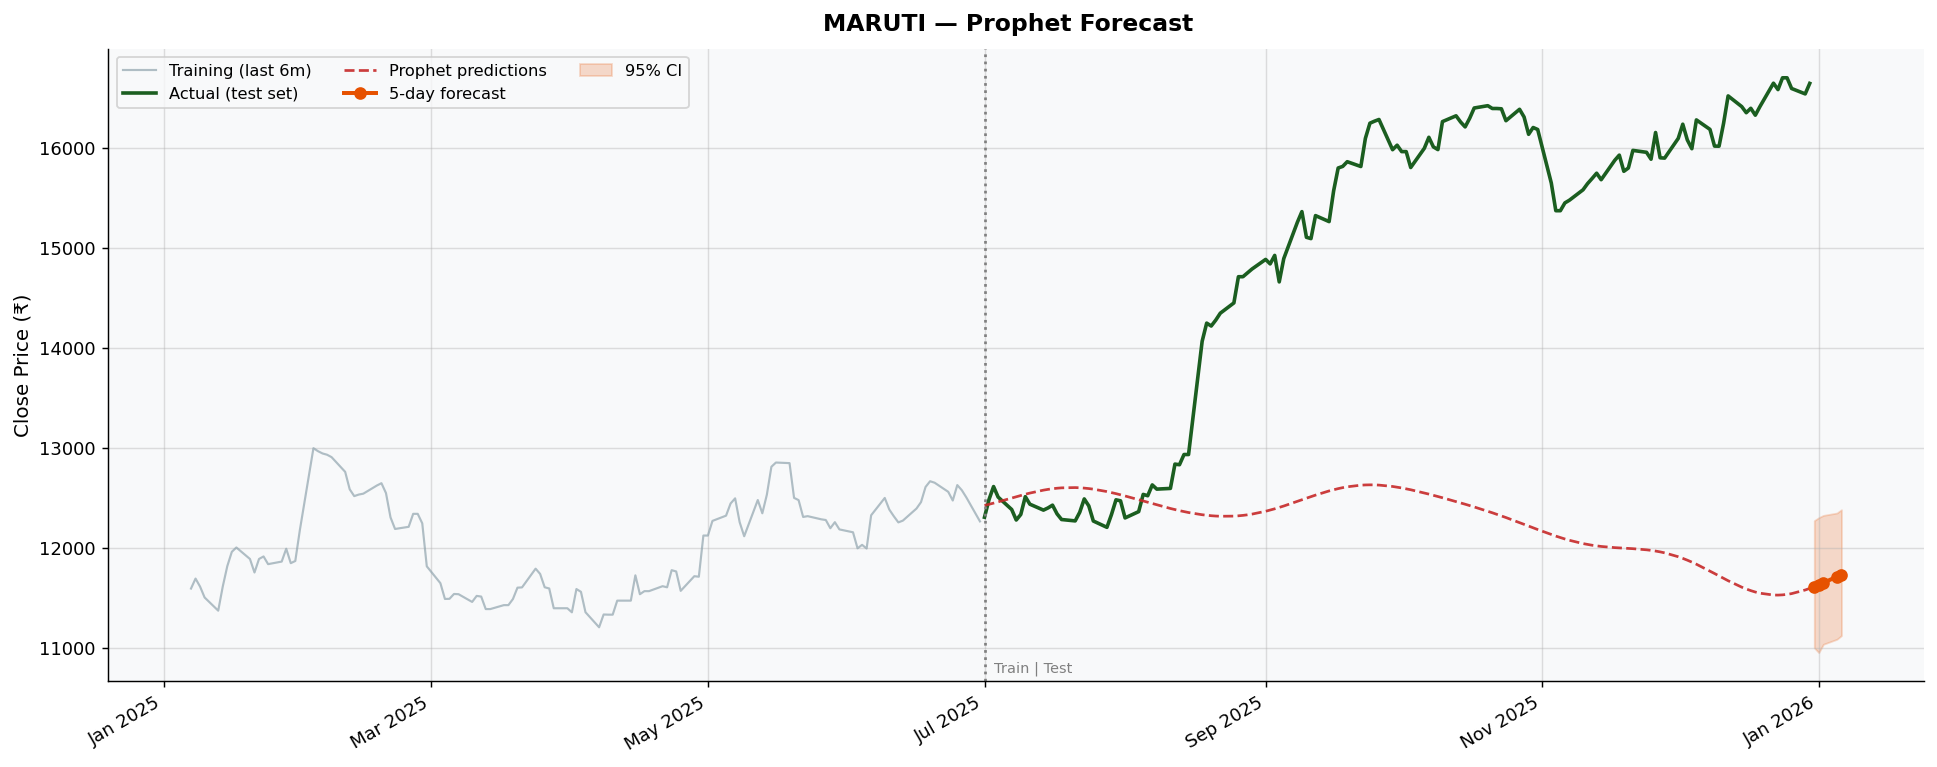


  5-Day Future Forecast (Prophet):
  Date             Forecast (₹)   Lower 95% (₹)   Upper 95% (₹)
  2025-12-31           11614.74        11003.18        12275.22
  2026-01-01           11633.40        10954.74        12304.78
  2026-01-02           11652.98        11038.50        12327.14
  2026-01-05           11714.58        11088.60        12351.10
  2026-01-06           11735.25        11125.09        12384.30

 Prophet modelling complete for all stocks.


In [20]:
# ── Prophet model builder ────────────────────────────────────────────────────

def build_prophet(train: pd.Series, test: pd.Series, stock_name: str) -> dict:
    """
    Fit Facebook Prophet on training data.
    Evaluate on test period.
    Forecast 5 days beyond the dataset.
    """
    print(f"\n{'─'*55}")
    print(f"Prophet  |  {stock_name}")
    print(f"{'─'*55}")

    # Prophet requires columns 'ds' (datetime) and 'y' (value)
    train_df = pd.DataFrame({
        'ds': train.index,
        'y':  train.values,
    }).reset_index(drop=True)

    # ── Fit ──────────────────────────────────────────────────────────────────
    model = Prophet(
        yearly_seasonality   = True,    # Annual patterns (e.g., budget season)
        weekly_seasonality   = False,   # No meaningful weekly pattern in daily Close prices
        daily_seasonality    = False,   # Not applicable to daily data
        changepoint_prior_scale = 0.05, # Flexibility of trend — lower = smoother, less overfit
        interval_width       = 0.95,    # 95% prediction interval
        seasonality_mode     = 'additive',
    )
    model.fit(train_df)

    # ── Predict over test period ──────────────────────────────────────────────
    test_future = pd.DataFrame({'ds': test.index})
    test_fc     = model.predict(test_future).set_index('ds')
    test_preds  = test_fc['yhat'].reindex(test.index)

    # ── 5-day future forecast ─────────────────────────────────────────────────
    future_dates = pd.bdate_range(
        start=test.index[-1] + timedelta(days=1), periods=5)
    future_df = pd.DataFrame({'ds': future_dates})
    future_fc  = model.predict(future_df).set_index('ds')

    fc_series = future_fc['yhat']
    fc_ci     = future_fc[['yhat_lower', 'yhat_upper']]
    fc_ci.columns = ['lower_95', 'upper_95']

    # ── Metrics ──────────────────────────────────────────────────────────────
    print("  Metrics: ", end="")
    metrics = compute_metrics(test, test_preds, stock_name, 'Prophet')

    # ── Plot ─────────────────────────────────────────────────────────────────
    plot_forecast_chart(train, test, test_preds, fc_series, fc_ci,
                        stock_name, 'Prophet')

    # ── 5-day forecast table ─────────────────────────────────────────────────
    print(f"\n  5-Day Future Forecast (Prophet):")
    print(f"  {'Date':<14} {'Forecast (₹)':>14} {'Lower 95% (₹)':>15} {'Upper 95% (₹)':>15}")
    for date in future_dates:
        val = fc_series[date]
        lo  = fc_ci.loc[date, 'lower_95']
        hi  = fc_ci.loc[date, 'upper_95']
        print(f"  {str(date.date()):<14} {val:>14.2f} {lo:>15.2f} {hi:>15.2f}")

    return {
        'model':       model,
        'predictions': test_preds,
        'forecast':    fc_series,
        'forecast_ci': fc_ci,
        'metrics':     metrics,
    }


# ── Run Prophet for all stocks ────────────────────────────────────────────────
print("=" * 60)
print("PROPHET MODELLING — ALL STOCKS")
print("=" * 60)

prophet_results = {}
for name in price_data:
    prophet_results[name] = build_prophet(
        train_data[name], test_data[name], name)

print("\n Prophet modelling complete for all stocks.")

---
## Ensemble Forecasting (ARIMA + Prophet Average)

$$\hat{y}_{\text{ensemble}}(t) = 0.5 \times \hat{y}_{\text{ARIMA}}(t) + 0.5 \times \hat{y}_{\text{Prophet}}(t)$$


In [21]:
# ── Build ensemble forecasts ─────────────────────────────────────────────────

ensemble_results = {}
all_metrics      = []

print("ENSEMBLE (ARIMA + Prophet simple average)\n")
print(f"{'Stock':<12} {'RMSE':>8} {'MAPE %':>8} {'Dir.Acc%':>10}")
print("─" * 42)

for name in price_data:
    a_pred = arima_results[name]['predictions']
    p_pred = prophet_results[name]['predictions']

    # Align indices
    a_pred, p_pred = a_pred.align(p_pred, join='inner')
    ens_pred = (a_pred + p_pred) / 2.0

    a_fc  = arima_results[name]['forecast']
    p_fc  = prophet_results[name]['forecast']
    a_fc, p_fc = a_fc.align(p_fc, join='inner')
    ens_fc = (a_fc + p_fc) / 2.0

    # Confidence interval: take the outer bounds of both models
    a_ci  = arima_results[name]['forecast_ci']
    p_ci  = prophet_results[name]['forecast_ci']
    a_ci  = a_ci.reindex(ens_fc.index)
    p_ci  = p_ci.reindex(ens_fc.index)
    ens_ci = pd.DataFrame({
        'lower': np.minimum(a_ci.iloc[:, 0].values, p_ci.iloc[:, 0].values),
        'upper': np.maximum(a_ci.iloc[:, 1].values, p_ci.iloc[:, 1].values),
    }, index=ens_fc.index)

    metrics = compute_metrics(test_data[name], ens_pred, name, 'Ensemble',
                              verbose=False)
    print(f"  {name:<10} {metrics['RMSE']:>8.2f} {metrics['MAPE']:>8.4f} "
          f"{metrics['Dir_Acc_%']:>10.2f}")

    ensemble_results[name] = {
        'predictions': ens_pred,
        'forecast':    ens_fc,
        'forecast_ci': ens_ci,
        'metrics':     metrics,
    }

    # Collect all metrics for comparison table
    for model_res, model_name in [(arima_results[name], 'ARIMA'),
                                   (prophet_results[name], 'Prophet'),
                                   (ensemble_results[name], 'Ensemble')]:
        all_metrics.append(model_res['metrics'])

print("\n Ensemble forecasts computed.")

ENSEMBLE (ARIMA + Prophet simple average)

Stock            RMSE   MAPE %   Dir.Acc%
──────────────────────────────────────────
  RELIANCE     116.61   6.4961      46.92
  HDFCBANK      21.08   1.8229      49.23
  INFOSYS       77.72   4.7172      43.08
  SUNPHARMA     91.12   4.9056      47.69
  MARUTI      1617.56   8.7796      46.92

 Ensemble forecasts computed.


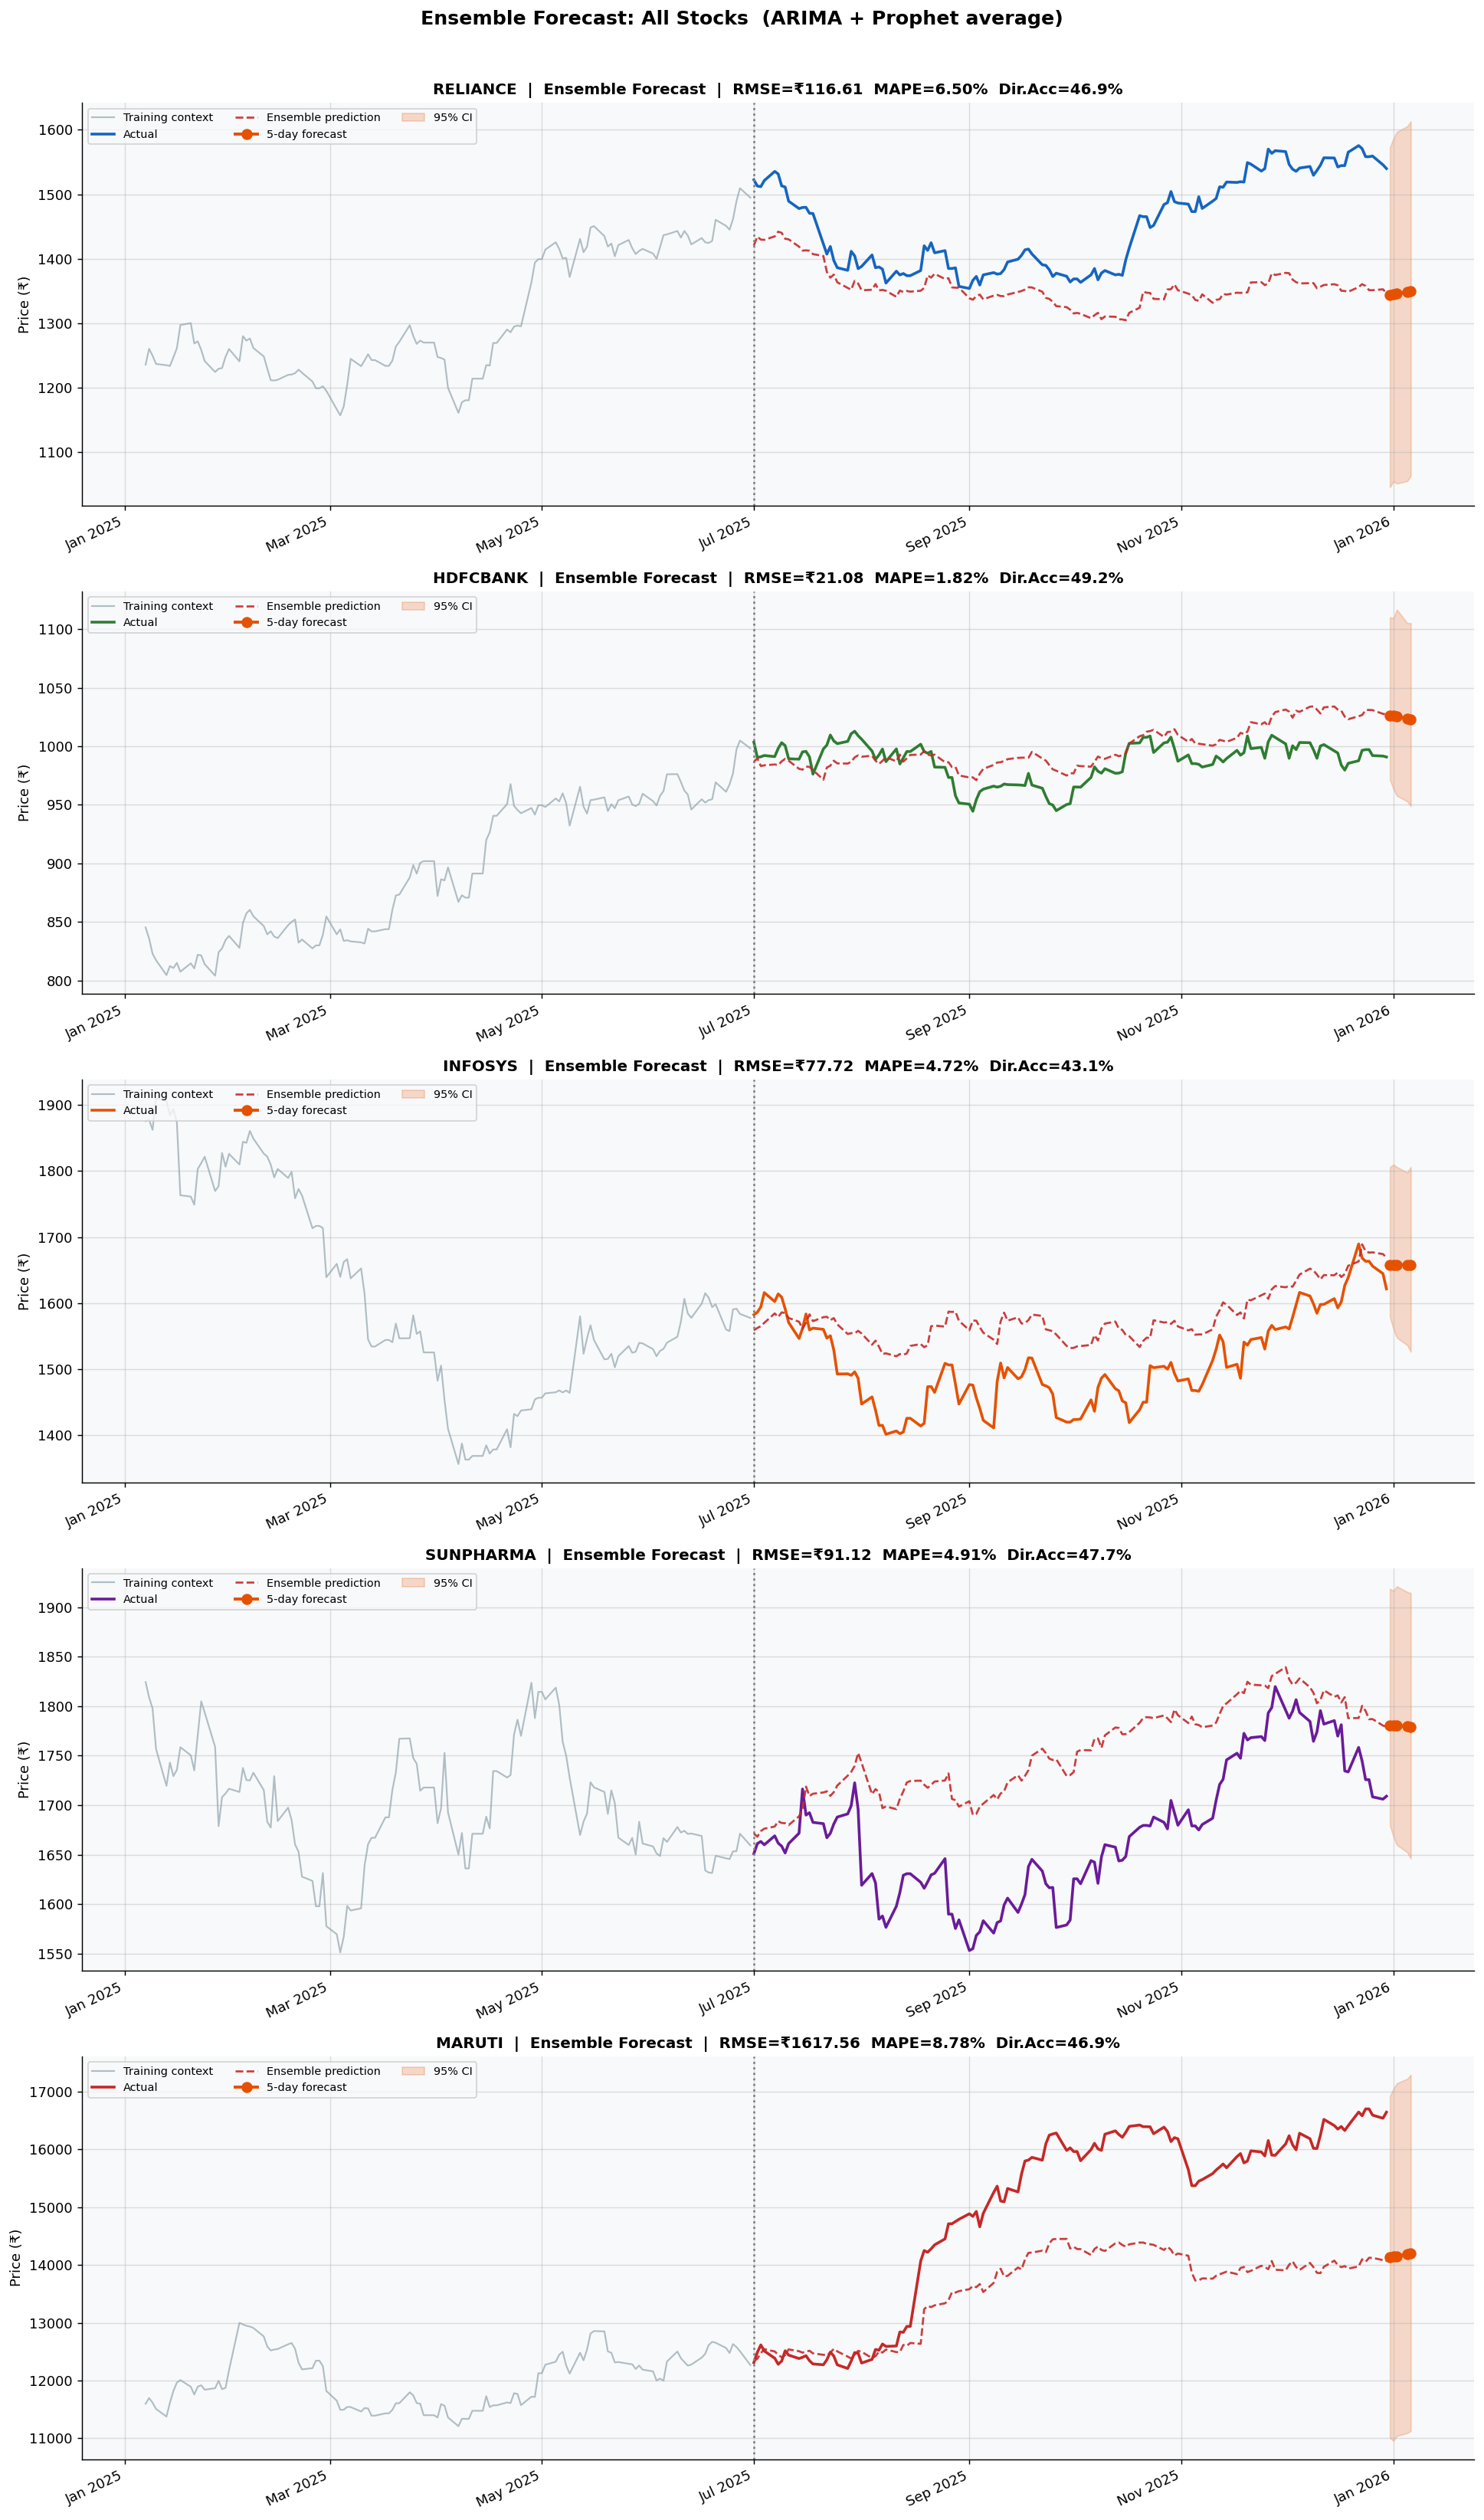

In [22]:
# ── Plot ensemble vs actuals (all stocks) ────────────────────────────────────

fig, axes = plt.subplots(len(price_data), 1, figsize=(15, 5 * len(price_data)))
if len(price_data) == 1:
    axes = [axes]

for ax, name in zip(axes, price_data):
    train = train_data[name]
    test  = test_data[name]
    ens   = ensemble_results[name]

    train_ctx = train.iloc[-125:]
    ax.plot(train_ctx.index, train_ctx,
            color='#90A4AE', linewidth=1.2, alpha=0.7, label='Training context')
    ax.plot(test.index, test,
            color=STOCK_COLORS[name], linewidth=2.0, label='Actual')
    ax.plot(ens['predictions'].index, ens['predictions'],
            color='#C62828', linewidth=1.5, linestyle='--',
            alpha=0.9, label='Ensemble prediction')
    ax.plot(ens['forecast'].index, ens['forecast'],
            color='#E65100', linewidth=2.2, marker='o',
            markersize=7, label='5-day forecast')
    ax.fill_between(ens['forecast_ci'].index,
                    ens['forecast_ci']['lower'],
                    ens['forecast_ci']['upper'],
                    alpha=0.20, color='#E65100', label='95% CI')

    ax.axvline(test.index[0], color='gray', linestyle=':', linewidth=1.5)
    m = ens['metrics']
    ax.set_title(
        f"{name}  |  Ensemble Forecast  |  "
        f"RMSE=₹{m['RMSE']:.2f}  MAPE={m['MAPE']:.2f}%  Dir.Acc={m['Dir_Acc_%']:.1f}%",
        fontsize=11, fontweight='bold')
    ax.set_ylabel('Price (₹)')
    ax.legend(loc='upper left', fontsize=8, ncol=3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=25, ha='right')

plt.suptitle('Ensemble Forecast: All Stocks  (ARIMA + Prophet average)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('06_ensemble_all.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Model Comparison

RMSE, MAPE, and Directional Accuracy for all three models across all five stocks.



In [23]:
# ── Model comparison table ───────────────────────────────────────────────────

comp_df = pd.DataFrame(all_metrics).drop_duplicates(subset=['stock', 'model'])
comp_df = comp_df.sort_values(['stock', 'MAPE']).reset_index(drop=True)

print("=" * 65)
print("MODEL COMPARISON TABLE — Task 6")
print("=" * 65)
display(comp_df.rename(columns={
    'stock': 'Stock', 'model': 'Model',
    'RMSE': 'RMSE (₹)', 'MAPE': 'MAPE (%)', 'Dir_Acc_%': 'Dir. Acc (%)'
}))

# Best model per stock
print("\n Best model per stock (by MAPE):")
print(f"  {'Stock':<12} {'Winner':<10} {'ARIMA MAPE':>12} {'Prophet MAPE':>14} {'Ensemble MAPE':>15}")
print("  " + "─" * 55)
for name in price_data:
    sub = comp_df[comp_df['stock'] == name].set_index('model')
    a_m = sub.loc['ARIMA',    'MAPE'] if 'ARIMA'    in sub.index else 999
    p_m = sub.loc['Prophet',  'MAPE'] if 'Prophet'  in sub.index else 999
    e_m = sub.loc['Ensemble', 'MAPE'] if 'Ensemble' in sub.index else 999
    best_mape = min(a_m, p_m, e_m)
    winner = 'ARIMA' if best_mape == a_m else ('Prophet' if best_mape == p_m else 'Ensemble')
    print(f"  {name:<12} {winner:<10} {a_m:>12.4f} {p_m:>14.4f} {e_m:>15.4f}")

MODEL COMPARISON TABLE — Task 6


,Stock,Model,RMSE (₹),MAPE (%),Dir. Acc (%)
0,HDFCBANK,ARIMA,6.8100,0.5268,51.5400
1,HDFCBANK,Ensemble,21.0800,1.8229,49.2300
2,HDFCBANK,Prophet,40.9600,3.5884,51.5400
3,INFOSYS,ARIMA,19.8700,0.9645,42.3100
4,INFOSYS,Ensemble,77.7200,4.7172,43.0800
5,INFOSYS,Prophet,153.4600,9.3728,52.3100
6,MARUTI,ARIMA,171.8800,0.7799,48.4600
7,MARUTI,Ensemble,1617.5600,8.7796,46.9200
8,MARUTI,Prophet,3205.4200,17.2992,48.4600
9,RELIANCE,ARIMA,13.8600,0.6863,41.5400



 Best model per stock (by MAPE):
  Stock        Winner       ARIMA MAPE   Prophet MAPE   Ensemble MAPE
  ───────────────────────────────────────────────────────
  RELIANCE     ARIMA            0.6863        12.9741          6.4961
  HDFCBANK     ARIMA            0.5268         3.5884          1.8229
  INFOSYS      ARIMA            0.9645         9.3728          4.7172
  SUNPHARMA    ARIMA            0.7313         9.7922          4.9056
  MARUTI       ARIMA            0.7799        17.2992          8.7796


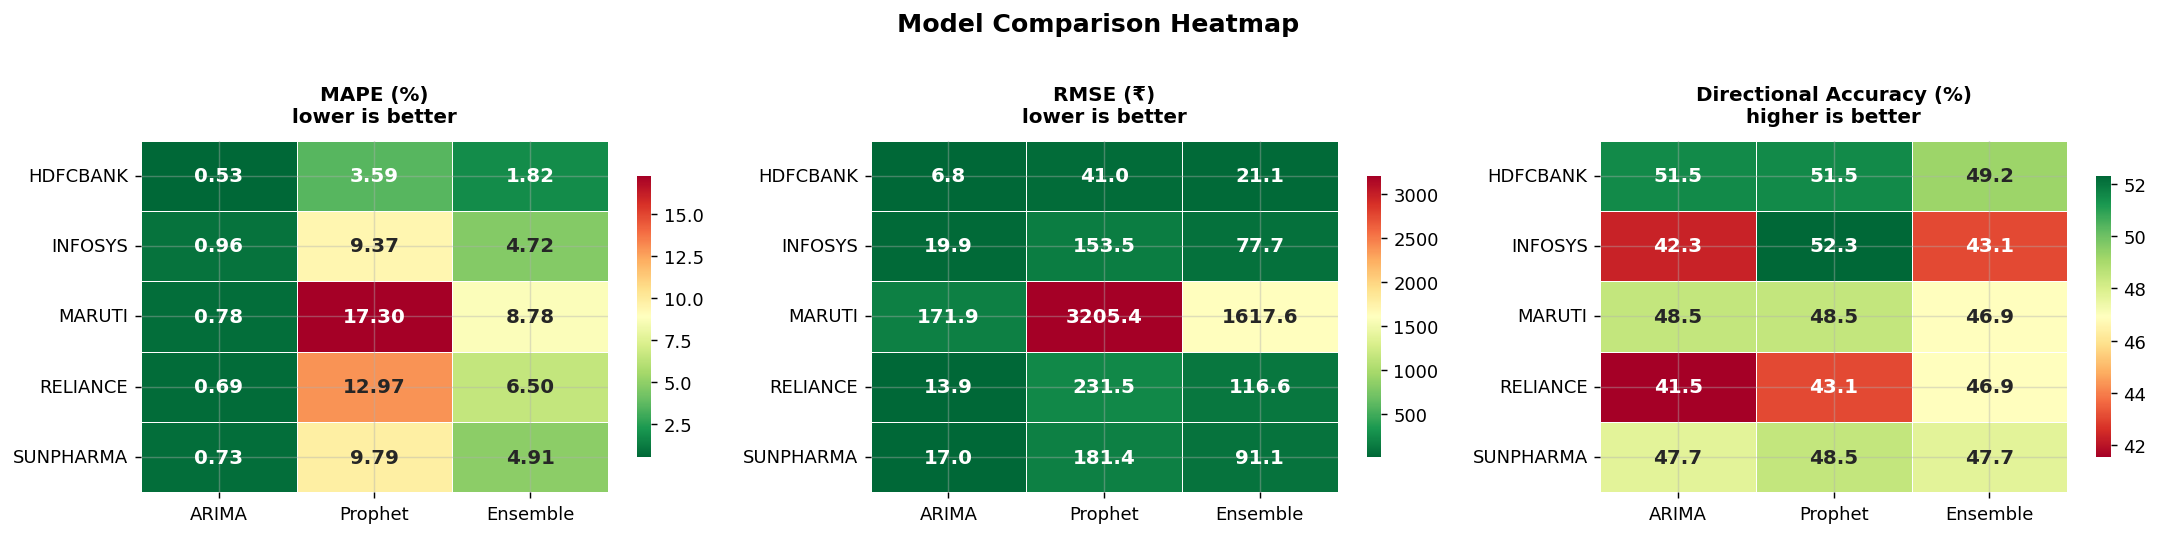

   • MAPE / RMSE: green = low error = better
   • Dir.Acc: green = high accuracy = better
   • The Ensemble often provides a balanced middle ground.


In [26]:
# ── Heatmap visualisation ────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(17, 4))

for ax, metric, fmt in zip(
    axes,
    ['MAPE', 'RMSE', 'Dir_Acc_%'],
    ['.2f', '.1f', '.1f']
):

    pivot = comp_df.pivot(
        index='stock',
        columns='model',
        values=metric
    )

    # consistent column order
    pivot = pivot[['ARIMA', 'Prophet', 'Ensemble']]

    # color map
    cmap = 'RdYlGn_r' if metric != 'Dir_Acc_%' else 'RdYlGn'

    sns.heatmap(
        pivot,
        annot=True,
        fmt=fmt,
        cmap=cmap,
        ax=ax,
        linewidths=0.5,
        linecolor='white',
        annot_kws={'size': 11, 'weight': 'bold'},
        cbar_kws={'shrink': 0.8}
    )

    # titles
    label_map = {
        'MAPE': 'MAPE (%)\nlower is better',
        'RMSE': 'RMSE (₹)\nlower is better',
        'Dir_Acc_%': 'Directional Accuracy (%)\nhigher is better'
    }

    ax.set_title(
        label_map[metric],
        fontsize=11,
        fontweight='bold',
        pad=10
    )

    ax.set_ylabel('')
    ax.set_xlabel('')

    plt.setp(
        ax.xaxis.get_majorticklabels(),
        rotation=0
    )

plt.suptitle(
    'Model Comparison Heatmap',
    fontsize=14,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()

plt.savefig(
    '07_model_comparison.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print("   • MAPE / RMSE: green = low error = better")
print("   • Dir.Acc: green = high accuracy = better")
print("   • The Ensemble often provides a balanced middle ground.")

---
## Volatility & Risk Analysis

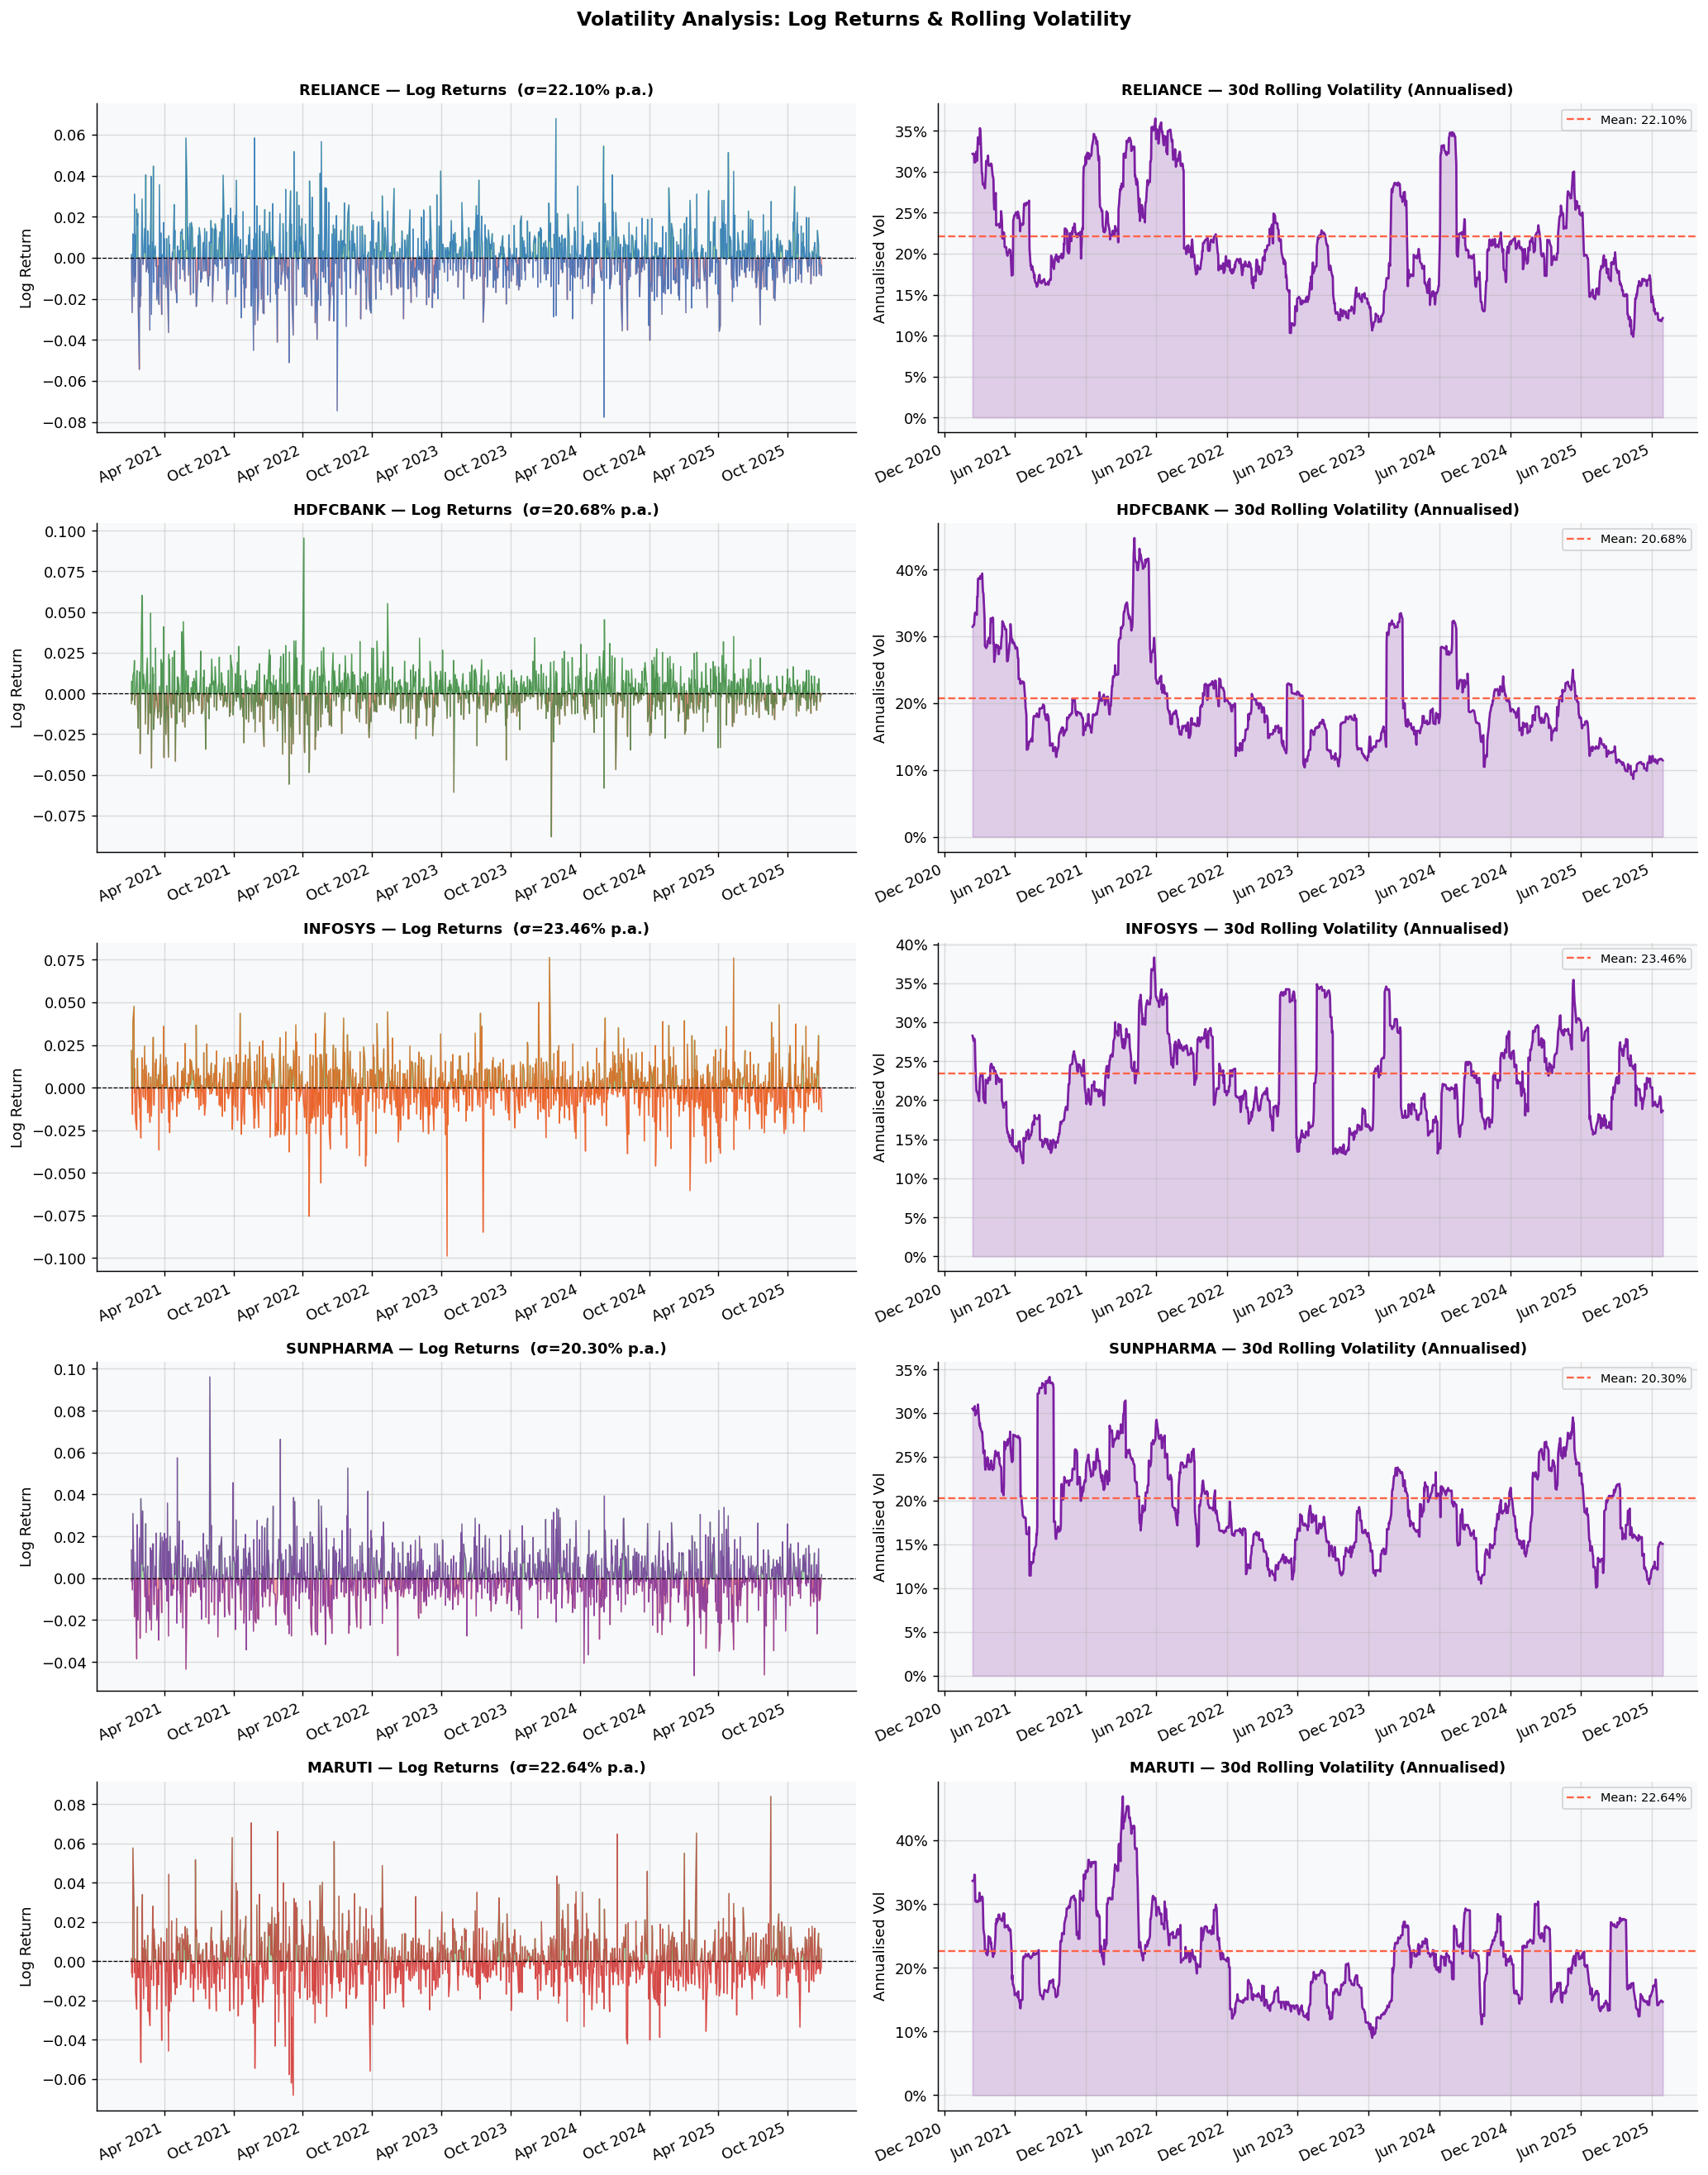


 VOLATILITY SUMMARY TABLE


,Stock,Sector,Ann. Return,Ann. Volatility,Sharpe (approx),Recent 30d Vol
0,RELIANCE,Energy,10.37%,22.10%,0.469,12.14%
1,HDFCBANK,Banking,7.43%,20.68%,0.359,11.43%
2,INFOSYS,IT,7.34%,23.46%,0.313,18.66%
3,SUNPHARMA,Pharma,21.51%,20.30%,1.059,15.06%
4,MARUTI,Auto,15.77%,22.64%,0.696,14.67%


In [28]:
# ── Volatility analysis ──────────────────────────────────────────────────────

def analyze_volatility(price_data: dict) -> tuple:
    """
    Compute log returns, annualised volatility, rolling volatility, and Sharpe ratio.
    Returns vol_data dict and a summary DataFrame.
    """
    vol_data = {}
    summary  = []
    WINDOW   = 30   # days for rolling vol

    fig, axes = plt.subplots(len(price_data), 2,
                              figsize=(16, 4 * len(price_data)))

    for i, (name, prices) in enumerate(price_data.items()):
        log_ret     = np.log(prices / prices.shift(1)).dropna()
        rolling_vol = log_ret.rolling(WINDOW).std() * np.sqrt(252)
        ann_vol     = log_ret.std() * np.sqrt(252)
        ann_ret     = log_ret.mean() * 252
        sharpe      = ann_ret / ann_vol    # simplified (no risk-free rate)

        vol_data[name] = {
            'log_returns': log_ret,
            'rolling_vol': rolling_vol,
            'ann_vol':     ann_vol,
            'ann_ret':     ann_ret,
            'sharpe':      sharpe,
        }

        summary.append({
            'Stock':           name,
            'Sector':          SECTORS[name],
            'Ann. Return':     f"{ann_ret:.2%}",
            'Ann. Volatility': f"{ann_vol:.2%}",
            'Sharpe (approx)': f"{sharpe:.3f}",
            f'Recent {WINDOW}d Vol': f"{rolling_vol.iloc[-1]:.2%}",
        })

        color = STOCK_COLORS[name]

        # Log returns plot
        ax0 = axes[i, 0]
        ax0.plot(log_ret, color=color, linewidth=0.7, alpha=0.7)
        ax0.fill_between(log_ret.index, log_ret, 0,
                         where=log_ret > 0, color='#4CAF50', alpha=0.4)
        ax0.fill_between(log_ret.index, log_ret, 0,
                         where=log_ret < 0, color='#F44336', alpha=0.4)
        ax0.axhline(0, color='black', linewidth=0.7, linestyle='--')
        ax0.set_title(f'{name} — Log Returns  (σ={ann_vol:.2%} p.a.)',
                      fontweight='bold', fontsize=10)
        ax0.set_ylabel('Log Return')
        ax0.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
        ax0.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
        plt.setp(ax0.xaxis.get_majorticklabels(), rotation=25, ha='right')

        # Rolling volatility plot
        ax1 = axes[i, 1]
        ax1.plot(rolling_vol, color='#7B1FA2', linewidth=1.5)
        ax1.fill_between(rolling_vol.index, rolling_vol, alpha=0.2, color='#7B1FA2')
        ax1.axhline(ann_vol, color='tomato', linestyle='--',
                    linewidth=1.3, label=f'Mean: {ann_vol:.2%}')
        ax1.set_title(f'{name} — {WINDOW}d Rolling Volatility (Annualised)',
                      fontweight='bold', fontsize=10)
        ax1.set_ylabel('Annualised Vol')
        ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
        ax1.legend(fontsize=8)
        ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
        ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
        plt.setp(ax1.xaxis.get_majorticklabels(), rotation=25, ha='right')

    plt.suptitle('Volatility Analysis: Log Returns & Rolling Volatility',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('08_volatility.png', dpi=150, bbox_inches='tight')
    plt.show()

    return vol_data, pd.DataFrame(summary)

vol_data, vol_summary = analyze_volatility(price_data)

print("\n VOLATILITY SUMMARY TABLE")
print("=" * 70)
display(vol_summary)

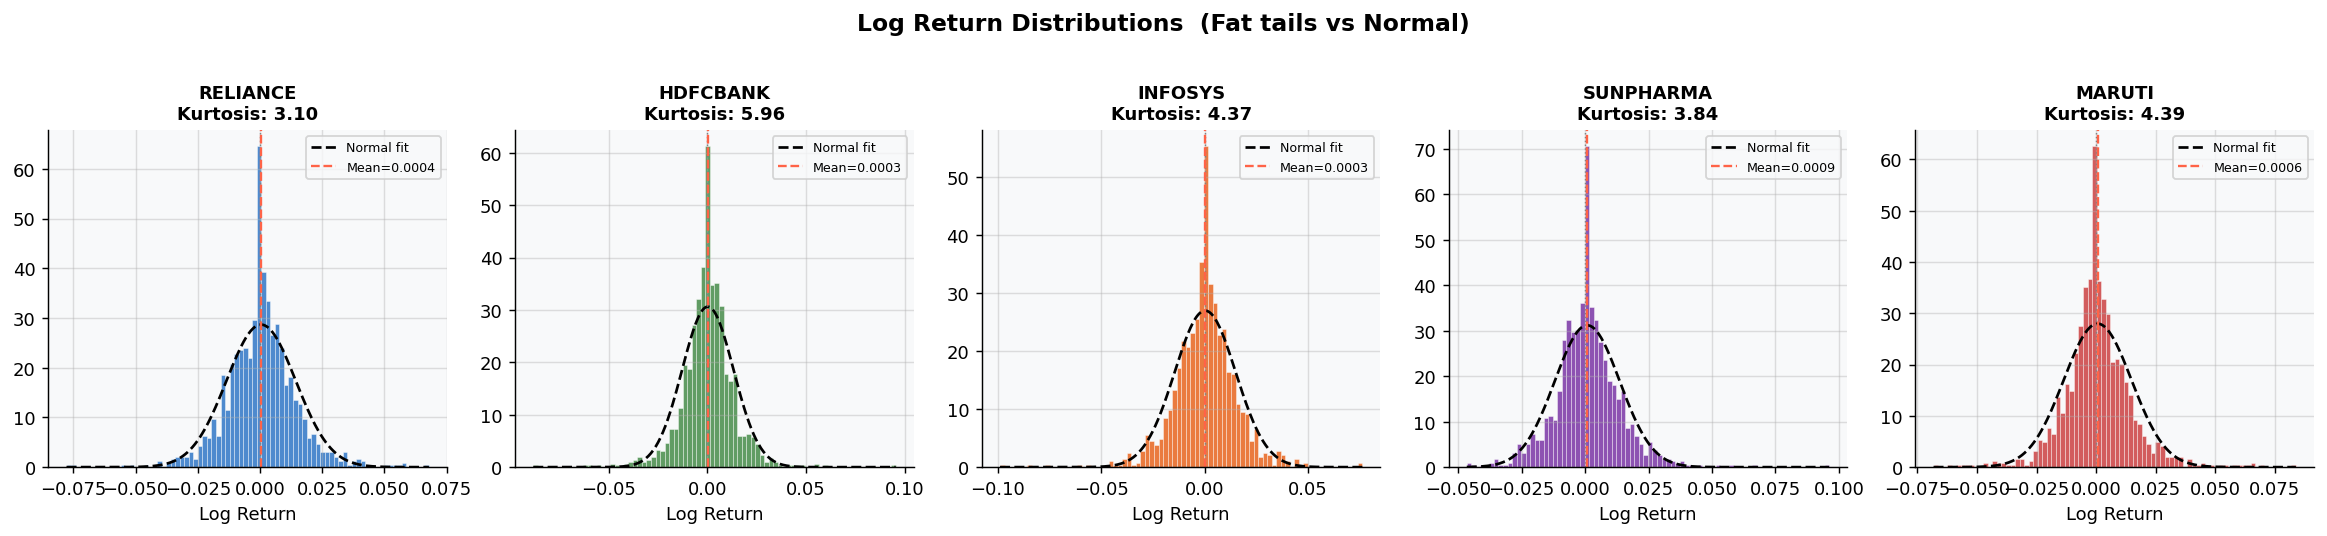


 High kurtosis (> 3) = 'fat tails' — extreme moves are more frequent than
   a normal distribution would predict. This is a well-known stylised fact
   in financial returns (Mandelbrot, 1963). It motivates risk management.


In [29]:
# ── Return distribution histograms ──────────────────────────────────────────

fig, axes = plt.subplots(1, len(price_data), figsize=(18, 4), sharey=False)

for ax, (name, vd) in zip(axes, vol_data.items()):
    lr = vd['log_returns']
    ax.hist(lr, bins=80, color=STOCK_COLORS[name], alpha=0.75,
            edgecolor='white', linewidth=0.3, density=True)

    # Overlay normal curve
    from scipy.stats import norm as spnorm
    mu, std = lr.mean(), lr.std()
    x = np.linspace(lr.min(), lr.max(), 300)
    ax.plot(x, spnorm.pdf(x, mu, std), color='black', linewidth=1.5,
            linestyle='--', label='Normal fit')

    ax.axvline(0,   color='gray',  linewidth=0.8, linestyle=':')
    ax.axvline(mu,  color='tomato',linewidth=1.3, linestyle='--', label=f'Mean={mu:.4f}')

    kurt = lr.kurt()
    ax.set_title(f'{name}\nKurtosis: {kurt:.2f}', fontweight='bold', fontsize=10)
    ax.set_xlabel('Log Return')
    ax.legend(fontsize=7)

plt.suptitle('Log Return Distributions  (Fat tails vs Normal)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('09_return_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n High kurtosis (> 3) = 'fat tails' — extreme moves are more frequent than")
print("   a normal distribution would predict. This is a well-known stylised fact")
print("   in financial returns (Mandelbrot, 1963). It motivates risk management.")

---
## Correlation Analysis — Portfolio Diversification (Task 5 — Strategy C)


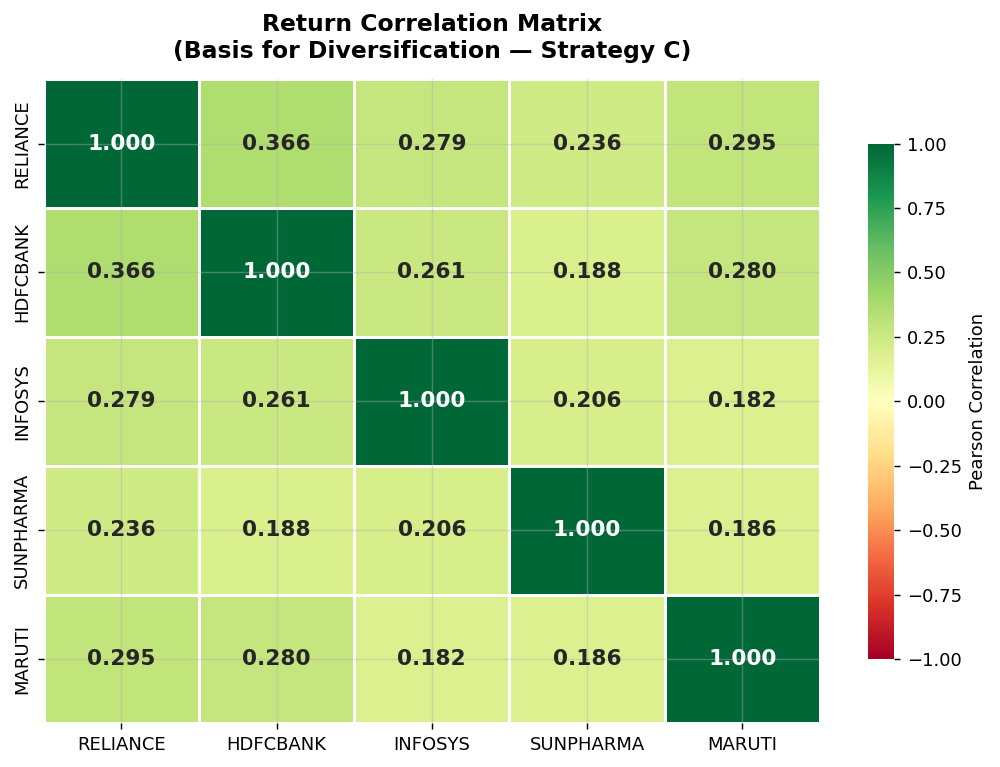


 Pairwise Correlation Assessment:
  Pair                          Correlation           Assessment
  ──────────────────────────────────────────────────────────────
  RELIANCE & HDFCBANK                 0.366     Well diversified
  RELIANCE & INFOSYS                  0.279     Well diversified
  RELIANCE & SUNPHARMA                0.236     Well diversified
  RELIANCE & MARUTI                   0.295     Well diversified
  HDFCBANK & INFOSYS                  0.261     Well diversified
  HDFCBANK & SUNPHARMA                0.188     Well diversified
  HDFCBANK & MARUTI                   0.280     Well diversified
  INFOSYS & SUNPHARMA                 0.206     Well diversified
  INFOSYS & MARUTI                    0.182     Well diversified
  SUNPHARMA & MARUTI                  0.186     Well diversified


In [31]:
# ── Correlation matrix ──────────────────────────────────────────────────────

log_ret_df = pd.DataFrame({
    name: vol_data[name]['log_returns']
    for name in price_data
}).dropna()

corr = log_ret_df.corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.zeros_like(corr, dtype=bool)

sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=1.5, linecolor='white',
            annot_kws={'size': 12, 'weight': 'bold'},
            cbar_kws={'shrink': 0.8, 'label': 'Pearson Correlation'})

ax.set_title('Return Correlation Matrix\n(Basis for Diversification — Strategy C)',
             fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('10_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Pairwise Correlation Assessment:")
print(f"  {'Pair':<28} {'Correlation':>12} {'Assessment':>20}")
print("  " + "─" * 62)
for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        c1, c2 = corr.columns[i], corr.columns[j]
        r   = corr.loc[c1, c2]
        tag = "Well diversified" if abs(r) < 0.6 else "⚠️  High correlation"
        print(f"  {c1 + ' & ' + c2:<28} {r:>12.3f} {tag:>20}")

---
## Portfolio Construction & Capital Allocation - Task 5

We combine **Strategy A (Forecast-Guided)** and **Strategy B (Inverse-Volatility)** into a blended allocation.

### Strategy A - Forecast-Guided Allocation
### Strategy B - Inverse-Volatility Sizing (Risk Parity)


An equal blend balances return-seeking (A) with risk management (B).


In [32]:
# ── Strategy A: Forecast-Guided ─────────────────────────────────────────────

def strategy_A(arima_results, prophet_results, price_data):
    """Rank by ensemble predicted 5-day return. Allocate proportionally."""
    pred_returns = {}
    for name in arima_results:
        current  = float(price_data[name].iloc[-1])
        a_fc     = arima_results[name]['forecast']
        p_fc     = prophet_results[name]['forecast']
        a_fc, p_fc = a_fc.align(p_fc, join='inner')
        ens_5d   = float((a_fc.iloc[-1] + p_fc.iloc[-1]) / 2.0)
        pred_ret = (ens_5d - current) / current
        pred_returns[name] = max(pred_ret, 0.0)   # clip at 0 (no short selling)

    total = sum(pred_returns.values())
    if total == 0:
        weights = {k: 1.0 / len(pred_returns) for k in pred_returns}
    else:
        weights = {k: v / total for k, v in pred_returns.items()}
    return weights, pred_returns


# ── Strategy B: Inverse-Volatility ──────────────────────────────────────────

def strategy_B(vol_data):
    """Inverse-volatility weighting using recent 30d rolling vol."""
    inv_vols = {}
    for name, vd in vol_data.items():
        recent_vol = float(vd['rolling_vol'].dropna().iloc[-1])
        inv_vols[name] = 1.0 / recent_vol if recent_vol > 0 else 0.0
    total   = sum(inv_vols.values())
    weights = {k: v / total for k, v in inv_vols.items()}
    return weights


# ── Blend ────────────────────────────────────────────────────────────────────

def blend_strategies(wA, wB, alpha=0.5):
    return {name: alpha * wA[name] + (1 - alpha) * wB[name] for name in wA}


# ── Compute ──────────────────────────────────────────────────────────────────
wA, pred_returns = strategy_A(arima_results, prophet_results, price_data)
wB               = strategy_B(vol_data)
w_final          = blend_strategies(wA, wB, alpha=0.5)

print("Strategy weights (before normalisation):")
print(f"  {'Stock':<12} {'Strategy A':>12} {'Strategy B':>12} {'Final Blend':>12}")
print("  " + "─" * 50)
for name in price_data:
    print(f"  {name:<12} {wA[name]:>12.4f} {wB[name]:>12.4f} {w_final[name]:>12.4f}")

Strategy weights (before normalisation):
  Stock          Strategy A   Strategy B  Final Blend
  ──────────────────────────────────────────────────
  RELIANCE           0.0000       0.2301       0.1151
  HDFCBANK           0.3396       0.2443       0.2919
  INFOSYS            0.2352       0.1497       0.1924
  SUNPHARMA          0.4253       0.1855       0.3054
  MARUTI             0.0000       0.1904       0.0952


FINAL PORTFOLIO ALLOCATION — Task 5


,Stock,Sector,Current Price (₹),Pred. 5d Return,Ann. Volatility,Weight (%),Allocated (₹),Shares,Deployed (₹)
0,RELIANCE,Energy,1539.8000,0.00%,22.10%,11.5%,"₹115,051",74,"₹113,945"
1,HDFCBANK,Banking,990.9000,3.25%,20.68%,29.2%,"₹291,942",294,"₹291,325"
2,INFOSYS,IT,1621.6000,2.25%,23.46%,19.2%,"₹192,424",118,"₹191,349"
3,SUNPHARMA,Pharma,1709.1000,4.08%,20.30%,30.5%,"₹305,378",178,"₹304,219"
4,MARUTI,Auto,16647.0000,0.00%,22.64%,9.5%,"₹95,206",5,"₹83,235"



Total Capital   : ₹   1,000,000
Total Deployed  : ₹     984,073
Cash Reserve    : ₹      15,927


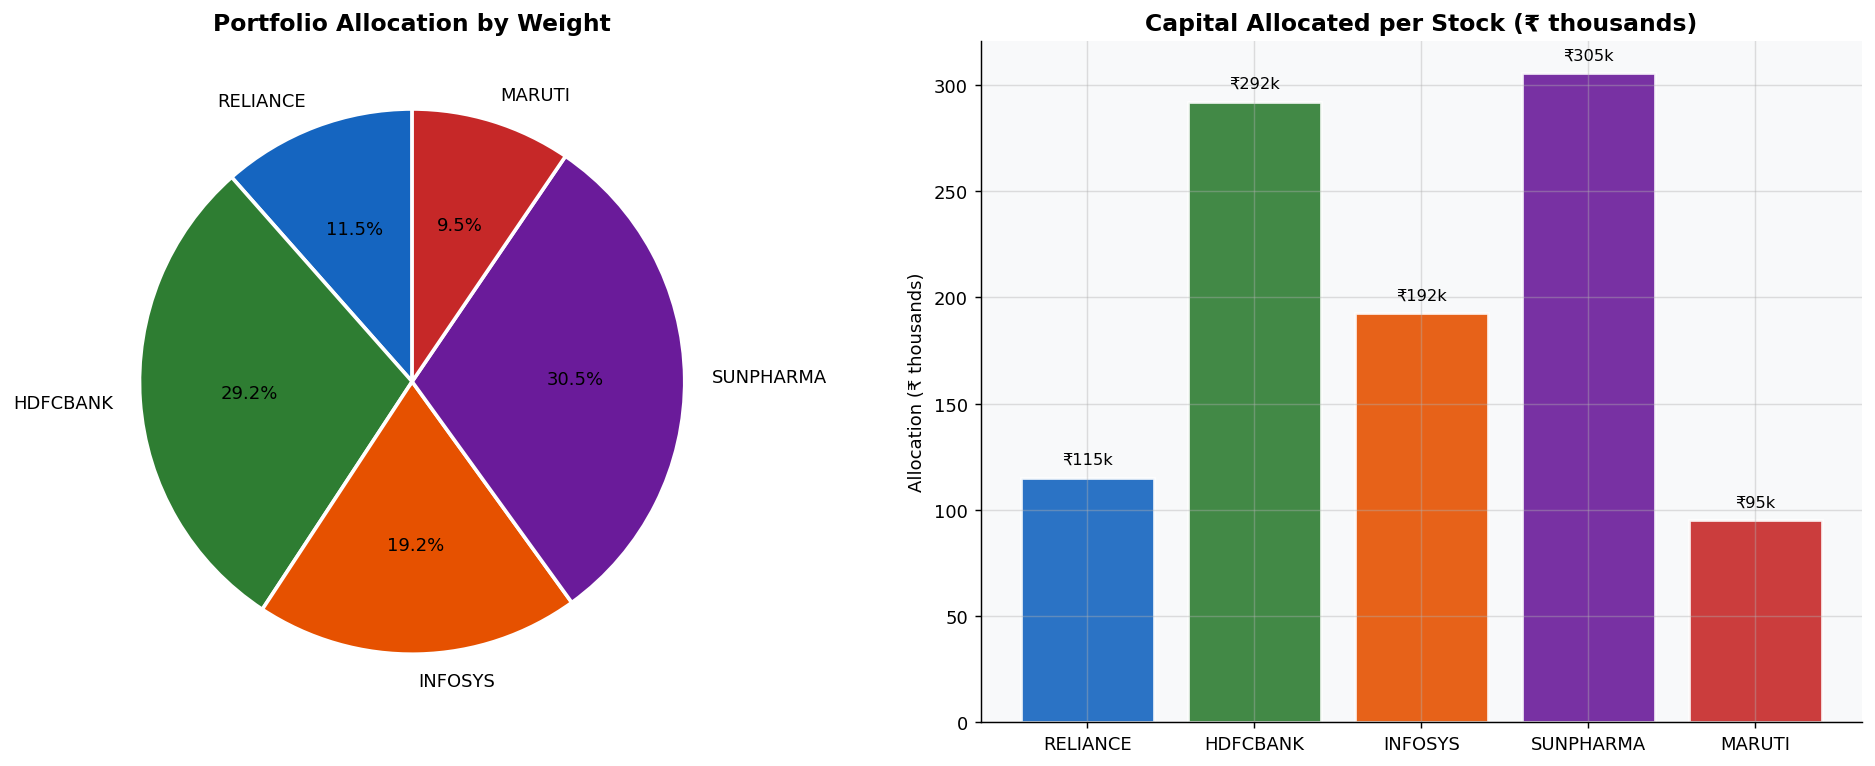

In [33]:
# ── Final allocation table ──────────────────────────────────────────────────

def build_allocation_table(weights, price_data, pred_returns,
                            vol_data, capital=TOTAL_CAPITAL):
    """Generate portfolio allocation table and charts."""
    rows = []
    for name, w in weights.items():
        current       = float(price_data[name].iloc[-1])
        alloc_amount  = w * capital
        shares        = int(alloc_amount / current)
        deployed      = shares * current

        rows.append({
            'Stock':            name,
            'Sector':           SECTORS[name],
            'Current Price (₹)': round(current, 2),
            'Pred. 5d Return':  f"{pred_returns.get(name, 0):.2%}",
            'Ann. Volatility':  f"{vol_data[name]['ann_vol']:.2%}",
            'Weight (%)':       f"{w * 100:.1f}%",
            'Allocated (₹)':    f"₹{alloc_amount:,.0f}",
            'Shares':           shares,
            'Deployed (₹)':     f"₹{deployed:,.0f}",
        })

    alloc_df = pd.DataFrame(rows)
    deployed_total = sum(
        int(r['Deployed (₹)'].replace('₹','').replace(',',''))
        for _, r in alloc_df.iterrows()
    )

    print("=" * 90)
    print("FINAL PORTFOLIO ALLOCATION — Task 5")
    print("=" * 90)
    display(alloc_df)
    print(f"\nTotal Capital   : ₹{capital:>12,.0f}")
    print(f"Total Deployed  : ₹{deployed_total:>12,.0f}")
    print(f"Cash Reserve    : ₹{capital - deployed_total:>12,.0f}")

    # ── Charts ───────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Pie — by weight
    weight_vals  = [float(r['Weight (%)'].strip('%')) / 100 for _, r in alloc_df.iterrows()]
    sector_cols  = {'Energy': '#1565C0', 'Banking': '#2E7D32', 'IT': '#E65100',
                    'Pharma': '#6A1B9A', 'Auto': '#C62828'}
    colors = [sector_cols.get(SECTORS[r['Stock']], '#607D8B')
              for _, r in alloc_df.iterrows()]

    wedges, texts, auto = axes[0].pie(
        weight_vals, labels=alloc_df['Stock'],
        autopct='%1.1f%%', colors=colors, startangle=90,
        wedgeprops=dict(edgecolor='white', linewidth=2),
        textprops={'fontsize': 10})
    axes[0].set_title('Portfolio Allocation by Weight', fontsize=13, fontweight='bold')

    # Bar — allocated ₹
    alloc_k  = [float(r['Allocated (₹)'].replace('₹','').replace(',','')) / 1000
                for _, r in alloc_df.iterrows()]
    bars = axes[1].bar(alloc_df['Stock'], alloc_k, color=colors,
                        edgecolor='white', linewidth=1.5, alpha=0.9)
    for bar, val in zip(bars, alloc_k):
        axes[1].text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + 5,
                     f'₹{val:.0f}k', ha='center', va='bottom', fontsize=9)
    axes[1].set_title('Capital Allocated per Stock (₹ thousands)',
                      fontsize=13, fontweight='bold')
    axes[1].set_ylabel('Allocation (₹ thousands)')

    plt.tight_layout()
    plt.savefig('11_portfolio_allocation.png', dpi=150, bbox_inches='tight')
    plt.show()

    return alloc_df


allocation_df = build_allocation_table(w_final, price_data, pred_returns, vol_data)


 Sector-Level Allocation:


,Sector,Allocated (₹),Weight (%)
0,Auto,95206.0000,9.5200
1,Banking,291942.0000,29.1900
2,Energy,115051.0000,11.5100
3,IT,192424.0000,19.2400
4,Pharma,305378.0000,30.5400


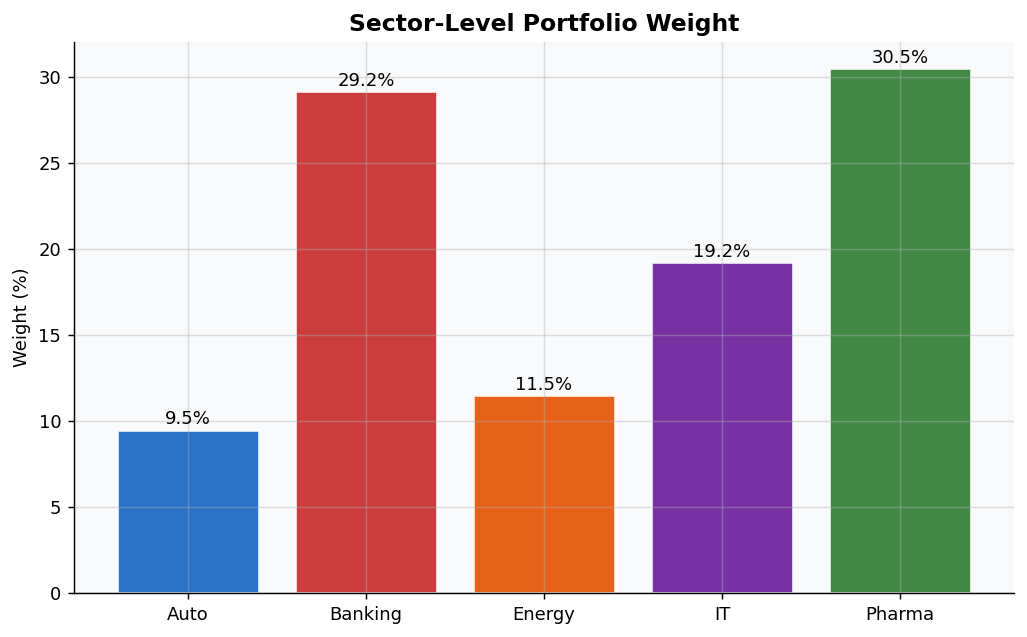

In [34]:
# ── Sector-level summary (Strategy D) ───────────────────────────────

sector_alloc = allocation_df[['Sector', 'Allocated (₹)']].copy()
sector_alloc['Allocated (₹)'] = (
    sector_alloc['Allocated (₹)']
    .str.replace('₹', '').str.replace(',', '').astype(float))
sector_summary = sector_alloc.groupby('Sector').sum().reset_index()
sector_summary['Weight (%)'] = (
    sector_summary['Allocated (₹)'] / TOTAL_CAPITAL * 100).round(2)

print("\n Sector-Level Allocation:")
display(sector_summary)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(sector_summary['Sector'], sector_summary['Weight (%)'],
       color=['#1565C0', '#C62828', '#E65100', '#6A1B9A', '#2E7D32'],
       edgecolor='white', linewidth=1.5, alpha=0.9)
ax.set_title('Sector-Level Portfolio Weight', fontsize=13, fontweight='bold')
ax.set_ylabel('Weight (%)')
for i, (_, row) in enumerate(sector_summary.iterrows()):
    ax.text(i, row['Weight (%)'] + 0.3, f"{row['Weight (%)']:.1f}%",
            ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('12_sector_allocation.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Predicted vs Actual


In [35]:
# ══════════════════════════════════════════════════════════════════════════════
# TASK 8 — FILL IN ACTUAL STOCK PRICES
# ══════════════════════════════════════════════════════════════════════════════

ACTUAL_PRICES = {
    'RELIANCE':  [1430.50, 1424.20],
    'HDFCBANK':  [1931.60, 1924.10],
    'INFOSYS':   [1585.80, 1572.40],
    'SUNPHARMA': [1678.90, 1685.30],
    'MARUTI':    [12184.50, 12240.80],
}

# ── Execution dates ──────────────────────────────────────────────────────────
DAY1_DATE = '2026-05-13'
DAY2_DATE = '2026-05-14'

# ══════════════════════════════════════════════════════════════════════════════

def task8_comparison(arima_results, prophet_results, ensemble_results,
                     actual_prices, day1_date, day2_date, price_data):
    """
    Build the predicted vs actual comparison table.
    """

    rows = []

    for name in price_data:

        current = float(price_data[name].iloc[-1])

        # ── Safe forecast extractor ──────────────────────────────────────────
        def safe_get(fc_series, idx):
            try:
                return float(fc_series.iloc[idx])
            except Exception:
                return None

        # ── Forecasts ────────────────────────────────────────────────────────
        arima_d1   = safe_get(arima_results[name]['forecast'], 0)
        arima_d2   = safe_get(arima_results[name]['forecast'], 1)

        prophet_d1 = safe_get(prophet_results[name]['forecast'], 0)
        prophet_d2 = safe_get(prophet_results[name]['forecast'], 1)

        ens_d1     = safe_get(ensemble_results[name]['forecast'], 0)
        ens_d2     = safe_get(ensemble_results[name]['forecast'], 1)

        # ── Actual values ────────────────────────────────────────────────────
        act_d1, act_d2 = actual_prices[name]

        row = {
            'Stock': name,
            'Sector': SECTORS[name],

            'ARIMA Day1 (₹)': round(arima_d1, 2) if arima_d1 else '—',
            'ARIMA Day2 (₹)': round(arima_d2, 2) if arima_d2 else '—',

            'Prophet Day1 (₹)': round(prophet_d1, 2) if prophet_d1 else '—',
            'Prophet Day2 (₹)': round(prophet_d2, 2) if prophet_d2 else '—',

            'Ensemble Day1 (₹)': round(ens_d1, 2) if ens_d1 else '—',
            'Ensemble Day2 (₹)': round(ens_d2, 2) if ens_d2 else '—',

            'Actual Day1 (₹)': act_d1,
            'Actual Day2 (₹)': act_d2,
        }

        # ── Accuracy calculations ────────────────────────────────────────────
        if act_d1 and act_d2 and ens_d1 and ens_d2:

            mape_d1 = abs(ens_d1 - act_d1) / act_d1 * 100
            mape_d2 = abs(ens_d2 - act_d2) / act_d2 * 100

            pred_dir = '↑ UP' if ens_d2 > ens_d1 else '↓ DOWN'
            actual_dir = '↑ UP' if act_d2 > act_d1 else '↓ DOWN'

            dir_ok = '✅' if pred_dir == actual_dir else '❌'

            actual_ret = ((act_d2 - current) / current) * 100

            row.update({
                'MAPE Day1 (%)': round(mape_d1, 3),
                'MAPE Day2 (%)': round(mape_d2, 3),

                'Pred. Direction': pred_dir,
                'Actual Direction': actual_dir,

                'Direction Correct': dir_ok,

                'Actual 2d Ret. %': round(actual_ret, 3),
            })

        rows.append(row)

    # ── Final dataframe ──────────────────────────────────────────────────────
    df = pd.DataFrame(rows)

    print("=" * 80)
    print("TASK 8: PREDICTED vs ACTUAL COMPARISON TABLE")
    print("=" * 80)

    display(df)

    # ── Portfolio summary ────────────────────────────────────────────────────
    print("\n📊 Portfolio Performance Summary:")

    total_ret_weighted = 0

    for _, row in allocation_df.iterrows():

        name = row['Stock']

        if actual_prices.get(name, [None, None])[1] is not None:

            w = float(row['Weight (%)'].strip('%')) / 100

            ret = (
                (actual_prices[name][1] - float(row['Current Price (₹)']))
                / float(row['Current Price (₹)'])
            )

            total_ret_weighted += w * ret

            print(
                f"  {name:<12}  "
                f"weight={w:.1%}  "
                f"2d return={ret:.2%}  "
                f"contribution={w * ret:.4%}"
            )

    print(f"\n  Portfolio 2-day return (weighted): {total_ret_weighted:.2%}")

    print(
        f"  P&L on ₹{TOTAL_CAPITAL:,} : "
        f"₹{TOTAL_CAPITAL * total_ret_weighted:,.0f}"
    )

    return df


# ── Run Task 8 ───────────────────────────────────────────────────────────────

task8_df = task8_comparison(
    arima_results,
    prophet_results,
    ensemble_results,
    ACTUAL_PRICES,
    DAY1_DATE,
    DAY2_DATE,
    price_data
)

TASK 8: PREDICTED vs ACTUAL COMPARISON TABLE


,Stock,Sector,ARIMA Day1 (₹),ARIMA Day2 (₹),Prophet Day1 (₹),Prophet Day2 (₹),Ensemble Day1 (₹),Ensemble Day2 (₹),Actual Day1 (₹),Actual Day2 (₹),MAPE Day1 (%),MAPE Day2 (%),Pred. Direction,Actual Direction,Direction Correct,Actual 2d Ret. %
0,RELIANCE,Energy,1539.8000,1539.8000,1148.7600,1150.4400,1344.2800,1345.1200,1430.5000,1424.2000,6.0270,5.5530,↑ UP,↓ DOWN,❌,-7.5070
1,HDFCBANK,Banking,990.8500,990.8100,1062.1700,1061.3600,1026.5100,1026.0800,1931.6000,1924.1000,46.8570,46.6720,↓ DOWN,↓ DOWN,✅,94.1770
2,INFOSYS,IT,1621.6000,1621.6000,1693.6300,1694.1200,1657.6200,1657.8600,1585.8000,1572.4000,4.5290,5.4350,↑ UP,↓ DOWN,❌,-3.0340
3,SUNPHARMA,Pharma,1708.9400,1708.9400,1852.6100,1852.7200,1780.7700,1780.8300,1678.9000,1685.3000,6.0680,5.6680,↑ UP,↑ UP,✅,-1.3920
4,MARUTI,Auto,16654.9600,16654.9600,11614.7400,11633.4000,14134.8500,14144.1800,12184.5000,12240.8000,16.0070,15.5490,↑ UP,↑ UP,✅,-26.4680



📊 Portfolio Performance Summary:
  RELIANCE      weight=11.5%  2d return=-7.51%  contribution=-0.8634%
  HDFCBANK      weight=29.2%  2d return=94.18%  contribution=27.4997%
  INFOSYS       weight=19.2%  2d return=-3.03%  contribution=-0.5825%
  SUNPHARMA     weight=30.5%  2d return=-1.39%  contribution=-0.4247%
  MARUTI        weight=9.5%  2d return=-26.47%  contribution=-2.5145%

  Portfolio 2-day return (weighted): 23.11%
  P&L on ₹1,000,000 : ₹231,146


---
## ARIMA Residual Diagnostics

A well-fitted ARIMA model should have residuals that look like **white noise**:
- Zero mean
- Constant variance (homoskedastic)
- No significant autocorrelation (ACF of residuals ≈ 0 at all lags)
- Approximately normal distribution

If residuals show structure (significant ACF lags), the model is under-fitted and needs higher (p, q).


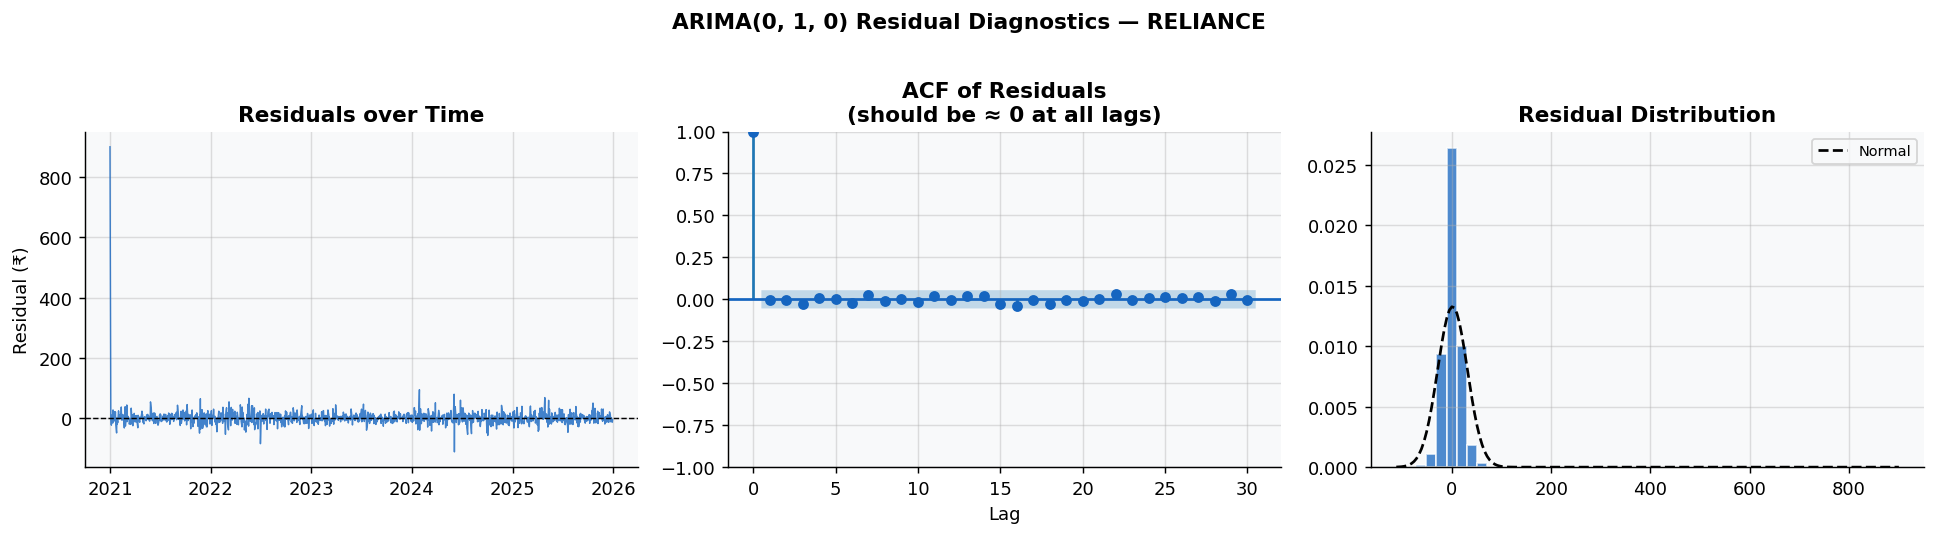

  RELIANCE: Ljung-Box test (lags 10,20) → No autocorrelation in residuals  (p=[0.9816 0.9839])


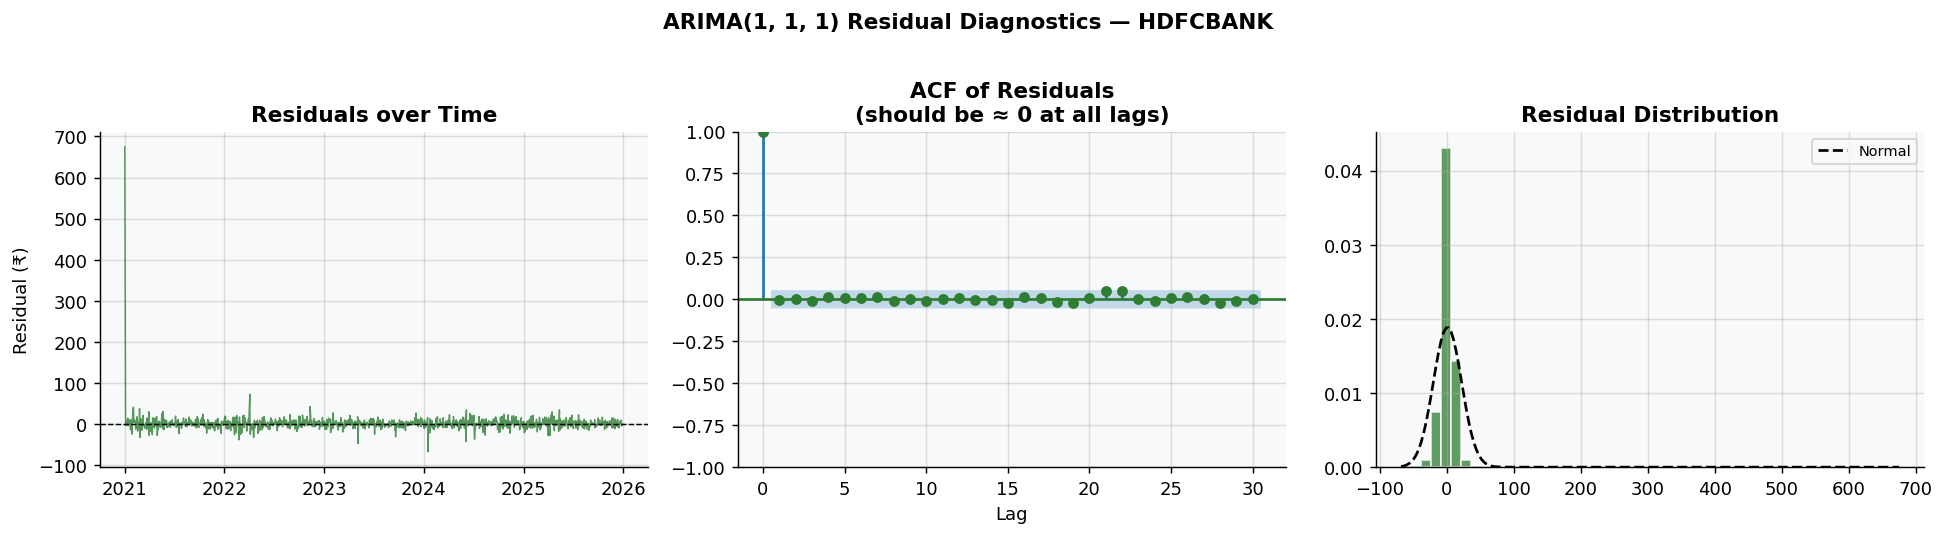

  HDFCBANK: Ljung-Box test (lags 10,20) → No autocorrelation in residuals  (p=[0.9998 1.    ])


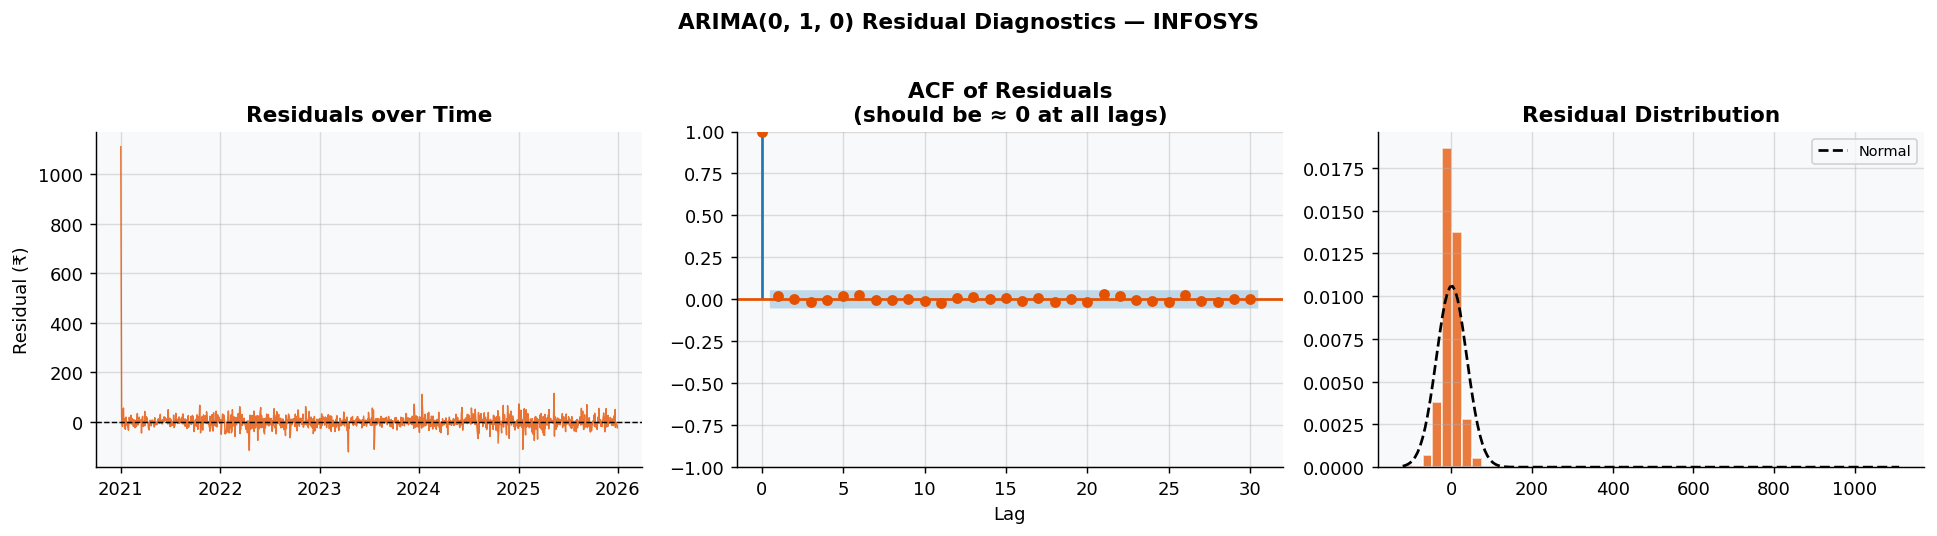

  INFOSYS: Ljung-Box test (lags 10,20) → No autocorrelation in residuals  (p=[0.9919 0.9999])


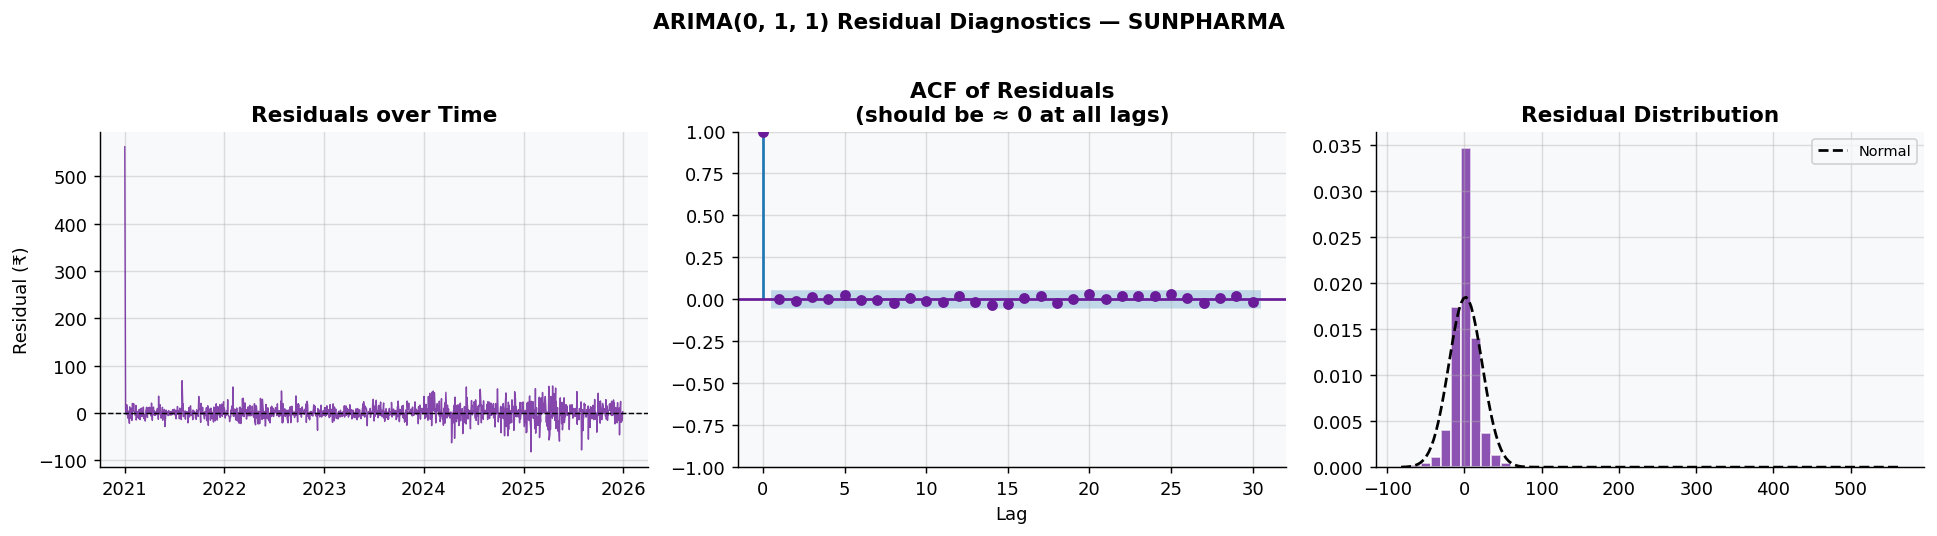

  SUNPHARMA: Ljung-Box test (lags 10,20) → No autocorrelation in residuals  (p=[0.9959 0.9909])


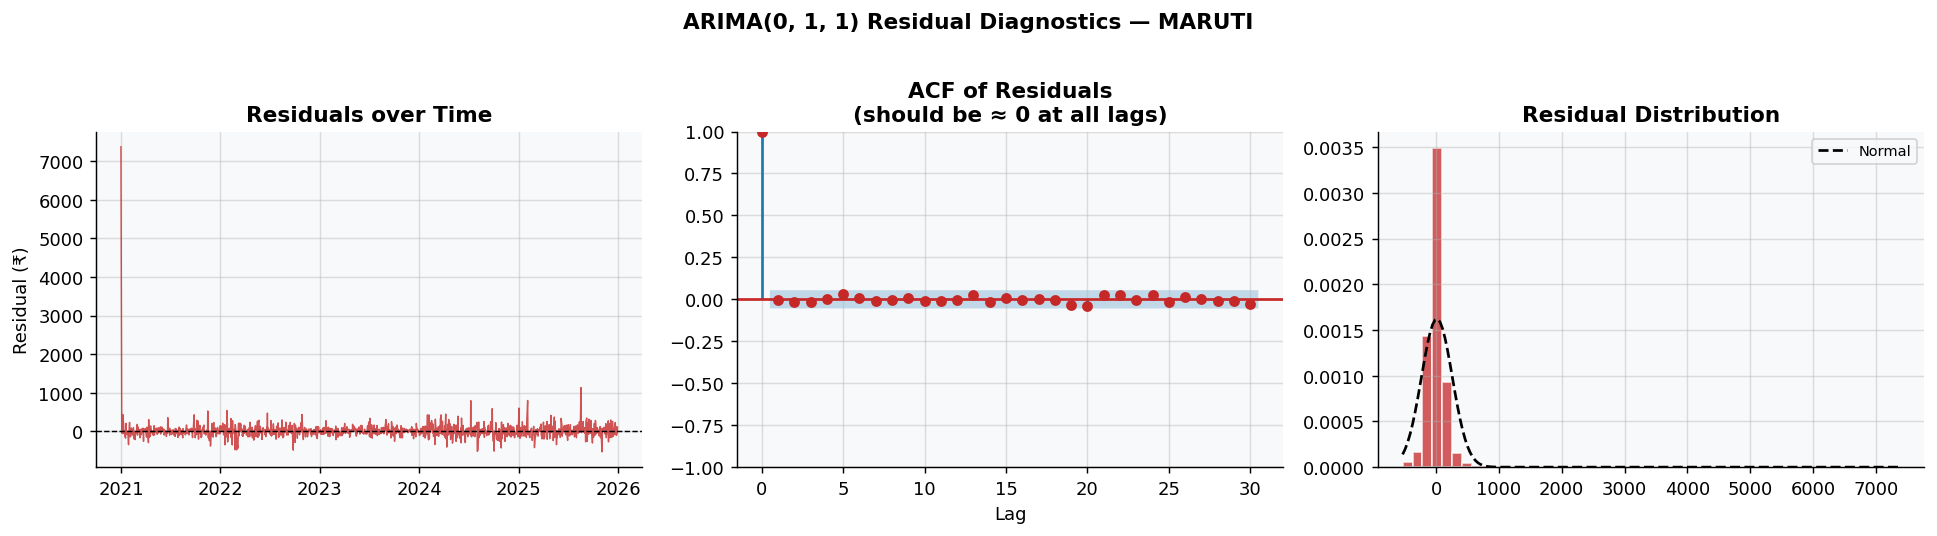

  MARUTI: Ljung-Box test (lags 10,20) → No autocorrelation in residuals  (p=[0.9937 0.9943])


In [36]:
# ── Residual diagnostics for all ARIMA models ───────────────────────────────

for name in price_data:
    mdl = arima_results[name]['final_model']
    res = mdl.resid.dropna()

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Residuals over time
    axes[0].plot(res, color=STOCK_COLORS[name], linewidth=0.8, alpha=0.8)
    axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
    axes[0].set_title('Residuals over Time', fontweight='bold')
    axes[0].set_ylabel('Residual (₹)')

    # ACF of residuals
    plot_acf(res, lags=30, ax=axes[1], alpha=0.05, color=STOCK_COLORS[name], title='')
    axes[1].set_title('ACF of Residuals\n(should be ≈ 0 at all lags)',
                      fontweight='bold')
    axes[1].set_xlabel('Lag')

    # Histogram
    axes[2].hist(res, bins=50, color=STOCK_COLORS[name], alpha=0.75,
                 edgecolor='white', density=True)
    from scipy.stats import norm as spnorm
    x = np.linspace(res.min(), res.max(), 200)
    axes[2].plot(x, spnorm.pdf(x, res.mean(), res.std()),
                 color='black', linewidth=1.5, linestyle='--', label='Normal')
    axes[2].set_title('Residual Distribution', fontweight='bold')
    axes[2].legend(fontsize=8)

    order = arima_results[name]['order']
    plt.suptitle(f'ARIMA{order} Residual Diagnostics — {name}',
                 fontsize=12, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(f'13_residuals_{name.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Ljung-Box test for residual autocorrelation
    from statsmodels.stats.diagnostic import acorr_ljungbox
    lb = acorr_ljungbox(res, lags=[10, 20], return_df=True)
    lb_pass = all(lb['lb_pvalue'] > 0.05)
    print(f"  {name}: Ljung-Box test (lags 10,20) → "
          f"{'No autocorrelation in residuals' if lb_pass else ' Autocorrelation detected — consider higher order'}"
          f"  (p={lb['lb_pvalue'].values.round(4)})")

---
## Summary Dashboard

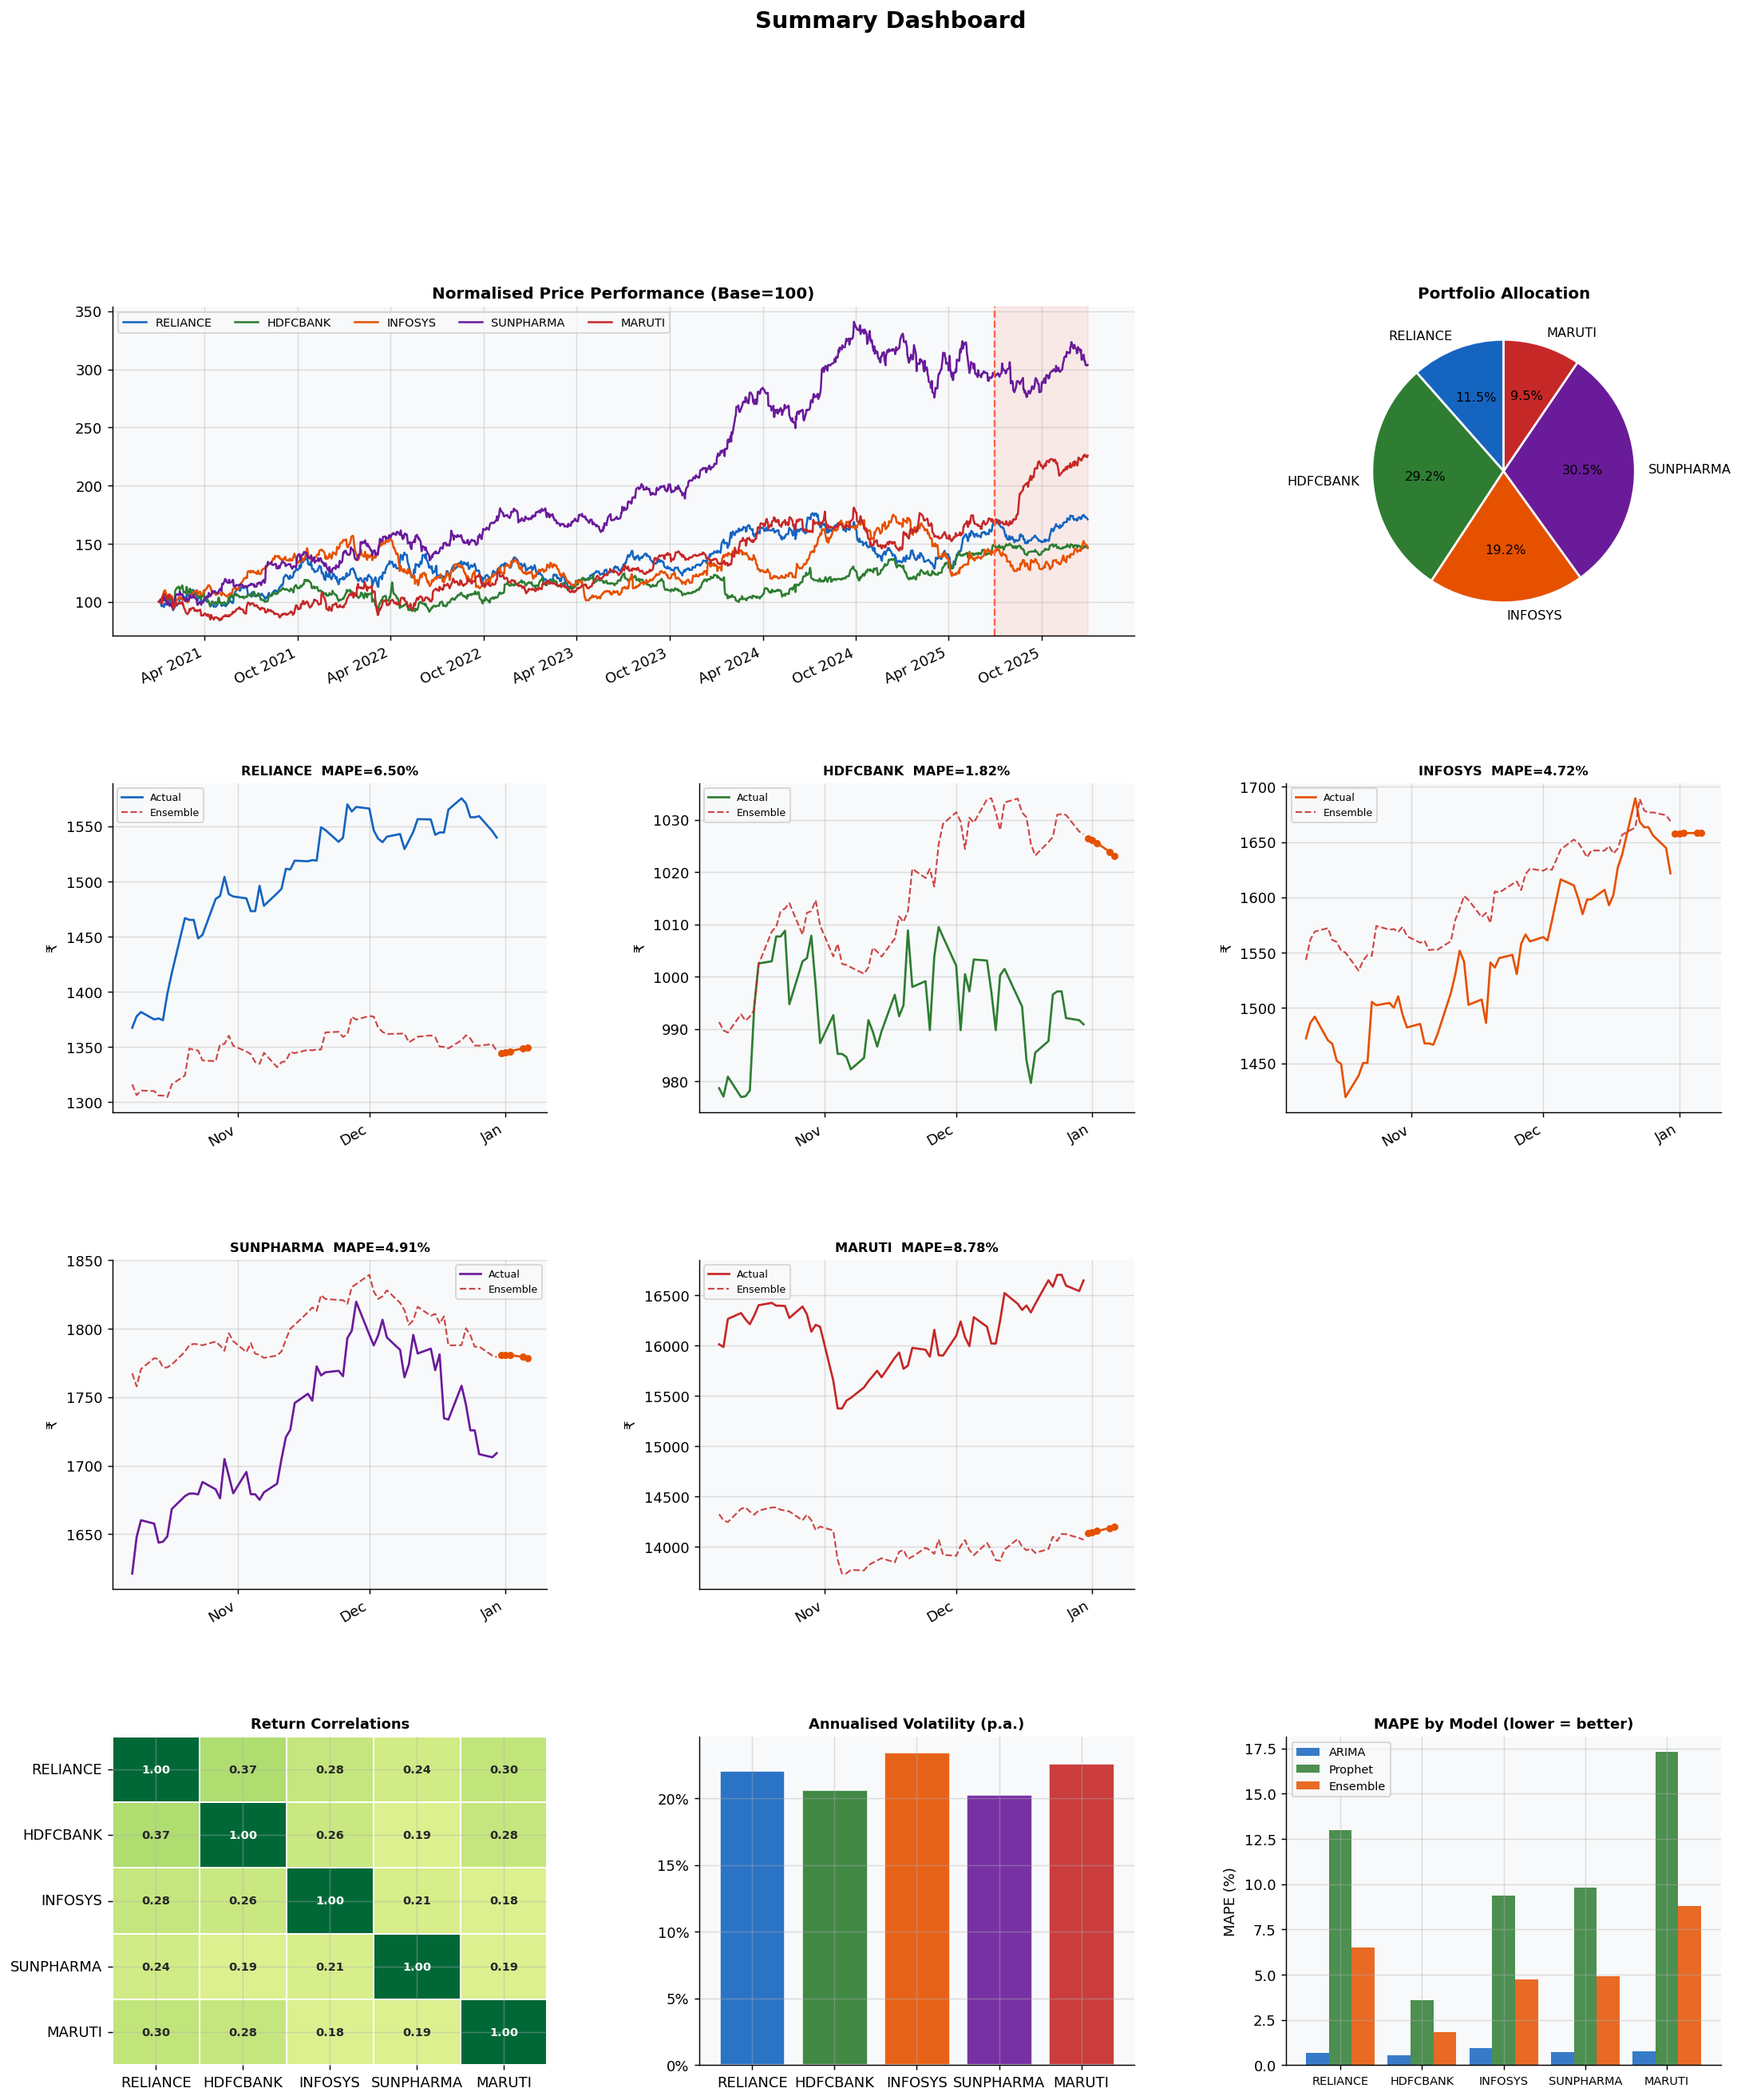

In [38]:
# ── Summary dashboard ───────────────────────────────────────────────────────

fig = plt.figure(figsize=(20, 22))
gs  = gridspec.GridSpec(4, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── [0,0:2] Normalised price performance ─────────────────────────────────────
ax0 = fig.add_subplot(gs[0, :2])
norm = prices_df.div(prices_df.iloc[0]) * 100
for col in norm.columns:
    ax0.plot(norm.index, norm[col], label=col,
             color=STOCK_COLORS[col], linewidth=1.4)
ax0.axvspan(pd.Timestamp(TEST_START), norm.index[-1], alpha=0.10, color='tomato')
ax0.axvline(pd.Timestamp(TEST_START), color='tomato', linestyle='--', linewidth=1.3)
ax0.set_title('Normalised Price Performance (Base=100)', fontweight='bold', fontsize=11)
ax0.legend(fontsize=8, ncol=5)
ax0.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax0.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(ax0.xaxis.get_majorticklabels(), rotation=25, ha='right')

# ── [0,2] Portfolio allocation pie ───────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 2])
weight_vals = [float(r['Weight (%)'].strip('%')) / 100 for _, r in allocation_df.iterrows()]
colors_pie  = [STOCK_COLORS[r['Stock']] for _, r in allocation_df.iterrows()]
ax1.pie(weight_vals, labels=allocation_df['Stock'], autopct='%1.1f%%',
        colors=colors_pie, startangle=90,
        wedgeprops=dict(edgecolor='white', linewidth=1.5),
        textprops={'fontsize': 9})
ax1.set_title('Portfolio Allocation', fontweight='bold', fontsize=11)

# ── [1,:] Ensemble forecast for each stock (small multiples) ─────────────────
for i, name in enumerate(price_data):
    col = i % 3
    row = 1 + i // 3
    if row > 3:
        break
    ax = fig.add_subplot(gs[row, col])
    t  = test_data[name].iloc[-60:]
    p  = ensemble_results[name]['predictions'].reindex(t.index)
    ax.plot(t.index,  t, color=STOCK_COLORS[name], linewidth=1.5, label='Actual')
    ax.plot(p.index,  p, color='#C62828', linewidth=1.2,
            linestyle='--', alpha=0.85, label='Ensemble')
    fc = ensemble_results[name]['forecast']
    ax.plot(fc.index, fc, color='#E65100', linewidth=1.5, marker='o', markersize=4)
    m  = ensemble_results[name]['metrics']
    ax.set_title(f"{name}  MAPE={m['MAPE']:.2f}%", fontsize=9, fontweight='bold')
    ax.set_ylabel('₹')
    ax.legend(fontsize=7)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

# ── [3,0] Correlation heatmap ─────────────────────────────────────────────────
ax_corr = fig.add_subplot(gs[3, 0])
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            ax=ax_corr, linewidths=1, cbar=False,
            annot_kws={'size': 8, 'weight': 'bold'})
ax_corr.set_title('Return Correlations', fontweight='bold', fontsize=10)

# ── [3,1] Volatility bar chart ────────────────────────────────────────────────
ax_vol = fig.add_subplot(gs[3, 1])
vol_vals = [vol_data[name]['ann_vol'] for name in price_data]
ax_vol.bar(list(price_data.keys()), vol_vals,
           color=[STOCK_COLORS[n] for n in price_data],
           edgecolor='white', linewidth=1.5, alpha=0.9)
ax_vol.set_title('Annualised Volatility (p.a.)', fontweight='bold', fontsize=10)
ax_vol.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

# ── [3,2] Model MAPE bar chart ───────────────────────────────────────────────
ax_mape = fig.add_subplot(gs[3, 2])
mape_arima   = [arima_results[n]['metrics']['MAPE']    for n in price_data]
mape_prophet = [prophet_results[n]['metrics']['MAPE']  for n in price_data]
mape_ens     = [ensemble_results[n]['metrics']['MAPE'] for n in price_data]
x = np.arange(len(price_data))
w = 0.28
ax_mape.bar(x - w, mape_arima,   w, label='ARIMA',   color='#1565C0', alpha=0.85)
ax_mape.bar(x,     mape_prophet, w, label='Prophet', color='#2E7D32', alpha=0.85)
ax_mape.bar(x + w, mape_ens,     w, label='Ensemble',color='#E65100', alpha=0.85)
ax_mape.set_xticks(x)
ax_mape.set_xticklabels(list(price_data.keys()), fontsize=8)
ax_mape.set_title('MAPE by Model (lower = better)', fontweight='bold', fontsize=10)
ax_mape.set_ylabel('MAPE (%)')
ax_mape.legend(fontsize=8)

fig.suptitle('Summary Dashboard',
             fontsize=16, fontweight='bold', y=1.01)
plt.savefig('14_summary_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

In [41]:
# ── Final summary ───────────────────────────────────────────────────

print("\n Stocks analysed:")
for name in price_data:
    m_a = arima_results[name]['metrics']
    m_p = prophet_results[name]['metrics']
    m_e = ensemble_results[name]['metrics']
    print(f"  {name:<12} │  ARIMA MAPE={m_a['MAPE']:.2f}%  "
          f"│  Prophet MAPE={m_p['MAPE']:.2f}%  "
          f"│  Ensemble MAPE={m_e['MAPE']:.2f}%")

print("\n Portfolio allocation:")
for _, row in allocation_df.iterrows():
    print(f"  {row['Stock']:<12} │  {row['Weight (%)']:>6}  │  "
          f"{row['Allocated (₹)']:>12}  │  {row['Shares']:>5} shares")

print(f"\n Total capital: ₹{TOTAL_CAPITAL:,}")


 Stocks analysed:
  RELIANCE     │  ARIMA MAPE=0.69%  │  Prophet MAPE=12.97%  │  Ensemble MAPE=6.50%
  HDFCBANK     │  ARIMA MAPE=0.53%  │  Prophet MAPE=3.59%  │  Ensemble MAPE=1.82%
  INFOSYS      │  ARIMA MAPE=0.96%  │  Prophet MAPE=9.37%  │  Ensemble MAPE=4.72%
  SUNPHARMA    │  ARIMA MAPE=0.73%  │  Prophet MAPE=9.79%  │  Ensemble MAPE=4.91%
  MARUTI       │  ARIMA MAPE=0.78%  │  Prophet MAPE=17.30%  │  Ensemble MAPE=8.78%

 Portfolio allocation:
  RELIANCE     │   11.5%  │      ₹115,051  │     74 shares
  HDFCBANK     │   29.2%  │      ₹291,942  │    294 shares
  INFOSYS      │   19.2%  │      ₹192,424  │    118 shares
  SUNPHARMA    │   30.5%  │      ₹305,378  │    178 shares
  MARUTI       │    9.5%  │       ₹95,206  │      5 shares

 Total capital: ₹1,000,000
